In [1]:
%load_ext autoreload

%autoreload 2

In [99]:
import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import seaborn as sns   
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import os
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from lifelines import CoxPHFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
from lifelines import KaplanMeierFitter
from lifelines.statistics import pairwise_logrank_test
from lifelines.plotting import add_at_risk_counts
import warnings
from preproces_prod4_2025_update import *
from scipy.stats import norm
import gspread
from oauth2client.service_account import ServiceAccountCredentials
from matching_case_control import match_nn_max_dist_weigths
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")


pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'

#### Efectividad de los niños 2024 en el 2025:

In [3]:
df_pf_2025 = pre_filtred(df_name='COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv',lrti_name='LRTI_Flag')#NAC_RNI_EGRESOS_ENTREGA_ISCI_20_12_2024_encr

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025


In [55]:
((pd.to_datetime('2025-09-30').month - df_pf_2025.query('fechaInm.dt.year==2025').query('fechaInm.dt.month>=3').fechaInm.min().month))

6

In [46]:
df_pf_2025.query('fechaInm.dt.year==2025').query('fechaInm.dt.month<=2')[['RUN','fecha_nac','fechaInm','eleg_group']]

,RUN,fecha_nac,fechaInm,eleg_group
171820,efd84077a75cf4a275e7460c09dd27e77cd1a4876764034ef674fe846dceb871,2024-09-19,2025-01-06,seasonal_2024
171821,efd84077a75cf4a275e7460c09dd27e77cd1a4876764034ef674fe846dceb871,2024-09-19,2025-01-06,seasonal_2024
181080,fe217dfb6e137e7b8db5e579a971c121299246192ecf9742e483446653342776,2024-10-08,2025-01-03,exceso_seasonal_2024_and_catchup_2025
181081,fe217dfb6e137e7b8db5e579a971c121299246192ecf9742e483446653342776,2024-10-08,2025-01-03,exceso_seasonal_2024_and_catchup_2025
195101,6efd9a53e89d6210e9be0b66f9ee4083c079c99b7f15c531e3ad9dea5735e4c7,2024-11-04,2025-01-20,exceso_seasonal_2024_and_catchup_2025
195102,6efd9a53e89d6210e9be0b66f9ee4083c079c99b7f15c531e3ad9dea5735e4c7,2024-11-04,2025-01-20,exceso_seasonal_2024_and_catchup_2025
195103,6efd9a53e89d6210e9be0b66f9ee4083c079c99b7f15c531e3ad9dea5735e4c7,2024-11-04,2025-01-20,exceso_seasonal_2024_and_catchup_2025
200579,9701754ca4e1c4af49c8c65899c13754d472aadebfe6014201ee7b084ee34f48,2024-11-21,2025-01-03,exceso_seasonal_2024_and_catchup_2025
201834,494efc84d95fd9a91ccb3dd375251017a2713f6636d2450f6341056038e90257,2024-11-27,2025-01-01,exceso_seasonal_2024_and_catchup_2025
201835,494efc84d95fd9a91ccb3dd375251017a2713f6636d2450f6341056038e90257,2024-11-27,2025-01-01,exceso_seasonal_2024_and_catchup_2025


In [40]:
df_f_vrs_mrz_ag = pd.read_csv(path_data/'df_f_vrs_mrz_ag.csv')

In [83]:
lisa_ruts_anali = (df_pf_2025
 .assign(vrs_before = lambda x: (x.fechaIng_vrs<pd.to_datetime('2024-07-01')).astype(int),
         vrs_after = lambda x: (x.fechaIng_vrs>=pd.to_datetime('2025-03-01')).astype(int),
         vrs_pre_season = lambda x: ((x.fechaIng_vrs < pd.to_datetime('2025-03-01')) & (x.fechaIng_vrs >= pd.to_datetime('2024-07-01'))).astype(int))
 
 [['RUN','vrs_before','vrs_after','vrs_pre_season']]
 .groupby('RUN')
 .agg({'vrs_before':'max','vrs_after':'max','vrs_pre_season':'max'})
 .reset_index()
 .query('vrs_before==1')
 .query('vrs_pre_season==0')
 .query('vrs_after==1')
 .RUN
)

COX NORMAL

In [82]:
df_cox_vrs_duracion, _, df_f_vrs_duracion, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                        40,
                                                        group_age=False,
                                                        weeks_inm=False,
                                                        fin_inmune=False,
                                                        cohort='2024',
                                                        T_inicial = pd.to_datetime('2025-04-01'),
                                                        fecha_dt = pd.to_datetime('2025-09-30'),
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=True,
                                                        meses_inm_bool=False)


n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  2536
ruts perdidos por filtro semanas y peso:  1130
Droped intersex: 28
Datos perdidos por edad madre atípica: 483
Datos perdidos por fecha ingreso menor a fecha nacimiento: 31
vrs en los primeros 7 dias 

In [88]:
df_cox_vrs_duracion = pd.read_csv(path_data/'df_cox_vrs_duracion.csv')
df_f_vrs_duracion = pd.read_csv(path_data/'df_f_vrs_duracion.csv')

In [90]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs']
T_inicial = pd.to_datetime('2025-04-01')
df_cox = df_cox_vrs_duracion.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','sexo']
ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,0.166594,-0.181274,0.126544,-0.081428,0.414615,-0.513787,0.078201,0.18801


In [88]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs']
T_inicial = pd.to_datetime('2025-04-01')
df_cox = df_cox_vrs_duracion.merge(df_f_vrs_duracion.assign(vrs_before = lambda x: (x.fechaIng_vrs_copy<T_inicial).astype(int))[['RUN','vrs_before']],how='left',on='RUN')
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','sexo']
ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,0.154535,-0.167115,0.124795,-0.09006,0.399129,-0.490526,0.086123,0.215603


In [51]:
df_f_vrs_duracion[(df_f_vrs_duracion.fechaInm.dt.year == 2024)].to_csv(path_data/'df_f_vrs_duracion.csv',index=False)
df_cox_vrs_duracion.to_csv(path_data/'df_cox_vrs_duracion.csv',index=False)

In [589]:
df_f_vrs_duracion = pd.read_csv(path_data/'df_f_vrs_duracion.csv')
df_cox_vrs_duracion = pd.read_csv(path_data/'df_cox_vrs_duracion.csv')

In [55]:
################################################################ darle más peso a los no inmunes
# r = imu / no inmu

r = 1/1

df = df_cox_vrs_duracion.copy()

ID_COL    = "RUN"
IMM_COL   = "inmunizado"   # time-varying 0/1 por fila (como lo tienes)
EVENT_COL = "event_vrs"
START_COL = "start"
STOP_COL  = "stop"

ever_imm = df.groupby(ID_COL)[IMM_COL].max()
no_ids = ever_imm[ever_imm == 0].index

n_imm = (ever_imm == 1).sum()
n_no  = (ever_imm == 0).sum()

print("Full cohort (ever_imm): inmunes =", n_imm, "| no_inmunes =", n_no, "| ratio actual =", n_imm / n_no)
w0 = n_imm / (r * n_no)

df["w_ratio"] = 1.0
df.loc[df[ID_COL].isin(no_ids), "w_ratio"] = w0

print("Peso aplicado a no-inmunes (w0):", w0)

ctv = CoxTimeVaryingFitter()

covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac','w_ratio']
df_cox = df.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','semana_nac']  
ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata, weights_col="w_ratio")
display(printSummary(ctv_0))

Full cohort (ever_imm): inmunes = 144461 | no_inmunes = 8567 | ratio actual = 16.862495622738415
Peso aplicado a no-inmunes (w0): 16.862495622738415


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,0.266076,-0.304835,0.044122,0.179598,0.352555,-0.422698,-0.196736,0.000000
sexo,0.167215,-0.182008,0.037676,0.093371,0.241058,-0.272595,-0.097870,0.000009


In [92]:
################################################################ darle más peso a los no inmunes dando vuelta variable inmune
# r = imu / no inmu

r = 5/1

df = df_cox_vrs_duracion.assign(inmunizado = lambda x: (x.inmunizado==0).astype(int)).copy()

ID_COL    = "RUN"
IMM_COL   = "inmunizado"   # time-varying 0/1 por fila (como lo tienes)
EVENT_COL = "event_vrs"
START_COL = "start"
STOP_COL  = "stop"

ever_imm = df.groupby(ID_COL)[IMM_COL].min()
no_ids = ever_imm[ever_imm == 1].index

n_imm = (ever_imm == 0).sum()
n_no  = (ever_imm == 1).sum()

print("Full cohort (ever_imm): inmunes =", n_imm, "| no_inmunes =", n_no, "| ratio actual =", n_imm / n_no)
w0 = n_imm / (r * n_no)

df["w_ratio"] = 1.0
df.loc[df[ID_COL].isin(no_ids), "w_ratio"] = w0

print("Peso aplicado a no-inmunes (w0):", w0)

ctv = CoxTimeVaryingFitter()

covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','w_ratio']
df_cox = df.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','sexo']  
ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata, weights_col="w_ratio")
display(printSummary(ctv_0))

Full cohort (ever_imm): inmunes = 144216 | no_inmunes = 8156 | ratio actual = 17.682197155468366
Peso aplicado a no-inmunes (w0): 3.5364394310936733


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-0.171394,0.15751,0.072968,-0.314408,-0.02838,0.027981,0.269779,0.018829


no haber sido inmunizado tiene una efectividad del 17% (di vuelta inmunizado)

MATCHING NN

In [590]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name']  # ejemplo

df_tv = df_cox_vrs_duracion.copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=5.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

ctv = CoxTimeVaryingFitter()

ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs", "Group", "inmunizado"]],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

1:1 ['1', '1']
here aaa
Total cases = 8156, Total controls = 144216
Total cases matched is : 8156, Total control matched is : 8156
ratio: 1:1
No matched : 0
Iteration 1: norm_delta = 5.85e-02, step_size = 0.9500, log_lik = -90.10913, newton_decrement = 2.46e-01, seconds_since_start = 5.7
Iteration 2: norm_delta = 3.00e-03, step_size = 0.9500, log_lik = -89.86347, newton_decrement = 6.44e-04, seconds_since_start = 11.6
Iteration 3: norm_delta = 1.50e-04, step_size = 0.9500, log_lik = -89.86283, newton_decrement = 1.62e-06, seconds_since_start = 17.2
Iteration 4: norm_delta = 7.92e-06, step_size = 1.0000, log_lik = -89.86282, newton_decrement = 4.06e-09, seconds_since_start = 23.5
Convergence completed after 4 iterations.


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-0.123233,0.115942,0.175745,-0.467686,0.22122,-0.247598,0.37355,0.483176


In [93]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name']  # ejemplo

df_tv = df_cox_vrs_duracion.copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:5",
    max_distance=5.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

ctv = CoxTimeVaryingFitter()

ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs", "Group", "inmunizado"]],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

1:5 ['1', '5']
here aaa
Total cases = 8156, Total controls = 144216
Total cases matched is : 4610, Total control matched is : 23050
ratio: 1:5
No matched : 3546
Iteration 1: norm_delta = 2.84e-02, step_size = 0.9500, log_lik = -473.90465, newton_decrement = 1.18e-01, seconds_since_start = 2.9
Iteration 2: norm_delta = 2.21e-03, step_size = 0.9500, log_lik = -473.78559, newton_decrement = 6.77e-04, seconds_since_start = 5.7
Iteration 3: norm_delta = 1.15e-04, step_size = 0.9500, log_lik = -473.78491, newton_decrement = 1.83e-06, seconds_since_start = 8.6
Iteration 4: norm_delta = 6.08e-06, step_size = 1.0000, log_lik = -473.78491, newton_decrement = 4.60e-09, seconds_since_start = 11.5
Convergence completed after 4 iterations.


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,0.08241,-0.085901,0.169991,-0.250766,0.415586,-0.515258,0.221796,0.627826


como inmunizado ya no es time-varying puedo correr cox normal.

In [ ]:
df = df_f_vrs_duracion[(df_f_vrs_duracion.fechaInm.dt.year == 2024) | (df_f_vrs_duracion.fechaInm.isna()) ].copy()

t0   = pd.Timestamp("2025-04-01")
tend = pd.Timestamp("2025-09-30")

ID_COL       = "RUN"
INM_DATE_COL = "fechaInm"
EVENT_DATE_COL = "fechaIng_vrs"   
covs = ["SEMANAS","mes_nac_name","region",'sexo']

df["imm_baseline"] = df[INM_DATE_COL].notna().astype(int)

df[EVENT_DATE_COL] = pd.to_datetime(df[EVENT_DATE_COL], errors="coerce")

df["event"] = (
    df[EVENT_DATE_COL].notna()
    & (df[EVENT_DATE_COL] >= t0)
    & (df[EVENT_DATE_COL] <= tend)
).astype(int)

df["stop_date"] = np.where(df["event"].eq(1), df[EVENT_DATE_COL], tend)
df["stop_date"] = pd.to_datetime(df["stop_date"])

df["T"] = (df["stop_date"] - t0).dt.days.clip(lower=0)

df = df[df["T"] > 0].copy()

X = df[["T","event","imm_baseline"] + covs].copy()

cph = CoxPHFitter()
cph.fit(X, duration_col="T", event_col="event",strata = ["SEMANAS","mes_nac_name","region",'sexo'], show_progress=True,)
cph.print_summary()

hr = float(cph.summary.loc["imm_baseline", "exp(coef)"])
hr_lo = float(cph.summary.loc["imm_baseline", "exp(coef) lower 95%"])
hr_hi = float(cph.summary.loc["imm_baseline", "exp(coef) upper 95%"])

ve = 1 - hr
ve_lo = 1 - hr_hi   # ojo: invierte porque 1 - HR
ve_hi = 1 - hr_lo

print("\n--- VE (1 - HR) ---")
print(f"HR = {hr:.4f}  (95%: {hr_lo:.4f}–{hr_hi:.4f})")
print(f"VE = {ve:.4f}  (95%: {ve_lo:.4f}–{ve_hi:.4f})")


Iteration 1: norm_delta = 3.54e-02, step_size = 0.9500, log_lik = -10684.10567, newton_decrement = 8.81e-01, seconds_since_start = 135.1
Iteration 2: norm_delta = 4.30e-03, step_size = 0.9500, log_lik = -10683.19494, newton_decrement = 1.15e-02, seconds_since_start = 269.5
Iteration 3: norm_delta = 2.50e-04, step_size = 0.9500, log_lik = -10683.18345, newton_decrement = 3.82e-05, seconds_since_start = 403.2
Iteration 4: norm_delta = 1.19e-07, step_size = 1.0000, log_lik = -10683.18342, newton_decrement = 8.58e-12, seconds_since_start = 536.8
Convergence success after 4 iterations.


<lifelines.CoxPHFitter: fitted with 152123 total observations, 150052 right-censored observations>
             duration col = 'T'
                event col = 'event'
                   strata = ['SEMANAS', 'mes_nac_name', 'region', 'sexo']
      baseline estimation = breslow
   number of observations = 152123
number of events observed = 2071
   partial log-likelihood = -10683.18
         time fit was run = 2026-01-14 22:22:26 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
imm_baseline  0.17      1.18      0.13           -0.08            0.42                0.92                1.52

              cmp to    z    p  -log2(p)
covariate                               
imm_baseline    0.00 1.33 0.18      2.44
---
Concordance = 0.50
Partial AIC = 21368.37
log-likelihood ratio test = 1.84 on 1 df
-log2(p) of ll-ratio test = 2.52


--- VE (1 - HR) ---
HR = 1.1838  (95%: 0.9225–1.5192)
VE = -0.1838  (95%: -0.5192–0.0775)


Muy similar al resultado del cox.

#### Covariables de inmmunización a tramos.

In [56]:
df_cox_vrs_tramos, _, df_f_vrs_tramos, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                        40,
                                                        group_age=False,
                                                        weeks_inm=False,
                                                        fin_inmune=False,
                                                        cohort='2025',
                                                        T_inicial = pd.to_datetime('2025-03-01'),
                                                        fecha_dt = pd.to_datetime('2025-08-30'),
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=True)

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  960
ruts perdidos por filtro semanas y peso:  539
Droped intersex: 5
Datos perdidos por edad madre atípica: 244
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de 

In [155]:
covs = ['start', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs']
columns_inm = [col for col in df_cox_vrs_tramos.columns if col.endswith('_meses')]
df_cox = df_cox_vrs_tramos.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','sexo']
ctv_0.fit(df_cox[covs + columns_inm], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inm_mayor_0_meses,-1.363872,0.744331,0.166767,-1.690729,-1.037015,0.645489,0.815615,0.000000
inm_mayor_1_meses,0.597920,-0.818332,0.144239,0.315216,0.880624,-1.412403,-0.370555,0.000034
inm_mayor_2_meses,-0.355340,0.299065,0.118094,-0.586801,-0.123880,0.116514,0.443896,0.002622
inm_mayor_3_meses,-0.068375,0.066090,0.124139,-0.311683,0.174933,-0.191166,0.267786,0.581774
inm_mayor_4_meses,0.289868,-0.336251,0.132143,0.030873,0.548863,-0.731284,-0.031354,0.028265
inm_mayor_5_meses,0.264305,-0.302525,0.186942,-0.102095,0.630705,-0.878934,0.097056,0.157411


In [77]:
################################################################ darle más peso a los no inmunes
# r = imu / no inmu

r = 2/1

df = df_cox_vrs_tramos.copy()

ID_COL    = "RUN"
IMM_COL   = "inmunizado"   # time-varying 0/1 por fila (como lo tienes)
EVENT_COL = "event_vrs"
START_COL = "start"
STOP_COL  = "stop"

ever_imm = df.groupby(ID_COL)[IMM_COL].max()
no_ids = ever_imm[ever_imm == 0].index

n_imm = (ever_imm == 1).sum()
n_no  = (ever_imm == 0).sum()

print("Full cohort (ever_imm): inmunes =", n_imm, "| no_inmunes =", n_no, "| ratio actual =", n_imm / n_no)
w0 = n_imm / (r * n_no)

df["w_ratio"] = 1.0
df.loc[df[ID_COL].isin(no_ids), "w_ratio"] = w0

print("Peso aplicado a no-inmunes (w0):", w0)

ctv = CoxTimeVaryingFitter()
columns_inm = [col for col in df.columns if col.endswith('_meses')]
covs = ['start', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','w_ratio']
df_cox = df.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','sexo']
ctv_0.fit(df_cox[covs + columns_inm], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata,weights_col='w_ratio')
display(printSummary(ctv_0))

Full cohort (ever_imm): inmunes = 111625 | no_inmunes = 3084 | ratio actual = 36.194876783398186
Peso aplicado a no-inmunes (w0): 18.097438391699093


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inm_mayor_0_meses,-2.099334,0.877462,0.112469,-2.319769,-1.878899,0.847242,0.901704,0.000000
inm_mayor_1_meses,0.819921,-1.270322,0.126550,0.571888,1.067955,-1.909423,-0.771609,0.000000
inm_mayor_2_meses,-0.122163,0.114996,0.103090,-0.324215,0.079889,-0.083166,0.276905,0.236009
inm_mayor_3_meses,0.017948,-0.018110,0.107993,-0.193714,0.229610,-0.258109,0.176107,0.868003
inm_mayor_4_meses,0.387338,-0.473055,0.116311,0.159373,0.615304,-0.850219,-0.172775,0.000868
inm_mayor_5_meses,0.340339,-0.405423,0.172865,0.001529,0.679148,-0.972196,-0.001530,0.048975


In [ ]:
covs = ['start', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs']
columns_inm = ['inm_mayor_0_meses','inm_mayor_2_meses', 'inm_mayor_4_meses']
df_cox = df_cox_vrs_tramos.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','sexo']
ctv_0.fit(df_cox[covs + columns_inm], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inm_mayor_0_meses,-0.959894,0.617067,0.128355,-1.211464,-0.708324,0.507531,0.702239,0.000000
inm_mayor_2_meses,-0.269045,0.235891,0.111819,-0.488206,-0.049885,0.048661,0.386273,0.016124
inm_mayor_4_meses,0.322618,-0.380738,0.125237,0.077159,0.568077,-0.764870,-0.080213,0.009993


Transformo columnas (solo 1 se activa)

In [68]:
df_cox_vrs_tramos_modifed = df_cox_vrs_tramos.copy()

In [71]:
import numpy as np

cols = [f"inm_mayor_{k}_meses" for k in range(6)]  # 0..5

# matriz booleana (trata NaN como 0)
M = df_cox_vrs_tramos_modifed[cols].fillna(0).astype(int).to_numpy().astype(bool)

# buscar la columna activa de mayor k: invierto columnas y tomo el primer True
M_rev = M[:, ::-1]
has_any = M_rev.any(axis=1)
pos_rev = M_rev.argmax(axis=1)          # índice del primer True en el orden invertido (0..5)
k_max = (len(cols) - 1) - pos_rev       # convertir a k real (0..5)
k_max[~has_any] = -1                    # filas sin ningún 1

# construir la nueva matriz one-hot
newM = np.zeros_like(M, dtype=int)
rows = np.arange(M.shape[0])
mask = k_max >= 0
newM[rows[mask], k_max[mask]] = 1

# escribir de vuelta al df (sobrescribe esas columnas)
df_cox_vrs_tramos_modifed.loc[:, cols] = newM

In [73]:
covs = ['start', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs']
columns_inm = [col for col in df_cox_vrs_tramos_modifed.columns if col.endswith('_meses')]
df_cox = df_cox_vrs_tramos_modifed.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','sexo']
ctv_0.fit(df_cox[covs + columns_inm], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inm_mayor_0_meses,-1.363872,0.744331,0.166767,-1.690729,-1.037015,0.645489,0.815615,0.000000e+00
inm_mayor_1_meses,-0.765952,0.535109,0.138378,-1.037168,-0.494736,0.390268,0.645543,0.000000e+00
inm_mayor_2_meses,-1.121292,0.674141,0.139094,-1.393912,-0.848673,0.572017,0.751897,0.000000e+00
inm_mayor_3_meses,-1.189667,0.695677,0.146868,-1.477523,-0.901812,0.594166,0.771798,0.000000e+00
inm_mayor_4_meses,-0.899799,0.593349,0.166238,-1.225620,-0.573978,0.436720,0.706425,1.000000e-07
inm_mayor_5_meses,-0.635494,0.470326,0.228271,-1.082897,-0.188092,0.171461,0.661387,5.370100e-03


In [79]:
################################################################ darle más peso a los no inmunes
# r = imu / no inmu

r = 2/1

df = df_cox_vrs_tramos_modifed.copy()

ID_COL    = "RUN"
IMM_COL   = "inmunizado"   # time-varying 0/1 por fila (como lo tienes)
EVENT_COL = "event_vrs"
START_COL = "start"
STOP_COL  = "stop"

ever_imm = df.groupby(ID_COL)[IMM_COL].max()
no_ids = ever_imm[ever_imm == 0].index

n_imm = (ever_imm == 1).sum()
n_no  = (ever_imm == 0).sum()

print("Full cohort (ever_imm): inmunes =", n_imm, "| no_inmunes =", n_no, "| ratio actual =", n_imm / n_no)
w0 = n_imm / (r * n_no)

df["w_ratio"] = 1.0
df.loc[df[ID_COL].isin(no_ids), "w_ratio"] = w0

print("Peso aplicado a no-inmunes (w0):", w0)

ctv = CoxTimeVaryingFitter()
columns_inm = [col for col in df.columns if col.endswith('_meses')]
covs = ['start', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','w_ratio']
df_cox = df.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','sexo']
ctv_0.fit(df_cox[covs + columns_inm], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata,weights_col='w_ratio')
display(printSummary(ctv_0))

Full cohort (ever_imm): inmunes = 111625 | no_inmunes = 3084 | ratio actual = 36.194876783398186
Peso aplicado a no-inmunes (w0): 18.097438391699093


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inm_mayor_0_meses,-2.099334,0.877462,0.112469,-2.319769,-1.878899,0.847242,0.901704,0.000000
inm_mayor_1_meses,-1.279413,0.721799,0.079649,-1.435521,-1.123304,0.674797,0.762009,0.000000
inm_mayor_2_meses,-1.401576,0.753791,0.080871,-1.560081,-1.243071,0.711503,0.789881,0.000000
inm_mayor_3_meses,-1.383628,0.749332,0.085878,-1.551946,-1.215310,0.703382,0.788165,0.000000
inm_mayor_4_meses,-0.996290,0.630753,0.096935,-1.186278,-0.806301,0.553493,0.694644,0.000000
inm_mayor_5_meses,-0.655951,0.481052,0.164816,-0.978985,-0.332917,0.283170,0.624308,0.000069


In [80]:
################################################################ darle más peso a los no inmunes
# r = imu / no inmu

r = 18/1

df = df_cox_vrs_tramos_modifed.copy()

ID_COL    = "RUN"
IMM_COL   = "inmunizado"   # time-varying 0/1 por fila (como lo tienes)
EVENT_COL = "event_vrs"
START_COL = "start"
STOP_COL  = "stop"

ever_imm = df.groupby(ID_COL)[IMM_COL].max()
no_ids = ever_imm[ever_imm == 0].index

n_imm = (ever_imm == 1).sum()
n_no  = (ever_imm == 0).sum()

print("Full cohort (ever_imm): inmunes =", n_imm, "| no_inmunes =", n_no, "| ratio actual =", n_imm / n_no)
w0 = n_imm / (r * n_no)

df["w_ratio"] = 1.0
df.loc[df[ID_COL].isin(no_ids), "w_ratio"] = w0

print("Peso aplicado a no-inmunes (w0):", w0)

ctv = CoxTimeVaryingFitter()
columns_inm = [col for col in df.columns if col.endswith('_meses')]
covs = ['start', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','w_ratio']
df_cox = df.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','sexo']
ctv_0.fit(df_cox[covs + columns_inm], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata,weights_col='w_ratio')
display(printSummary(ctv_0))

Full cohort (ever_imm): inmunes = 111625 | no_inmunes = 3084 | ratio actual = 36.194876783398186
Peso aplicado a no-inmunes (w0): 2.0108264879665656


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inm_mayor_0_meses,-1.623485,0.802790,0.147228,-1.912047,-1.334923,0.736822,0.852222,0.00000
inm_mayor_1_meses,-0.980478,0.624868,0.115215,-1.206295,-0.754661,0.529830,0.700696,0.00000
inm_mayor_2_meses,-1.299441,0.727316,0.114527,-1.523911,-1.074972,0.658693,0.782142,0.00000
inm_mayor_3_meses,-1.338798,0.737839,0.121210,-1.576365,-1.101231,0.667538,0.793275,0.00000
inm_mayor_4_meses,-1.019073,0.639071,0.139953,-1.293375,-0.744771,0.525157,0.725657,0.00000
inm_mayor_5_meses,-0.743317,0.524466,0.206572,-1.148190,-0.338443,0.287121,0.682790,0.00032


In [156]:
df_cox_vrs_tramos_2, _, df_f_vrs_tramos_2, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                        40,
                                                        group_age=False,
                                                        weeks_inm=False,
                                                        fin_inmune=False,
                                                        cohort='2025',
                                                        T_inicial = pd.to_datetime('2025-03-01'),
                                                        fecha_dt = pd.to_datetime('2025-08-30'),
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=False,
                                                        meses_inm=[0,1,2,3,4,5,6,7,8,9,10])

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  960
ruts perdidos por filtro semanas y peso:  539
Droped intersex: 5
Datos perdidos por edad madre atípica: 244
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de 

In [157]:
covs = ['start', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs']
columns_inm = [col for col in df_cox_vrs_tramos_2.columns if col.endswith('_meses')]
df_cox = df_cox_vrs_tramos_2.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','sexo']
ctv_0.fit(df_cox[covs + columns_inm], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inm_mayor_0_meses,-1.350546,0.740901,0.166533,-1.676946,-1.024147,0.640897,0.813056,0.000000
inm_mayor_1_meses,0.608152,-0.837034,0.144094,0.325734,0.890571,-1.436520,-0.385046,0.000024
inm_mayor_2_meses,-0.342129,0.289743,0.117889,-0.573187,-0.111071,0.105125,0.436274,0.003706
inm_mayor_3_meses,-0.072648,0.070071,0.123448,-0.314600,0.169305,-0.184481,0.269919,0.556204
inm_mayor_4_meses,0.268819,-0.308418,0.131041,0.011984,0.525653,-0.691564,-0.012056,0.040226
inm_mayor_5_meses,0.332800,-0.394868,0.180852,-0.021665,0.687264,-0.988268,0.021432,0.065743
inm_mayor_6_meses,0.634897,-0.886827,0.723320,-0.782785,2.052579,-6.787957,0.542869,0.380078
inm_mayor_7_meses,-0.608165,0.455651,0.634799,-1.852349,0.636019,-0.888945,0.843132,0.338041
inm_mayor_8_meses,-0.560736,0.429211,0.478720,-1.499009,0.377538,-0.458688,0.776649,0.241469


In [99]:
df_cox_vrs_tramos_2year, _, df_f_vrs_tramos_2year, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                        40,
                                                        group_age=False,
                                                        weeks_inm=False,
                                                        fin_inmune=False,
                                                        cohort='2024',
                                                        T_inicial = pd.to_datetime('2025-03-01'),
                                                        fecha_dt = pd.to_datetime('2025-08-30'),
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=False,
                                                        meses_inm=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
                                                        meses_inm_bool=True)

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  2481
ruts perdidos por filtro semanas y peso:  1072
Droped intersex: 27
Datos perdidos por edad madre atípica: 457
Datos perdidos por fecha ingreso menor a fecha nacimiento: 31
vrs en los primeros 7 dias 

In [100]:
import numpy as np

df_cox_vrs_tramos_2year_mod = df_cox_vrs_tramos_2year.copy()

cols = [f"inm_mayor_{k}_meses" for k in range(17)]  # 0..5

# matriz booleana (trata NaN como 0)
M = df_cox_vrs_tramos_2year_mod[cols].fillna(0).astype(int).to_numpy().astype(bool)

# buscar la columna activa de mayor k: invierto columnas y tomo el primer True
M_rev = M[:, ::-1]
has_any = M_rev.any(axis=1)
pos_rev = M_rev.argmax(axis=1)          # índice del primer True en el orden invertido (0..5)
k_max = (len(cols) - 1) - pos_rev       # convertir a k real (0..5)
k_max[~has_any] = -1                    # filas sin ningún 1

# construir la nueva matriz one-hot
newM = np.zeros_like(M, dtype=int)
rows = np.arange(M.shape[0])
mask = k_max >= 0
newM[rows[mask], k_max[mask]] = 1

# escribir de vuelta al df (sobrescribe esas columnas)
df_cox_vrs_tramos_2year_mod.loc[:, cols] = newM

In [104]:
df_cox_vrs_tramos_2year.to_csv(path_data/'df_cox_vrs_tramos_2year.csv')
df_cox_vrs_tramos_2year_mod.to_csv(path_data/'df_cox_vrs_tramos_2year_mod.csv')

In [3]:
df_cox_vrs_tramos_2year_mod = pd.read_csv(path_data/'df_cox_vrs_tramos_2year_mod.csv')

In [11]:
df_cox_vrs_tramos_2year = pd.read_csv(path_data/'df_cox_vrs_tramos_2year.csv')

In [9]:
df_cox_vrs_tramos_2year_mod = df_cox_vrs_tramos_2year_mod.merge(df_f_vrs_tramos_final.assign(year_nac = lambda x: df_f_vrs_tramos_final.fecha_nac.dt.year)[['RUN','year_nac']],how='left',on='RUN').copy()

0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
          ... 
1663262    1.0
1663263    0.0
1663264    1.0
1663265    1.0
1663266    1.0
Length: 1663267, dtype: float64

In [22]:
df_cox_vrs_tramos_2year_mod_2 = df_cox_vrs_tramos_2year_mod.copy()
for k in range(0,17,3):
    if k+2 == 17:
        break
    col_0 = f"inm_mayor_{k}_meses" 
    col_1 = f"inm_mayor_{k+1}_meses" 
    col_2 = f"inm_mayor_{k+2}_meses" 
    new_col = f"inm_mayor_meses_agg{k+3}" 
    df_cox_vrs_tramos_2year_mod_2[new_col] = df_cox_vrs_tramos_2year_mod_2[[col_0,col_1,col_2]].sum(axis=1)


In [26]:
df_cox_vrs_tramos_2year_mod_2.columns

Index(['Unnamed: 0', 'RUN', 'stop', 'event_vrs', 'start', 'inmunizado',
       'inm_mayor_0_meses', 'inm_mayor_1_meses', 'inm_mayor_2_meses',
       'inm_mayor_3_meses', 'inm_mayor_4_meses', 'inm_mayor_5_meses',
       'inm_mayor_6_meses', 'inm_mayor_7_meses', 'inm_mayor_8_meses',
       'inm_mayor_9_meses', 'inm_mayor_10_meses', 'inm_mayor_11_meses',
       'inm_mayor_12_meses', 'inm_mayor_13_meses', 'inm_mayor_14_meses',
       'inm_mayor_15_meses', 'inm_mayor_16_meses', 'group', 'eleg_2025',
       'eleg_2024', 'eleg_group', 'sexo', 'prematuro_extremo', 'muy_prematuro',
       'prematuro_moderado', 'prematuro', 'region', 'Macrozona2', 'EDAD_M',
       'INS_C_M', 'REG_RES', 'DIAG1', 'MARCA', 'PREVI', 'DIAG2', 'DIAG3',
       'DIAG4', 'DIAG5', 'DIAG6', 'DIAG7', 'DIAG8', 'DIAG9', 'DIAG10',
       'DIAG11', 'URBA_RURAL', 'COMUNA', 'COMUNA_N', 'atypic_mom_age',
       'INS_N_M', 'SEMANAS', 'semana_nac', 'mes_nac_name', 'cama', 'is_rural',
       'categori_macro', 'categori_regions', 'exp

In [ ]:
covs = ['start', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','year_nac']
columns_inm = [col for col in df_cox_vrs_tramos_2year_mod.columns if col.endswith('_meses')]
df_cox = df_cox_vrs_tramos_2year_mod.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','sexo','year_nac']
ctv_0.fit(df_cox[covs + columns_inm], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inm_mayor_0_meses,-1.360870,0.743563,0.165482,-1.685209,-1.036532,0.645317,0.814594,0.000000
inm_mayor_1_meses,-0.750966,0.528089,0.136650,-1.018795,-0.483137,0.383154,0.638970,0.000000
inm_mayor_2_meses,-1.094817,0.665399,0.136494,-1.362341,-0.827293,0.562769,0.743939,0.000000
inm_mayor_3_meses,-1.168232,0.689084,0.143425,-1.449340,-0.887124,0.588161,0.765275,0.000000
inm_mayor_4_meses,-0.898752,0.592923,0.160976,-1.214260,-0.583245,0.441915,0.703070,0.000000
inm_mayor_5_meses,-0.542677,0.418810,0.215988,-0.966005,-0.119348,0.112502,0.619399,0.011987
inm_mayor_6_meses,-0.076351,0.073509,0.557149,-1.168342,1.015641,-1.761133,0.689118,0.891001
inm_mayor_7_meses,-0.243595,0.216195,0.411827,-1.050761,0.563571,-0.756935,0.650328,0.554186
inm_mayor_8_meses,-0.525973,0.409020,0.307248,-1.128168,0.076223,-0.079203,0.676375,0.086918


In [ ]:
################################################################ darle más peso a los no inmunes
# r = imu / no inmu

r = 2/1

df = df_cox_vrs_tramos_2year_mod.copy()

ID_COL    = "RUN"
IMM_COL   = "inmunizado"   # time-varying 0/1 por fila (como lo tienes)
EVENT_COL = "event_vrs"
START_COL = "start"
STOP_COL  = "stop"

ever_imm = df.groupby(ID_COL)[IMM_COL].max()
no_ids = ever_imm[ever_imm == 0].index

n_imm = (ever_imm == 1).sum()
n_no  = (ever_imm == 0).sum()

print("Full cohort (ever_imm): inmunes =", n_imm, "| no_inmunes =", n_no, "| ratio actual =", n_imm / n_no)
w0 = n_imm / (r * n_no)

df["w_ratio"] = 1.0
df.loc[df[ID_COL].isin(no_ids), "w_ratio"] = w0

print("Peso aplicado a no-inmunes (w0):", w0)

ctv = CoxTimeVaryingFitter()
columns_inm = [col for col in df.columns if col.endswith('_meses')]
covs = ['start', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','w_ratio']
df_cox = df.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','sexo']
ctv_0.fit(df_cox[covs + columns_inm], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata,weights_col='w_ratio')
display(printSummary(ctv_0))

Full cohort (ever_imm): inmunes = 270604 | no_inmunes = 11285 | ratio actual = 23.979087284005317
Peso aplicado a no-inmunes (w0): 11.989543642002658


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inm_mayor_0_meses,-1.310414,0.730292,0.106799,-1.519735,-1.101093,0.667492,0.781230,0.000000e+00
inm_mayor_1_meses,-0.303971,0.262118,0.072470,-0.446010,-0.161933,0.149502,0.359822,2.740000e-05
inm_mayor_2_meses,-0.609402,0.456324,0.074679,-0.755770,-0.463035,0.370629,0.530351,0.000000e+00
inm_mayor_3_meses,-0.713785,0.510213,0.078101,-0.866860,-0.560710,0.429196,0.579731,0.000000e+00
inm_mayor_4_meses,-0.461478,0.369649,0.086343,-0.630707,-0.292249,0.253417,0.467785,1.000000e-07
inm_mayor_5_meses,-0.043474,0.042543,0.136064,-0.310155,0.223206,-0.250078,0.266667,7.493369e-01
inm_mayor_6_meses,-0.424021,0.345590,0.354005,-1.117858,0.269816,-0.309724,0.673021,2.310020e-01
inm_mayor_7_meses,-0.220431,0.197827,0.227284,-0.665900,0.225038,-0.252370,0.486189,3.321225e-01
inm_mayor_8_meses,-0.899918,0.593397,0.170826,-1.234731,-0.565105,0.431700,0.709087,1.000000e-07


In [25]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','year_nac']  # 

df_tv = df_cox_vrs_tramos_2year_mod_2.copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

ctv = CoxTimeVaryingFitter()

# columns_inm = [col for col in df_tv_matched.columns if col.endswith('_meses')]
columns_inm = [f"inm_mayor_meses_agg{k}" for k in range(0,17,3)]

ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs", "Group"]+columns_inm],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

1:1 ['1', '1']
here aaa
Total cases = 11285, Total controls = 270604
Total cases matched is : 11285, Total control matched is : 11285
ratio: 1:1
No matched : 0


KeyError: "['inm_mayor_meses_agg0'] not in index"

In [29]:
for k in range(3,17,3):
    print(k)

3
6
9
12
15


In [41]:
df_tv_matched_2 = (df_tv_matched
                   [~(df_tv_matched.RUN.isin(df_tv_matched.query('inm_mayor_13_meses==1').RUN.unique()))]
                   .copy())

df_tv_matched_2['inm_mayor_meses_agg_0_2'] = df_tv_matched_2[["inm_mayor_0_meses" ,'inm_mayor_1_meses','inm_mayor_2_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_3_5'] = df_tv_matched_2[["inm_mayor_3_meses" ,'inm_mayor_4_meses','inm_mayor_5_meses']].sum(axis=1)
# df_tv_matched_2['inm_mayor_meses_agg_6'] = df_tv_matched_2[["inm_mayor_6_meses"]].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_mas_de_6'] = df_tv_matched_2[[f'inm_mayor_{k}_meses' for k in range(6,17)]].sum(axis=1)

columns_inm = ['inm_mayor_meses_agg_0_2','inm_mayor_meses_agg_3_5','inm_mayor_meses_agg_mas_de_6'] #inm_mayor_meses_agg_6

ctv.fit(
    df_tv_matched_2[["RUN", "start", "stop", "event_vrs", "Group"]+columns_inm],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

Iteration 1: norm_delta = 7.61e-01, step_size = 0.9500, log_lik = -126.15279, newton_decrement = 3.06e+01, seconds_since_start = 7.2
Iteration 2: norm_delta = 1.98e-01, step_size = 0.9500, log_lik = -93.72414, newton_decrement = 1.45e+00, seconds_since_start = 14.1
Iteration 3: norm_delta = 4.32e-02, step_size = 0.9500, log_lik = -92.17494, newton_decrement = 5.28e-02, seconds_since_start = 21.4
Iteration 4: norm_delta = 4.07e-03, step_size = 1.0000, log_lik = -92.12112, newton_decrement = 3.94e-04, seconds_since_start = 28.4
Iteration 5: norm_delta = 1.44e-05, step_size = 1.0000, log_lik = -92.12072, newton_decrement = 4.90e-09, seconds_since_start = 35.6
Convergence completed after 5 iterations.


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inm_mayor_meses_agg_0_2,-1.974081,0.861111,0.337470,-2.635510,-1.312652,0.730895,0.928318,0.000000
inm_mayor_meses_agg_3_5,-1.268511,0.718750,0.377308,-2.008021,-0.529002,0.410807,0.865746,0.000774
inm_mayor_meses_agg_mas_de_6,0.510826,-0.666667,0.421637,-0.315568,1.337219,-2.808438,0.270625,0.225693


In [43]:
df_tv_matched_2 = (df_tv_matched
                   [~(df_tv_matched.RUN.isin(df_tv_matched.query('inm_mayor_13_meses==1').RUN.unique()))]
                   .copy())

df_tv_matched_2['inm_mayor_meses_agg_0_1'] = df_tv_matched_2[["inm_mayor_0_meses" ,'inm_mayor_1_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_2_3'] = df_tv_matched_2[["inm_mayor_2_meses" ,'inm_mayor_3_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_4_5'] = df_tv_matched_2[["inm_mayor_4_meses" ,'inm_mayor_5_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_mas_de_6'] = df_tv_matched_2[[f'inm_mayor_{k}_meses' for k in range(6,13)]].sum(axis=1)

columns_inm = ['inm_mayor_meses_agg_0_1','inm_mayor_meses_agg_2_3','inm_mayor_meses_agg_4_5','inm_mayor_meses_agg_mas_de_6'] #inm_mayor_meses_agg_6

ctv.fit(
    df_tv_matched_2[["RUN", "start", "stop", "event_vrs", "Group"]+columns_inm],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

Iteration 1: norm_delta = 8.14e-01, step_size = 0.9500, log_lik = -126.15279, newton_decrement = 3.09e+01, seconds_since_start = 7.1
Iteration 2: norm_delta = 2.40e-01, step_size = 0.9500, log_lik = -93.39778, newton_decrement = 1.63e+00, seconds_since_start = 14.4
Iteration 3: norm_delta = 7.35e-02, step_size = 0.9500, log_lik = -91.62529, newton_decrement = 9.55e-02, seconds_since_start = 21.3
Iteration 4: norm_delta = 1.07e-02, step_size = 1.0000, log_lik = -91.52599, newton_decrement = 1.53e-03, seconds_since_start = 28.2
Iteration 5: norm_delta = 1.28e-04, step_size = 1.0000, log_lik = -91.52445, newton_decrement = 2.11e-07, seconds_since_start = 35.3
Iteration 6: norm_delta = 1.80e-08, step_size = 1.0000, log_lik = -91.52444, newton_decrement = 4.20e-15, seconds_since_start = 42.4
Convergence completed after 6 iterations.


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inm_mayor_meses_agg_0_1,-2.374906,0.906977,0.522739,-3.399455,-1.350357,0.740852,0.966608,0.000005
inm_mayor_meses_agg_2_3,-1.452252,0.765957,0.334941,-2.108725,-0.795779,0.548771,0.878607,0.000015
inm_mayor_meses_agg_4_5,-1.252763,0.714286,0.566947,-2.363958,-0.141568,0.132004,0.905953,0.027128
inm_mayor_meses_agg_mas_de_6,0.510826,-0.666667,0.421637,-0.315568,1.337219,-2.808438,0.270625,0.225693


In [46]:
df_tv_matched_2 = (df_tv_matched
                   [~(df_tv_matched.RUN.isin(df_tv_matched.query('inm_mayor_13_meses==1').RUN.unique()))]
                   .copy())

df_tv_matched_2['inm_mayor_meses_agg_0_1'] = df_tv_matched_2[["inm_mayor_0_meses" ,'inm_mayor_1_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_2_3'] = df_tv_matched_2[["inm_mayor_2_meses" ,'inm_mayor_3_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_4_5'] = df_tv_matched_2[["inm_mayor_4_meses" ,'inm_mayor_5_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_6_8'] = df_tv_matched_2[["inm_mayor_6_meses" ,'inm_mayor_7_meses','inm_mayor_8_meses']].sum(axis=1)

df_tv_matched_2['inm_mayor_meses_agg_mas_de_8'] = df_tv_matched_2[[f'inm_mayor_{k}_meses' for k in range(9,13)]].sum(axis=1)

columns_inm = ['inm_mayor_meses_agg_0_1','inm_mayor_meses_agg_2_3','inm_mayor_meses_agg_4_5','inm_mayor_meses_agg_6_8','inm_mayor_meses_agg_mas_de_8'] #inm_mayor_meses_agg_6

ctv.fit(
    df_tv_matched_2[["RUN", "start", "stop", "event_vrs", "Group"]+columns_inm],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

Iteration 1: norm_delta = 8.40e-01, step_size = 0.9500, log_lik = -126.15279, newton_decrement = 3.10e+01, seconds_since_start = 7.0
Iteration 2: norm_delta = 2.42e-01, step_size = 0.9500, log_lik = -93.23626, newton_decrement = 1.63e+00, seconds_since_start = 14.1
Iteration 3: norm_delta = 7.36e-02, step_size = 0.9500, log_lik = -91.45740, newton_decrement = 9.55e-02, seconds_since_start = 21.1
Iteration 4: norm_delta = 1.07e-02, step_size = 1.0000, log_lik = -91.35805, newton_decrement = 1.53e-03, seconds_since_start = 28.1
Iteration 5: norm_delta = 1.28e-04, step_size = 1.0000, log_lik = -91.35650, newton_decrement = 2.11e-07, seconds_since_start = 35.4
Iteration 6: norm_delta = 1.80e-08, step_size = 1.0000, log_lik = -91.35650, newton_decrement = 4.20e-15, seconds_since_start = 42.7
Convergence completed after 6 iterations.


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inm_mayor_meses_agg_0_1,-2.374906,0.906977,0.522739,-3.399455,-1.350357,0.740852,0.966608,0.000005
inm_mayor_meses_agg_2_3,-1.452252,0.765957,0.334941,-2.108725,-0.795779,0.548771,0.878607,0.000015
inm_mayor_meses_agg_4_5,-1.252763,0.714286,0.566947,-2.363958,-0.141568,0.132004,0.905953,0.027128
inm_mayor_meses_agg_6_8,1.098612,-2.000000,1.154700,-1.164559,3.361784,-27.840590,0.687940,0.341388
inm_mayor_meses_agg_mas_de_8,0.405465,-0.500000,0.456435,-0.489132,1.300062,-2.669525,0.386842,0.374364


In [5]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','year_nac']  # 

df_tv = df_cox_vrs_tramos_2year_mod.copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

ctv = CoxTimeVaryingFitter()

columns_inm = [col for col in df_tv_matched.columns if col.endswith('_meses')]

ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs", "Group"]+columns_inm],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

1:1 ['1', '1']
here aaa
Total cases = 11285, Total controls = 270604
Total cases matched is : 11285, Total control matched is : 11285
ratio: 1:1
No matched : 0
Iteration 1: norm_delta = 7.53e-01, step_size = 0.9500, log_lik = -210.71674, newton_decrement = 2.34e+01, seconds_since_start = 6.7
Iteration 2: norm_delta = 2.39e-01, step_size = 0.9500, log_lik = -186.32320, newton_decrement = 8.05e-01, seconds_since_start = 13.7
Iteration 3: norm_delta = 1.90e-01, step_size = 0.9500, log_lik = -185.43612, newton_decrement = 1.09e-01, seconds_since_start = 20.6
Iteration 4: norm_delta = 1.93e-01, step_size = 1.0000, log_lik = -185.30495, newton_decrement = 3.70e-02, seconds_since_start = 27.6
Iteration 5: norm_delta = 1.87e-01, step_size = 0.9800, log_lik = -185.25821, newton_decrement = 1.34e-02, seconds_since_start = 34.6
Iteration 6: norm_delta = 1.83e-01, step_size = 0.9604, log_lik = -185.24153, newton_decrement = 4.98e-03, seconds_since_start = 41.6
Iteration 7: norm_delta = 1.90e-01, s

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inm_mayor_0_meses,-1.734601,0.823529,0.626224,-2.961978,-0.507224,0.397835,0.948283,0.005607
inm_mayor_1_meses,-0.133531,0.125000,0.517549,-1.147909,0.880846,-1.412941,0.682701,0.796401
inm_mayor_2_meses,-0.955511,0.615385,0.526235,-1.986913,0.075890,-0.078844,0.862882,0.069409
inm_mayor_3_meses,-0.887303,0.588235,0.449089,-1.767501,-0.007105,0.007080,0.829241,0.048179
inm_mayor_4_meses,0.182322,-0.200000,0.605530,-1.004496,1.369139,-2.931963,0.633771,0.763343
inm_mayor_5_meses,-20.700709,1.000000,9577.837263,-18792.916794,18751.515377,-inf,1.000000,0.998275
inm_mayor_6_meses,-0.693147,0.500000,1.224745,-3.093603,1.707309,-4.514101,0.954662,0.571426
inm_mayor_7_meses,0.693147,-1.000000,0.866025,-1.004231,2.390526,-9.919234,0.633674,0.423492
inm_mayor_8_meses,0.182322,-0.200000,0.605530,-1.004496,1.369139,-2.931963,0.633771,0.763343


In [634]:
listaaa = df_tv_matched.query("inm_mayor_16_meses==1").RUN.unique()
(df_f_vrs_tramos_2year
 .query('RUN.isin(@listaaa)')
 [['RUN','mes_nac_name','fecha_nac','fechaInm']])

,RUN,mes_nac_name,fecha_nac,fechaInm
22,f4145b7cbbca0355d60bc75d2ba33238e66e9d3bc3903218dee3a2a2671a74c5,October,2023-10-07,2024-04-09
27,e37a6e3ec311415d037e6bcccbf4a635f2a1e87ab199a0ed32414846c414b547,October,2023-10-19,2024-04-19
29,07dc612045f156213b4f570c31d6e4b34d88572e4ec3246becd1da412d876000,October,2023-10-22,2024-04-11
99,92762ce33f69fbd56424f68ff0fd5e511c8e7f28edc55851624302115ff5eb69,November,2023-11-29,2024-04-09
125,ad1a3c2b3477407893e8af648cceaeaaa293d7ed8e5a86da5a7e7638abb87343,December,2023-12-12,2024-04-18
...,...,...,...,...
2592,5675c7480d5d6e83c70d48438667f9507d4f76bde00fbba0255d8a503e5cb0b2,October,2023-10-07,2024-04-12
78887,0b2e19a404079483b33b3b19c5f4c17f7c23d5bab8b5e10a41f919a2154a07b5,March,2024-03-03,2024-04-23
17884,68d45becb3a15de6404202c5f12d4d2e3ecdf9b57c50fad8f72ea6ce02ab5413,November,2023-11-07,2024-04-17
97987,65678cc7f376386e716d515f2b1328443a99a80d116a395a6c34123bb383fa29,April,2024-04-11,2024-04-11


In [676]:
runs_16 = df_tv_matched.query("inm_mayor_0_meses==1").RUN.unique()
runs_0 = df_tv_matched.query("inm_mayor_5_meses==1").RUN.unique()
# listaaa = df_tv_matched.query("inm_mayor_12_meses==1").RUN.unique()

# df_tv_matched.query('(RUN.isin(@runs_0)) & (RUN.isin(@runs_16))')
df_tv_matched.query('(RUN.isin(@runs_0)) & (RUN.isin(@runs_16))')[['inm_mayor_5_meses']].sum()

inm_mayor_5_meses    1029.0
dtype: float64

In [678]:
columns_inm = [f"inm_mayor_{k}_meses" for k in range(17) if k in [0]]
ctv = CoxTimeVaryingFitter()
runs_1 = df_tv_matched.query("inm_mayor_5_meses==1").RUN.unique()
runs_2 = df_tv_matched.query("inm_mayor_0_meses==1").RUN.unique()
df_coxing = (df_tv_matched
             .query('(inmunizado==0) | (RUN.isin(@runs_1) & RUN.isin(@runs_2))')
             [["RUN", "start", "stop", "event_vrs", "Group"]+columns_inm])
ctv.fit(
    df_coxing,
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

Iteration 1: norm_delta = 4.19e-01, step_size = 0.9500, log_lik = -58.91751, newton_decrement = 5.00e+00, seconds_since_start = 6.8
Iteration 2: norm_delta = 2.41e-01, step_size = 0.9500, log_lik = -53.37991, newton_decrement = 7.48e-01, seconds_since_start = 14.0
Iteration 3: norm_delta = 2.20e-01, step_size = 0.9500, log_lik = -52.47568, newton_decrement = 2.51e-01, seconds_since_start = 21.0
Iteration 4: norm_delta = 2.25e-01, step_size = 1.0000, log_lik = -52.16939, newton_decrement = 9.25e-02, seconds_since_start = 28.1
Iteration 5: norm_delta = 2.18e-01, step_size = 0.9800, log_lik = -52.05264, newton_decrement = 3.34e-02, seconds_since_start = 35.3
Iteration 6: norm_delta = 2.13e-01, step_size = 0.9604, log_lik = -52.01092, newton_decrement = 1.25e-02, seconds_since_start = 42.9
Iteration 7: norm_delta = 2.21e-01, step_size = 1.0000, log_lik = -51.99555, newton_decrement = 4.76e-03, seconds_since_start = 49.8
Iteration 8: norm_delta = 2.16e-01, step_size = 0.9800, log_lik = -51.

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inm_mayor_0_meses,-21.661109,1.0,9887.847091,-19401.485293,19358.163076,-inf,1.0,0.998252


In [ ]:
columns_inm = [f"inm_mayor_{k}_meses" for k in range(17) if k in [0,5,10,15]]
ctv = CoxTimeVaryingFitter()
df_coxing = (df_tv_matched
             .query('inm_mayor_6_meses!=1')
             .query('inm_mayor_7_meses!=1')
             .query('inm_mayor_8_meses!=1')
             .query('inm_mayor_9_meses!=1')
            #  .query('inm_mayor_10_meses==1')
             [["RUN", "start", "stop", "event_vrs", "Group"]+columns_inm])
ctv.fit(
    df_coxing,
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

Iteration 1: norm_delta = 3.97e-01, step_size = 0.9500, log_lik = -190.61547, newton_decrement = 9.79e+00, seconds_since_start = 7.2
Iteration 2: norm_delta = 1.18e-01, step_size = 0.9500, log_lik = -180.10971, newton_decrement = 7.08e-01, seconds_since_start = 14.1
Iteration 3: norm_delta = 4.08e-02, step_size = 0.9500, log_lik = -179.32306, newton_decrement = 5.60e-02, seconds_since_start = 21.0
Iteration 4: norm_delta = 6.49e-03, step_size = 1.0000, log_lik = -179.26439, newton_decrement = 1.08e-03, seconds_since_start = 27.8
Iteration 5: norm_delta = 9.33e-05, step_size = 1.0000, log_lik = -179.26330, newton_decrement = 2.17e-07, seconds_since_start = 34.7
Iteration 6: norm_delta = 1.90e-08, step_size = 1.0000, log_lik = -179.26330, newton_decrement = 9.01e-15, seconds_since_start = 41.5
Convergence completed after 6 iterations.


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inm_mayor_0_meses,-2.442347,0.913044,0.737210,-3.887252,-0.997443,0.631178,0.979498,0.000923
inm_mayor_5_meses,0.693147,-1.000000,1.224745,-1.707309,3.093603,-21.056405,0.818647,0.571426
inm_mayor_10_meses,-0.847298,0.571429,0.690066,-2.199801,0.505206,-0.657327,0.889175,0.219503
inm_mayor_15_meses,-0.000000,0.000000,0.471405,-0.923936,0.923936,-1.519186,0.603046,1.000000


In [597]:
columns_inm = [f"inm_mayor_{k}_meses" for k in range(17) if not ((k>=6) & (k<=7))]
ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs", "Group"]+columns_inm],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

Iteration 1: norm_delta = 7.14e-01, step_size = 0.9500, log_lik = -418.21793, newton_decrement = 5.21e+01, seconds_since_start = 7.6
Iteration 2: norm_delta = 1.19e-01, step_size = 0.9500, log_lik = -366.91099, newton_decrement = 1.09e+00, seconds_since_start = 14.5
Iteration 3: norm_delta = 3.88e-02, step_size = 0.9500, log_lik = -365.71595, newton_decrement = 7.72e-02, seconds_since_start = 22.1
Iteration 4: norm_delta = 5.93e-03, step_size = 1.0000, log_lik = -365.63533, newton_decrement = 1.38e-03, seconds_since_start = 29.1
Iteration 5: norm_delta = 7.76e-05, step_size = 1.0000, log_lik = -365.63394, newton_decrement = 2.31e-07, seconds_since_start = 36.1
Iteration 6: norm_delta = 1.31e-08, step_size = 1.0000, log_lik = -365.63394, newton_decrement = 6.60e-15, seconds_since_start = 43.0
Convergence completed after 6 iterations.


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inm_mayor_0_meses,-2.631029,0.927996,0.605466,-3.817721,-1.444337,0.764098,0.978022,0.000014
inm_mayor_1_meses,-1.729559,0.822637,0.396352,-2.506395,-0.952724,0.614311,0.918438,0.000013
inm_mayor_2_meses,-1.498684,0.776576,0.380010,-2.243490,-0.753877,0.529461,0.893912,0.000080
inm_mayor_3_meses,-1.246291,0.712431,0.317975,-1.869511,-0.623072,0.463705,0.845801,0.000089
inm_mayor_4_meses,-1.399359,0.753245,0.479008,-2.338198,-0.460520,0.369044,0.903499,0.003485
inm_mayor_5_meses,-0.071570,0.069069,0.836328,-1.710743,1.567603,-3.795142,0.819269,0.931803
inm_mayor_8_meses,1.452689,-3.274592,1.193567,-0.886661,3.792038,-43.346680,0.587971,0.223567
inm_mayor_9_meses,-0.184005,0.168068,0.715171,-1.585714,1.217705,-2.379422,0.795199,0.796957
inm_mayor_10_meses,-0.622419,0.463355,0.533568,-1.668192,0.423354,-0.527075,0.811412,0.243403


In [669]:
df_tv_matched.groupby('event_vrs')[columns_inm].sum()

,inm_mayor_0_meses,inm_mayor_7_meses,inm_mayor_14_meses
event_vrs,,,
0,2939.0,1269.0,7022.0
1,2.0,0.0,16.0


In [ ]:
columns_inm = [f"inm_mayor_{k}_meses" for k in [0,5,13,16]]
ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs", "Group"]+columns_inm],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

Iteration 1: norm_delta = 3.24e-01, step_size = 0.9500, log_lik = -291.99530, newton_decrement = 1.00e+01, seconds_since_start = 5.0
Iteration 2: norm_delta = 7.38e-02, step_size = 0.9500, log_lik = -281.31870, newton_decrement = 4.82e-01, seconds_since_start = 9.5
Iteration 3: norm_delta = 1.24e-02, step_size = 0.9500, log_lik = -280.81128, newton_decrement = 1.11e-02, seconds_since_start = 13.9
Iteration 4: norm_delta = 9.10e-04, step_size = 1.0000, log_lik = -280.80006, newton_decrement = 5.22e-05, seconds_since_start = 18.3
Iteration 5: norm_delta = 1.25e-06, step_size = 1.0000, log_lik = -280.80001, newton_decrement = 9.88e-11, seconds_since_start = 22.6
Convergence completed after 5 iterations.


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inm_mayor_0_meses,-1.578189,0.793652,0.420059,-2.401490,-0.754889,0.529937,0.909417,0.000172
inm_mayor_5_meses,0.738127,-1.092013,0.671734,-0.578447,2.054700,-6.804498,0.439231,0.271838
inm_mayor_13_meses,0.461956,-0.587175,0.406197,-0.334175,1.258087,-2.518682,0.284071,0.255425
inm_mayor_16_meses,0.675734,-0.965475,0.695916,-0.688237,2.039704,-6.688336,0.497539,0.331549


In [175]:
(df_f_vrs_tramos_2year
 .assign(year_nac = lambda x: df_f_vrs_tramos_2year.fecha_nac.dt.year)
 .groupby(['inmunizado','year_nac','event_vrs'])
 .RUN.nunique()
 .unstack(['inmunizado','event_vrs'])
 .fillna(0)
 )

inmunizado     0           1      
event_vrs      0   1       0     1
year_nac                          
2023        4183  37   34558   359
2024        5081  83  142722  1753
2025        1814  86   90267   946

In [165]:
df_cox_vrs_tramos_2year_mod.query('RUN=="05c6cf233662ab272803cf11f412bc548f4c405d43e79cc09b8702f2203d068b"')[['RUN','start','stop','inmunizado','event_vrs']+[col for col in df_cox_vrs_tramos_2year_mod.columns if col.startswith('inm_may')]]

,RUN,start,stop,inmunizado,event_vrs,inm_mayor_0_meses,inm_mayor_1_meses,inm_mayor_2_meses,inm_mayor_3_meses,inm_mayor_4_meses,inm_mayor_5_meses,inm_mayor_6_meses,inm_mayor_7_meses,inm_mayor_8_meses,inm_mayor_9_meses,inm_mayor_10_meses,inm_mayor_11_meses,inm_mayor_12_meses,inm_mayor_13_meses,inm_mayor_14_meses,inm_mayor_15_meses,inm_mayor_16_meses
66,05c6cf233662ab272803cf11f412bc548f4c405d43e79cc09b8702f2203d068b,0.0,2.0,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
67,05c6cf233662ab272803cf11f412bc548f4c405d43e79cc09b8702f2203d068b,2.0,33.0,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
68,05c6cf233662ab272803cf11f412bc548f4c405d43e79cc09b8702f2203d068b,33.0,63.0,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
69,05c6cf233662ab272803cf11f412bc548f4c405d43e79cc09b8702f2203d068b,63.0,94.0,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
70,05c6cf233662ab272803cf11f412bc548f4c405d43e79cc09b8702f2203d068b,94.0,124.0,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
71,05c6cf233662ab272803cf11f412bc548f4c405d43e79cc09b8702f2203d068b,124.0,129.0,1.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
df_f_vrs_tramos_2year, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                        40,
                                                        group_age=False,
                                                        weeks_inm=False,
                                                        fin_inmune=False,
                                                        cohort='2024',
                                                        T_inicial = pd.to_datetime('2025-03-01'),
                                                        fecha_dt = pd.to_datetime('2025-08-30'),
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=False,
                                                        meses_inm=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
                                                        meses_inm_bool=True)

In [ ]:
df_pf = pre_filtred(df_name='COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv')

_, _, df_f_vrs_tramos_final, _ = filtros_IH_new(df_pf,
                                          cohort='2024',
                                          eliminar_inmunes_pre_season=False, 
                                          T_inicial = pd.to_datetime('2024-04-01'), 
                                          fecha_dt = pd.to_datetime('2025-09-30'),
                                          duracion_dias_nirse=180,
                                          meses_inm=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
                                          ef_2024_in_2025=True)

df_f_vrs_tramos_final = df_f_vrs_tramos_final.drop(columns=[col for col in df_f_vrs_tramos_final.columns if col.startswith('AREA') | col.startswith('DIA_') | col.startswith('SERC_') | col.endswith('_TRAS') | col.startswith('dias_en_a')]).copy()

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  2536
ruts perdidos por filtro semanas y peso:  1130
Droped intersex: 28
Datos perdidos por edad madre atípica: 483
Datos perdidos por fecha ingreso menor a fecha nacimiento: 31
vrs en los primeros 7 dias 

In [7]:

meses = list(range(0, 17))  # 0..16
EVENT_COL = "event_vrs"
EV_DATE   = "fechaIng_vrs"
INM_DATE  = "fechaInm"

df = (df_f_vrs_tramos_final
      .assign(year_nac = lambda x: x.fecha_nac.dt.year,
              edad_relative = lambda x: x.fecha_nac -pd.to_datetime('2023-01-10'))
      [['RUN','fecha_nac','mes_nac_name','semana_nac',
        'SEMANAS','PESO','prematuro_extremo', 'muy_prematuro', 'prematuro_moderado', 'prematuro',
        'sexo','region','year_nac','eleg_group','eleg_2025','eleg_2024', 'MARCA', 'edad_relative',
        'event_vrs','fechaIng_vrs','fechaInm','inmunizado'] +
       [col for col in df_f_vrs_tramos_final.columns if col.startswith('inm_')]]
      .copy())

# Asegurar datetime
df[EV_DATE]  = pd.to_datetime(df[EV_DATE], errors="coerce")
df[INM_DATE] = pd.to_datetime(df[INM_DATE], errors="coerce")

# Eventos válidos
mask_event = df[EVENT_COL].eq(1) & df[EV_DATE].notna()

# Inicializa columna
df["evento_when_inmu"] = pd.NA

# Casos con evento pero sin fechaInm -> "never_inm"
mask_event_never = mask_event & df[INM_DATE].isna()
df.loc[mask_event_never, "evento_when_inmu"] = "never_inm"

# Casos con evento y con fechaInm
mask_event_has_inm = mask_event & df[INM_DATE].notna()

# Umbrales: fechaInm + m meses (m=0..16)  => matriz n x 17
thr = np.column_stack([
    (df.loc[mask_event_has_inm, INM_DATE] + pd.DateOffset(months=m)).to_numpy(dtype="datetime64[ns]")
    for m in meses
])

ev = df.loc[mask_event_has_inm, EV_DATE].to_numpy(dtype="datetime64[ns]")

# months_idx = #umbrales cumplidos - 1
# -1 => evento antes de inmunizarse
ge = ev[:, None] >= thr
m_idx = ge.sum(axis=1) - 1

# Etiquetas
labels = np.array([f"inm_{m}_meses" for m in meses], dtype=object)

evento_labels = np.where(
    m_idx < 0,
    "pre_inm",                       # evento ocurrió antes de fechaInm
    labels[np.clip(m_idx, 0, len(meses)-1)]  # si pasa de 16, lo dejamos como inm_16_meses
)

df.loc[mask_event_has_inm, "evento_when_inmu"] = evento_labels

# (opcional) ordenar categoría para tablas bonitas
ordered = ["never_inm", "pre_inm"] + [f"inm_{m}_meses" for m in meses]
df["evento_when_inmu"] = pd.Categorical(df["evento_when_inmu"], categories=ordered, ordered=True)

In [347]:
from matching_case_control import results_match,summary_eff_aux

k=5

df = df.assign(estado_inmunizacion = lambda df: df[f'inm_mayor_{k}_meses']).copy()

df_cases   = df.query('event_vrs==1').query(f'(evento_when_inmu=="inm_{k}_meses") | (evento_when_inmu=="never_inm")').assign(diag_vrs = 1).copy()  
df_control = df.query(f'(event_vrs==0) | (evento_when_inmu!="inm_{k}_meses") | (evento_when_inmu!="never_inm")').assign(diag_vrs = 0).copy() 

match_vars_nn     = ['edad_relative']
match_vars_exact  = ['prematuro','region','eleg_2025','mes_nac_name']

filtro_comba_dict = {'VRS_general': 'MARCA==0'}


def ratio_unif(ratio,dic_filtros=filtro_comba_dict):
    dic_ratio_unif = { }

    for key in dic_filtros.keys():
        dic_ratio_unif[key] = ratio
    return dic_ratio_unif

dic_ratio_unif = ratio_unif(ratio='1:7')

list_experiments_all_born = results_match(df_case_study=df_cases,
                                 df_control_study=df_control.sample(frac=0.1, random_state=42),
                                 filtros_dic=filtro_comba_dict,
                                 match_vars_distance_nn=match_vars_nn,
                                 match_vars_exact_nn=match_vars_exact,
                                 match_vars_distance_IP=[],
                                 match_vars_exact_IP=[], # ['prematuro','region','group','cardio1']
                                 weights={'edad_relativa': 1}, 
                                 list_experiments = [],
                                 nn=True,
                                 mip=False,
                                 ratio="1:1",
                                 covs = ['sexo','SEMANAS'], #cardio1   ['sexo','PESO','SEMANAS'] ,'cardio1','prematuro'
                                 dic_ratio = dic_ratio_unif) 

df_final = summary_eff_aux(list_experiments_all_born=list_experiments_all_born) #list_experiments_all_born, list_experiments_francia_not_previ
df_final

VRS_general 1087 29511 ['sexo', 'SEMANAS']
1:7 ['1', '7']
here aaa
Total cases = 1087, Total controls = 29511
Total cases matched is : 958, Total control matched is : 6706
ratio: 1:7
No matched : 129

Odds Ratios y Efectividad:
                      Coeficientes        OR  Efectividad      0.975      0.025
estado_inmunizacion     -4.035185  0.017682    98.231759  98.643037  97.695829

IC disntace: 0.5294717580870008


all_born                               
                     efectividad cases matched controls_matched
filtro                                                         
VRS_general  98.23 (97.7; 98.64)  1087     958             6706

In [ ]:
df_cases   = df.query("inmunizado == 0").copy()  
df_control = df.query("inm_mayor_0_meses == 1").copy() 

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=5.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_matched = df.merge(match_map, on="RUN", how="inner").copy()

1:2 ['1', '2']
here aaa
Total cases = 12280, Total controls = 282831
Total cases matched is : 7702, Total control matched is : 15404
ratio: 1:2
No matched : 4578


In [ ]:
df1 = df_matched.copy()

k = 0

mask_no   = (df1['inmunizado']==0)     
mask_imm4 = (df1[f"inm_mayor_{k}_meses"]==1)                 

cases_no = int((mask_no & df1['event_vrs'].eq(1)).sum())
cases_imm4 = int((mask_imm4 & df1['evento_when_inmu'].eq(f"inm_{k}_meses")).sum())

n_no   = int(mask_no.sum())
n_imm4 = int(mask_imm4.sum())

risk_no   = cases_no / n_no if n_no > 0 else np.nan
risk_imm4 = cases_imm4 / n_imm4 if n_imm4 > 0 else np.nan

tab_k4 = pd.DataFrame({
    "grupo": ["No inmune", f"Inmune ≥ {k} meses"],
    "N_total": [n_no, n_imm4],
    "casos": [cases_no, cases_imm4],
    "riesgo": [risk_no, risk_imm4],
    "riesgo_%": [100*risk_no, 100*risk_imm4],
})

display(tab_k4)


,grupo,N_total,casos,riesgo,riesgo_%
0,No inmune,7702,291,0.037782,3.778239
1,Inmune ≥ 0 meses,15404,1,0.000065,0.006492


In [ ]:
MESES = list(range(0, 17)) 
rows = []
for k in MESES:
    df_cases   = df.query("inmunizado == 0").copy()  
    df_control = df.query(f"inm_mayor_{k}_meses == 1").copy() 

    match_vars_nn     = ['SEMANAS','PESO']
    match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

    matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
        df_control=df_control,
        df_case=df_cases,
        match_vars_nn=match_vars_nn,
        match_vars_exact=match_vars_exact,
        ratio="1:1",
        max_distance=5.0
    )

    match_map = matched_base[["RUN", "Group"]].drop_duplicates()
    df_matched = df.merge(match_map, on="RUN", how="inner").copy()
    df1 = df_matched.copy()

    mask_no   = (df1["inmunizado"] == 0)
    mask_immk = (df1[f"inm_mayor_{k}_meses"] == 1)

    cases_no  = int((mask_no & df1["event_vrs"].eq(1)).sum())
    cases_imm = int((mask_immk & df1["evento_when_inmu"].eq(f"inm_{k}_meses")).sum())

    n_no   = int(mask_no.sum())
    n_imm  = int(mask_immk.sum())

    risk_no  = cases_no / n_no  if n_no  > 0 else np.nan
    risk_imm = cases_imm / n_imm if n_imm > 0 else np.nan

    rows.append({"k": k, "grupo": "No inmune",        "N_total": n_no,  "casos": cases_no,  "riesgo": risk_no,  "riesgo_%": 100*risk_no})
    rows.append({"k": k, "grupo": f"Inmune ≥ {k}m",   "N_total": n_imm, "casos": cases_imm, "riesgo": risk_imm, "riesgo_%": 100*risk_imm})

df_tablas = pd.DataFrame(rows)

# para ver todo junto
display(df_tablas)


1:1 ['1', '1']
here aaa
Total cases = 12280, Total controls = 282831
Total cases matched is : 12271, Total control matched is : 12271
ratio: 1:1
No matched : 9
1:1 ['1', '1']
here aaa
Total cases = 12280, Total controls = 271939
Total cases matched is : 11882, Total control matched is : 11882
ratio: 1:1
No matched : 398
1:1 ['1', '1']
here aaa
Total cases = 12280, Total controls = 260918
Total cases matched is : 11656, Total control matched is : 11656
ratio: 1:1
No matched : 624
1:1 ['1', '1']
here aaa
Total cases = 12280, Total controls = 249116
Total cases matched is : 11496, Total control matched is : 11496
ratio: 1:1
No matched : 784
1:1 ['1', '1']
here aaa
Total cases = 12280, Total controls = 236520
Total cases matched is : 11324, Total control matched is : 11324
ratio: 1:1
No matched : 956
1:1 ['1', '1']
here aaa
Total cases = 12280, Total controls = 220840
Total cases matched is : 11152, Total control matched is : 11152
ratio: 1:1
No matched : 1128
1:1 ['1', '1']
here aaa
Total

,k,grupo,N_total,casos,riesgo,riesgo_%
0,0,No inmune,12271,865,0.070491,7.049140
1,0,Inmune ≥ 0m,12271,3,0.000244,0.024448
2,1,No inmune,11882,865,0.072799,7.279919
3,1,Inmune ≥ 1m,11882,17,0.001431,0.143074
4,2,No inmune,11656,862,0.073953,7.395333
5,2,Inmune ≥ 2m,11656,11,0.000944,0.094372
6,3,No inmune,11496,859,0.074722,7.472164
7,3,Inmune ≥ 3m,11496,18,0.001566,0.156576
8,4,No inmune,11324,849,0.074974,7.497351
9,4,Inmune ≥ 4m,11324,14,0.001236,0.123631


In [306]:
df_tablas

,k,grupo,N_total,casos,riesgo,riesgo_%
0,0,No inmune,12271,865,0.070491,7.049140
1,0,Inmune ≥ 0m,12271,3,0.000244,0.024448
2,1,No inmune,11882,865,0.072799,7.279919
3,1,Inmune ≥ 1m,11882,17,0.001431,0.143074
4,2,No inmune,11656,862,0.073953,7.395333
5,2,Inmune ≥ 2m,11656,11,0.000944,0.094372
6,3,No inmune,11496,859,0.074722,7.472164
7,3,Inmune ≥ 3m,11496,18,0.001566,0.156576
8,4,No inmune,11324,849,0.074974,7.497351
9,4,Inmune ≥ 4m,11324,14,0.001236,0.123631


In [305]:
(df_tablas
 .pivot(index='k',columns=['grupo'],values='riesgo')
 .fillna(0)
 .reset_index()
 .assign(inmune = lambda x: x[[col for col in x.columns if col.startswith('Inmu')]].sum(axis=1))
 .rename(columns={'No inmune': 'no_inmune'})
 .pipe(lambda df: df.drop(columns=[col for col in df.columns if col.startswith('Inmu')]))
#  .columns
 .assign(RR = lambda x: x.inmune /(x.no_inmune),
         eff = lambda x: 1-x.RR)
 
)

grupo,k,no_inmune,inmune,RR,eff
0,0,0.070491,0.000244,0.003468,0.996532
1,1,0.072799,0.001431,0.019653,0.980347
2,2,0.073953,0.000944,0.012761,0.987239
3,3,0.074722,0.001566,0.020955,0.979045
4,4,0.074974,0.001236,0.016490,0.983510
5,5,0.075412,0.000717,0.009512,0.990488
6,6,0.076200,0.000091,0.001198,0.998802
7,7,0.074983,0.000112,0.001488,0.998512
8,8,0.075042,0.000112,0.001488,0.998512
9,9,0.075042,0.000112,0.001488,0.998512


In [477]:
df_use = df_matched.copy()  # o df_matched

ID_COL = "RUN"
FECHA_INM = "fechaInm"
FECHA_EVT = "fechaIng_vrs"
EVENT_COL = "event_vrs"
MESES = list(range(0, 17))  # 0..16

case_counts = (
    df_use.loc[df_use[EVENT_COL] == 1, "evento_when_inmu"]
    .value_counts(dropna=False)
    .rename_axis("bin")
    .reset_index(name="cases")
)

# Orden bonito por m
def _bin_order(s):
    # "inm_5_meses" -> 5
    try:
        return int(str(s).split("_")[1])
    except Exception:
        return 10**9

case_counts["m"] = case_counts["bin"].map(_bin_order)
case_counts = case_counts.sort_values("m").drop(columns="m")
denoms = []
for m in MESES:
    col_mayor = f"inm_mayor_{m}_meses"
    # if col_mayor in df_use.columns:
    exposed_m = df_use[col_mayor].fillna(0).astype(int)
    # else:
    #     print('1')
    #     exposed_m = start_mat[m].notna().astype(int)

    denom = int(exposed_m.sum())
    cases = int((df_use["evento_when_inmu"] == f"inm_{m}_meses").sum())
    controls = denom - cases
    denoms.append({"bin": f"inm_{m}_meses", "denom": denom, "cases": cases, "controls": controls})
    

tab = pd.DataFrame(denoms)
# odds por bin
tab["odds"] = tab["cases"] / tab["controls"].replace(0, np.nan)

# OR vs referencia (elige la que quieras, por ej m=0)
REF_M = 0
ref = tab.loc[tab["bin"] == f"inm_{REF_M}_meses"].iloc[0]
ref_odds = ref["odds"]

tab["OR_vs_m0"] = tab["odds"] / ref_odds

a = tab["cases"].astype(float)
b = tab["controls"].astype(float)
c = float(ref["cases"])
d = float(ref["controls"])

se_log_or = np.sqrt((1/a.replace(0, np.nan)) + (1/b.replace(0, np.nan)) + (1/c if c>0 else np.nan) + (1/d if d>0 else np.nan))
z = 1.959963984540054

tab["OR_lo95"] = np.exp(np.log(tab["OR_vs_m0"]) - z * se_log_or)
tab["OR_hi95"] = np.exp(np.log(tab["OR_vs_m0"]) + z * se_log_or)


print("\n=== Tabla cruda por bin (denom/cases/controls + odds + OR vs m0) ===")
display(tab)


=== Tabla cruda por bin (denom/cases/controls + odds + OR vs m0) ===


,bin,denom,cases,controls,odds,OR_vs_m0,OR_lo95,OR_hi95
0,inm_0_meses,12279,5,12274,0.000407,1.000000,0.289430,3.455069
1,inm_1_meses,11856,24,11832,0.002028,4.979310,1.899233,13.054498
2,inm_2_meses,11569,20,11549,0.001732,4.251104,1.594990,11.330408
3,inm_3_meses,11338,19,11319,0.001679,4.120611,1.538094,11.039270
4,inm_4_meses,11070,17,11053,0.001538,3.775590,1.392499,10.237053
5,inm_5_meses,10691,10,10681,0.000936,2.298287,0.785319,6.726088
6,inm_6_meses,9814,2,9812,0.000204,0.500367,0.097057,2.579575
7,inm_7_meses,8781,3,8778,0.000342,0.838961,0.200446,3.511441
8,inm_8_meses,8775,1,8774,0.000114,0.279781,0.032681,2.395185
9,inm_9_meses,8773,4,8769,0.000456,1.119763,0.300607,4.171127


In [ ]:
 ############################################################### CREACION DF COMPLETO ################################################################
meses = list(range(0, 17))  # 0..16
EVENT_COL = "event_vrs"
EV_DATE   = "fechaIng_vrs"
INM_DATE  = "fechaInm"

df = (df_f_vrs_tramos_final
      .assign(year_nac = lambda x: x.fecha_nac.dt.year,
              edad_relative = lambda x: x.fecha_nac -pd.to_datetime('2023-01-10'))
      [['RUN','fecha_nac','mes_nac_name','semana_nac',
        'SEMANAS','PESO','prematuro_extremo', 'muy_prematuro', 'prematuro_moderado', 'prematuro',
        'sexo','region','year_nac','eleg_group','eleg_2025','eleg_2024', 'MARCA', 'edad_relative',
        'event_vrs','fechaIng_vrs','fechaInm','inmunizado'] +
       [col for col in df_f_vrs_tramos_final.columns if col.startswith('inm_')]]
      .copy())

# Asegurar datetime
df[EV_DATE]  = pd.to_datetime(df[EV_DATE], errors="coerce")
df[INM_DATE] = pd.to_datetime(df[INM_DATE], errors="coerce")

# Eventos válidos
mask_event = df[EVENT_COL].eq(1) & df[EV_DATE].notna()

# Inicializa columna
df["evento_when_inmu"] = pd.NA

# Casos con evento pero sin fechaInm -> "never_inm"
mask_event_never = mask_event & df[INM_DATE].isna()
df.loc[mask_event_never, "evento_when_inmu"] = "never_inm"

# Casos con evento y con fechaInm
mask_event_has_inm = mask_event & df[INM_DATE].notna()

# Umbrales: fechaInm + m meses (m=0..16)  => matriz n x 17
thr = np.column_stack([
    (df.loc[mask_event_has_inm, INM_DATE] + pd.DateOffset(months=m)).to_numpy(dtype="datetime64[ns]")
    for m in meses
])

ev = df.loc[mask_event_has_inm, EV_DATE].to_numpy(dtype="datetime64[ns]")

# months_idx = #umbrales cumplidos - 1
# -1 => evento antes de inmunizarse
ge = ev[:, None] >= thr
m_idx = ge.sum(axis=1) - 1

# Etiquetas
labels = np.array([f"inm_{m}_meses" for m in meses], dtype=object)

evento_labels = np.where(
    m_idx < 0,
    "pre_inm",                       # evento ocurrió antes de fechaInm
    labels[np.clip(m_idx, 0, len(meses)-1)]  # si pasa de 16, lo dejamos como inm_16_meses
)

df.loc[mask_event_has_inm, "evento_when_inmu"] = evento_labels

# (opcional) ordenar categoría para tablas bonitas
ordered = ["never_inm", "pre_inm"] + [f"inm_{m}_meses" for m in meses]
df["evento_when_inmu"] = pd.Categorical(df["evento_when_inmu"], categories=ordered, ordered=True)

mask = df["inmunizado"].eq(1) & df["event_vrs"].eq(1) & df["fechaIng_vrs"].notna()

# create output column
df["k_window_event"] = np.nan

# assign k where fechaIng_vrs in [inm_k, inm_{k+1})
for k in range(16):
    s, e = f"inm_{k}_meses", f"inm_{k+1}_meses"
    if s not in df.columns or e not in df.columns:
        if k==16:
            cond_k = (
                mask
                & df[s].notna()
                & df["fechaIng_vrs"].ge(df[s])
            )
            df.loc[cond_k, "k_window_event"] = k
            continue
        else:
            continue

    cond_k = (
        mask
        & df[s].notna() & df[e].notna()
        & df["fechaIng_vrs"].ge(df[s])
        & df["fechaIng_vrs"].lt(df[e])   # [start, end)
    )
    df.loc[cond_k, "k_window_event"] = k

# (optional) if you want an integer dtype with missing values
df["k_window_event"] = df["k_window_event"].astype("Int64")

for k in range(1,17):
    df.loc[(df[f'inm_{k}_meses']>=df.fechaIng_vrs), f'inm_mayor_{k}_meses'] = -1


In [8]:
runs_no_inm_vrs = df.query('inmunizado==0').query('fechaIng_vrs.notna()').groupby(['year_nac','mes_nac_name']).agg({'RUN':'nunique'}).rename(columns={'RUN':'RUN_vrs'})
(df
 .query('inmunizado==0')
 .query('fechaIng_vrs.isna()')
 .groupby(['year_nac','mes_nac_name'])
 .agg({'RUN':'nunique'})
 .rename(columns={'RUN':'RUN_no_vrs'})
 .merge(runs_no_inm_vrs,how='left',on=['year_nac','mes_nac_name'])
 .assign(all_run = lambda x: x.RUN_vrs + x.RUN_no_vrs,
         prop_porcentaje = lambda x: round(x.RUN_vrs*100/x.all_run,2))
 )

RUN_no_vrs  RUN_vrs  all_run  prop_porcentaje
year_nac mes_nac_name                                               
2023     December             980     47.0   1027.0             4.58
         November            1328     58.0   1386.0             4.18
         October             1864     59.0   1923.0             3.07
2024     April                257      7.0    264.0             2.65
         August               287      8.0    295.0             2.71
         December             532     54.0    586.0             9.22
         February             771     65.0    836.0             7.78
         January              941     65.0   1006.0             6.46
         July                 240     12.0    252.0             4.76
         June                 219      8.0    227.0             3.52
         March                693     71.0    764.0             9.29
         May                  210     13.0    223.0             5.83
         November             470     37.0    507.0             7.30
         October              127      8.0    135.0             5.93
         September            316      9.0    325.0             2.77
2025     April                186      6.0    192.0             3.12
         August               223      3.0    226.0             1.33
         February             329     32.0    361.0             8.86
         January              453     44.0    497.0             8.85
         July                 157      3.0    160.0             1.88
         June                 162     10.0    172.0             5.81
         March                134      1.0    135.0             0.74
         May                  164      8.0    172.0             4.65
         September            392      NaN      NaN              NaN

In [519]:
runs_no_inm_vrs = df.query('inmunizado==1').query('fechaIng_vrs.notna()').groupby(['year_nac','mes_nac_name']).agg({'RUN':'nunique'}).rename(columns={'RUN':'RUN_vrs'})
(df
 .query('inmunizado==1')
 .query('fechaIng_vrs.isna()')
 .groupby(['year_nac','mes_nac_name'])
 .agg({'RUN':'nunique'})
 .rename(columns={'RUN':'RUN_no_vrs'})
 .merge(runs_no_inm_vrs,how='left',on=['year_nac','mes_nac_name'])
 .assign(all_run = lambda x: x.RUN_vrs + x.RUN_no_vrs,
         prop_porcentaje = lambda x: round(x.RUN_vrs*100/x.all_run,2))
 )

RUN_no_vrs  RUN_vrs  all_run  prop_porcentaje
year_nac mes_nac_name                                               
2023     December           11838      228    12066             1.89
         November           11199      188    11387             1.65
         October            11236      151    11387             1.33
2024     April              12676      352    13028             2.70
         August             11727      306    12033             2.54
         December           11239      100    11339             0.88
         February           11646      253    11899             2.13
         January            12652      237    12889             1.84
         July               11858      328    12186             2.69
         June               11573      311    11884             2.62
         March              12484      303    12787             2.37
         May                12338      384    12722             3.02
         November           10818      107    10925             0.98
         October            11845      143    11988             1.19
         September          11423      280    11703             2.39
2025     April              11892      219    12111             1.81
         August             10696       38    10734             0.35
         February           10770      138    10908             1.27
         January            11967      126    12093             1.04
         July               11003      105    11108             0.95
         June               10957      169    11126             1.52
         March              12009      200    12209             1.64
         May                11833      203    12036             1.69
         September          10279        4    10283             0.04

In [ ]:
k=0
df_query = df[(df[f'inm_mayor_{k}_meses']>=0) | (df.inmunizado==0)] # me quedo con los inmunes que llegan a k meses que no tuvieorn evento antes y todos los no inmunes.
df_cases   = df_query.query("inmunizado == 0").copy()  
df_control = df_query.query(f"inm_mayor_{k}_meses == 1").copy() 

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_matched = df_query.merge(match_map, on="RUN", how="inner").copy()

df_fechas_no_inmun = (df_matched
                      .query(f"inm_mayor_{k}_meses == 1")
                      [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                      .rename(columns={'Group':'RUN',
                                       f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                       f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                      .copy())

df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='RUN', how='left').copy()

s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
    
cond_k = (
    df_matched["inmunizado"].eq(0) & df_matched["event_vrs"].eq(1) & 
    df_matched["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
    & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
    & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
)

df_matched_merg.loc[cond_k, "k_window_event"] = k

res = (
    df_matched_merg
      .query(f'k_window_event=={k}')
      .groupby('inmunizado')['RUN'].nunique()
      .rename('run_cases')
      .reset_index()
      .merge(
          df_matched_merg.groupby('inmunizado')['RUN'].nunique().rename('run_total').reset_index(),
          on='inmunizado',
          how='left'
      )
      .assign(risk=lambda x: x.run_cases / x.run_total)
)
RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
VE = 1-RR



1:1 ['1', '1']
here aaa
Total cases = 12280, Total controls = 282831
Total cases matched is : 12279, Total control matched is : 12279
ratio: 1:1
No matched : 1


In [571]:
rows=[]
new_row = {
    "k": k,
    "RR": RR,
    "VE": VE,
    "cases_no_inmune": int(r0.loc[0, "run_cases"]),
    "cases_inmune": int(r0.loc[1, "run_cases"]),
    "total_no_inmune": int(r0.loc[0, "run_total"]),
    "total_inmune": int(r0.loc[1, "run_total"]),
    "risk_no_inmune": risk_0,
    "risk_inmune": risk_1,
}
print(new_row)
rows.append(new_row)

{'k': 0, 'RR': 0.05376344086021505, 'VE': 0.946236559139785, 'cases_no_inmune': 93, 'cases_inmune': 5, 'total_no_inmune': 12279, 'total_inmune': 12279, 'risk_no_inmune': 0.007573906669924261, 'risk_inmune': 0.0004071992833292613}


In [36]:
df_query = df[(df[f'inm_mayor_{k}_meses']>=0) | (df.inmunizado==0)]
df_query.query(f"inm_mayor_{3}_meses == 1")[['mes_nac_name','year_nac']].value_counts()

mes_nac_name  year_nac
April         2024        13028
January       2024        12906
March         2024        12790
May           2024        12719
March         2025        12183
July          2024        12176
December      2023        12104
April         2025        12079
August        2024        12021
May           2025        11987
October       2024        11919
February      2024        11909
January       2025        11895
June          2024        11879
September     2024        11699
October       2023        11469
November      2023        11435
December      2024        11013
November      2024        10731
June          2025        10720
February      2025        10671
Name: count, dtype: int64

In [37]:
df_query.query(f"inmunizado==0")[['mes_nac_name','year_nac']].value_counts()

mes_nac_name  year_nac
October       2023        1923
November      2023        1386
December      2023        1027
January       2024        1006
February      2024         836
March         2024         764
December      2024         586
November      2024         507
January       2025         497
September     2025         392
February      2025         361
September     2024         325
August        2024         295
April         2024         264
July          2024         252
June          2024         227
August        2025         226
May           2024         223
April         2025         192
June          2025         172
May           2025         172
July          2025         160
March         2025         135
October       2024         135
Name: count, dtype: int64

In [ ]:

list_k = [3,6,9,12,15]
# rows=[]
for k in list_k:
    df_query = df[(df[f'inm_mayor_{k}_meses']>=0) | (df.inmunizado==0)] # me quedo con los inmunes que llegan a k meses que no tuvieorn evento antes y todos los no inmunes.
    df_cases   = df_query.query("inmunizado == 0").copy()  
    df_control = df_query.query(f"inm_mayor_{k}_meses == 1").copy() 

    match_vars_nn     = ['SEMANAS']
    match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

    matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
        df_control=df_control,
        df_case=df_cases,
        match_vars_nn=match_vars_nn,
        match_vars_exact=match_vars_exact,
        ratio="1:1",
        max_distance=10.0
    )

    match_map = matched_base[["RUN", "Group"]].drop_duplicates()
    df_matched = df_query.merge(match_map, on="RUN", how="inner").copy()

    df_fechas_no_inmun = (df_matched
                        .query(f"inm_mayor_{k}_meses == 1")
                        [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                        .rename(columns={'Group':'RUN',
                                        f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                        f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                        .copy())

    df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='RUN', how='left').copy()

    s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
        
    cond_k = (
        df_matched["inmunizado"].eq(0) & df_matched["event_vrs"].eq(1) & 
        df_matched["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
        & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
        & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
    )

    df_matched_merg.loc[cond_k, "k_window_event"] = k

    res = (
        df_matched_merg
        .query(f'k_window_event=={k}')
        .groupby('inmunizado')['RUN'].nunique()
        .rename('run_cases')
        .reset_index()
        .merge(
            df_matched_merg.groupby('inmunizado')['RUN'].nunique().rename('run_total').reset_index(),
            on='inmunizado',
            how='left'
        )
        .assign(risk=lambda x: x.run_cases / x.run_total)
    )
    RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
    VE = 1-RR

    r0 = res.set_index("inmunizado")

    risk_0 = r0.loc[0, "risk"]
    risk_1 = r0.loc[1, "risk"]

    cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
    cases_1 = int(r0.loc[1, "run_cases"])   # inmune

    total_0 = int(r0.loc[0, "run_total"])
    total_1 = int(r0.loc[1, "run_total"])

    RR = risk_1 / risk_0
    VE = 1 - RR
    new_row = {
    "k": k,
    "RR": RR,
    "VE": VE,
    "cases_no_inmune": int(r0.loc[0, "run_cases"]),
    "cases_inmune": int(r0.loc[1, "run_cases"]),
    "total_no_inmune": int(r0.loc[0, "run_total"]),
    "total_inmune": int(r0.loc[1, "run_total"]),
    "risk_no_inmune": risk_0,
    "risk_inmune": risk_1,
    }
    print(new_row)
    rows.append(new_row)
    
summary = pd.DataFrame(rows)
summary

1:1 ['1', '1']
here aaa
Total cases = 12280, Total controls = 247660
Total cases matched is : 11502, Total control matched is : 11502
ratio: 1:1
No matched : 778
{'k': 3, 'RR': 0.2558139534883721, 'VE': 0.7441860465116279, 'cases_no_inmune': 86, 'cases_inmune': 22, 'total_no_inmune': 11502, 'total_inmune': 11502, 'risk_no_inmune': 0.007476960528603721, 'risk_inmune': 0.0019127108328986263}
1:1 ['1', '1']
here aaa
Total cases = 12280, Total controls = 191755
Total cases matched is : 10966, Total control matched is : 10966
ratio: 1:1
No matched : 1314
{'k': 6, 'RR': 1.0, 'VE': 0.0, 'cases_no_inmune': 2, 'cases_inmune': 2, 'total_no_inmune': 10966, 'total_inmune': 10966, 'risk_no_inmune': 0.0001823819077147547, 'risk_inmune': 0.0001823819077147547}
1:1 ['1', '1']
here aaa
Total cases = 12280, Total controls = 158054
Total cases matched is : 8961, Total control matched is : 8961
ratio: 1:1
No matched : 3319
{'k': 9, 'RR': 1.5, 'VE': -0.5, 'cases_no_inmune': 2, 'cases_inmune': 3, 'total_no_

,k,RR,VE,cases_no_inmune,cases_inmune,total_no_inmune,total_inmune,risk_no_inmune,risk_inmune
0,0,0.053763,0.946237,93,5,12279,12279,0.007574,0.000407
1,3,0.255814,0.744186,86,22,11502,11502,0.007477,0.001913
2,6,1.000000,0.000000,2,2,10966,10966,0.000182,0.000182
3,9,1.500000,-0.500000,2,3,8961,8961,0.000223,0.000335
4,12,0.625000,0.375000,8,5,8745,8745,0.000915,0.000572
5,15,1.111111,-0.111111,18,20,7873,7873,0.002286,0.002540


In [534]:
df_matched_merg.query(f'(k_window_event<{k}) | (k_window_event.isna())').groupby('inmunizado').RUN.nunique()

inmunizado
0    12186
1    12116
Name: RUN, dtype: int64

In [535]:
df_matched_merg.groupby('inmunizado').RUN.nunique()

inmunizado
0    12279
1    12279
Name: RUN, dtype: int64

In [492]:
df_matched_merg.query('evento_when_inmu.notna()')[['RUN','inmunizado','Group','k_window_event','fechaIng_vrs','inm_0_meses','PAIR_inm_0_meses','evento_when_inmu']]

,RUN,inmunizado,Group,k_window_event,fechaIng_vrs,inm_0_meses,PAIR_inm_0_meses,evento_when_inmu
23502,59a836a6873d9ea0de649138e064c238f4318a782e779424240daf86b626aad1,0,59a836a6873d9ea0de649138e064c238f4318a782e779424240daf86b626aad1,<NA>,2023-10-20,NaT,2024-05-03,never_inm
23503,9d1577ee695dcaba44873c5852b3297dd7feba27cd5a0eef3556506716783026,0,9d1577ee695dcaba44873c5852b3297dd7feba27cd5a0eef3556506716783026,<NA>,2023-10-22,NaT,2024-04-17,never_inm
23504,908594307c5b571da33058c4630fd1662bc368173e4fe3b7e11cabaef2986fcd,0,908594307c5b571da33058c4630fd1662bc368173e4fe3b7e11cabaef2986fcd,<NA>,2023-10-24,NaT,2024-04-04,never_inm
23505,447f424e924372023914eb1a47c214fc51d7b2a94f5637f3e1726e06a48b9f47,0,447f424e924372023914eb1a47c214fc51d7b2a94f5637f3e1726e06a48b9f47,<NA>,2023-10-27,NaT,2024-07-24,never_inm
23506,962620437e530ed5cbbc92c723c296eef499dc1342f8657cb983533270fec2b1,0,962620437e530ed5cbbc92c723c296eef499dc1342f8657cb983533270fec2b1,<NA>,2023-10-30,NaT,2024-05-10,never_inm
...,...,...,...,...,...,...,...,...
24537,f91897898dca290381ced841b556bb0ccd09b2aa5f8619eb9bb948dc7b332858,1,f5ac757af90412d078a7e1e1a6db15fac5f9c48578eaabf7f10a99ad575d761c,<NA>,2025-09-25,2025-05-07,NaT,inm_4_meses
24538,33eb4cad5ecce05ed5d0d4ea3d6ce91cb907a08724399dbce20b2d6aed704784,1,7e8ec64eab6f0ac22d7a5eed47d03be40310c5c08b1d18073c4f8687ace014c1,<NA>,2025-09-26,2025-03-07,NaT,inm_6_meses
24539,d2bdfd0b05d6a1fa37cf69ffb389bbdbbea2b061cdc6fe717ea5b2b38305ea25,1,a661505acd182b1ea310c3ba70eb0ac048d0013e77e27f6df45d7c3992cbac29,<NA>,2025-09-27,2024-04-03,NaT,inm_16_meses
24540,a6a34fa63feb57519c0f718b7562f245832c342b73174830a2e0c3164bbfb4bd,0,a6a34fa63feb57519c0f718b7562f245832c342b73174830a2e0c3164bbfb4bd,<NA>,2025-09-28,NaT,2025-08-28,never_inm


In [366]:
import numpy as np
import pandas as pd

# ----------------------------
# 0) Prep
# ----------------------------
dfm = df_matched.copy()

# ensure datetimes
dfm["fechaIng_vrs"] = pd.to_datetime(dfm["fechaIng_vrs"], errors="coerce")
for k in range(17):
    col = f"inm_{k}_meses"
    if col in dfm.columns:
        dfm[col] = pd.to_datetime(dfm[col], errors="coerce")

# define immune vs non-immune (adjust if your coding differs)
# e.g., inmunizado==1 means immune
immune = dfm[dfm["inmunizado"].eq(1)].copy()
nonimm = dfm[dfm["inmunizado"].eq(0)].copy()

# pair id: immune pairs by their own RUN, non-immune pairs by Group (RUN of matched immune)
immune["pair_id"] = immune["RUN"]
nonimm["pair_id"] = nonimm["Group"]

# ----------------------------
# 1) Bring immune window dates into the matched non-immune rows
# ----------------------------
window_cols = [f"inm_{k}_meses" for k in range(17) if f"inm_{k}_meses" in immune.columns]
keep_cols = ["RUN"] + window_cols

# map from immune RUN -> its window dates
imm_windows = immune[keep_cols].rename(columns={"RUN": "imm_RUN"})

# merge: for each non-immune row, attach the immune window dates
nonimm2 = nonimm.merge(
    imm_windows,
    left_on="Group",       # matched immune RUN
    right_on="imm_RUN",
    how="left",
    suffixes=("", "_imm")  # window cols are already from immune; no suffix needed
)

# ----------------------------
# 2) Function: event occurs inside a window [start, end)
# ----------------------------
def event_in_window(df, start_col, end_col, fecha_col="fechaIng_vrs", event_col="event_vrs"):
    start = df[start_col]
    end   = df[end_col]
    fecha = df[fecha_col]
    ev    = df[event_col].eq(1) & fecha.notna() & start.notna() & end.notna()
    return ev & (fecha.ge(start)) & (fecha.lt(end))

# ----------------------------
# 3) Build long table with one row per (baby, window)
# ----------------------------
rows = []
for k in range(16):
    s = f"inm_{k}_meses"
    e = f"inm_{k+1}_meses"
    if s not in dfm.columns or e not in dfm.columns:
        continue

    # immune: use own window dates
    imm_win = immune[["RUN", "pair_id", "inmunizado", "event_vrs", "fechaIng_vrs", s, e]].copy()
    imm_win["window_k"] = k
    imm_win["event_in_window"] = event_in_window(imm_win, s, e)

    # OPTIONAL: eligibility filter using inm_mayor_{k+1}_meses if you want
    # flag = f"inm_mayor_{k+1}_meses"
    # if flag in immune.columns:
    #     imm_win = imm_win[immune[flag].eq(1)].copy()

    # non-immune: use matched immune's window dates (already merged in nonimm2)
    cols_needed = ["RUN", "pair_id", "inmunizado", "event_vrs", "fechaIng_vrs", s, e]
    non_win = nonimm2[cols_needed].copy()
    non_win["window_k"] = k
    non_win["event_in_window"] = event_in_window(non_win, s, e)

    rows.append(imm_win)
    rows.append(non_win)

long = pd.concat(rows, ignore_index=True)

# ----------------------------
# 4) Crude OR per window (2x2), with Haldane-Anscombe correction for zeros
# ----------------------------
def crude_or_table(d):
    # a = events in immune, b = non-events in immune
    # c = events in non-immune, d = non-events in non-immune
    a = int(((d["inmunizado"]==1) & (d["event_in_window"]==True)).sum())
    b = int(((d["inmunizado"]==1) & (d["event_in_window"]==False)).sum())
    c = int(((d["inmunizado"]==0) & (d["event_in_window"]==True)).sum())
    dd= int(((d["inmunizado"]==0) & (d["event_in_window"]==False)).sum())

    # correction
    a2,b2,c2,d2 = a+0.5, b+0.5, c+0.5, dd+0.5
    OR = (a2/b2) / (c2/d2)
    se = np.sqrt(1/a2 + 1/b2 + 1/c2 + 1/d2)
    lcl = np.exp(np.log(OR) - 1.96*se)
    ucl = np.exp(np.log(OR) + 1.96*se)

    return pd.Series({
        "a_events_immune": a, "b_noevent_immune": b,
        "c_events_nonimm": c, "d_noevent_nonimm": dd,
        "OR_crude": OR, "CI95_L": lcl, "CI95_U": ucl
    })

or_crude = long.groupby("window_k", as_index=True).apply(crude_or_table).reset_index()

# ----------------------------
# 5) OPTIONAL: matched-pair OR per window (discordant pairs only)
#    OR_paired = n10/n01 where:
#    n10 = immune event, non-immune no event
#    n01 = immune no event, non-immune event
# ----------------------------
def paired_or(dwin):
    # pivot to one row per pair, columns inmunizado 0/1
    piv = dwin.pivot_table(index="pair_id", columns="inmunizado", values="event_in_window", aggfunc="max")
    # ensure both sides exist
    piv = piv.dropna(subset=[0,1])
    n10 = int((piv[1] & (~piv[0])).sum())
    n01 = int((~piv[1] & (piv[0])).sum())
    # correction
    n10c, n01c = n10+0.5, n01+0.5
    OR = n10c / n01c
    se = np.sqrt(1/n10c + 1/n01c)
    lcl = np.exp(np.log(OR) - 1.96*se)
    ucl = np.exp(np.log(OR) + 1.96*se)
    return pd.Series({"n10": n10, "n01": n01, "OR_paired": OR, "CI95_L": lcl, "CI95_U": ucl})

or_paired = long.groupby("window_k", as_index=False).apply(paired_or).reset_index(drop=True)

# outputs:
# or_crude: crude OR per window
# or_paired: matched-pair OR per window


In [370]:
long.query('event_vrs==1')

,RUN,pair_id,inmunizado,event_vrs,fechaIng_vrs,inm_0_meses,inm_1_meses,window_k,event_in_window,inm_2_meses,inm_3_meses,inm_4_meses,inm_5_meses,inm_6_meses,inm_7_meses,inm_8_meses,inm_9_meses,inm_10_meses,inm_11_meses,inm_12_meses,inm_13_meses,inm_14_meses,inm_15_meses,inm_16_meses
7018,9c0bad79b0df40cbc739e91f2bee2cb321d838289de88a8a60b1825fbfd5518c,9c0bad79b0df40cbc739e91f2bee2cb321d838289de88a8a60b1825fbfd5518c,1,1,2024-06-20,2024-05-18,2024-06-18,0,False,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
7019,888ee0dc81262e3c094b10ba81d696f709db411dff827879e49f0581cc7a10d3,888ee0dc81262e3c094b10ba81d696f709db411dff827879e49f0581cc7a10d3,1,1,2024-07-18,2024-05-27,2024-06-27,0,False,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
7020,1f85d196cfc4762c0c5254608af5386d3eb7505f6cff0cfe1f57348b68e0b717,1f85d196cfc4762c0c5254608af5386d3eb7505f6cff0cfe1f57348b68e0b717,1,1,2025-06-01,2025-04-11,2025-05-11,0,False,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
7021,3c3ebc0a9993401636e87e08ea04a7cfd416e629a758b6dea90c7b97ca4eb7c0,3c3ebc0a9993401636e87e08ea04a7cfd416e629a758b6dea90c7b97ca4eb7c0,1,1,2025-07-21,2024-04-05,2024-05-05,0,False,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
7022,a1149422b96ee4fe1c6b5d1a4894927c2ab8655c4cd661674c272da6fafb1abd,a1149422b96ee4fe1c6b5d1a4894927c2ab8655c4cd661674c272da6fafb1abd,1,1,2025-07-27,2025-05-27,2025-06-27,0,False,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224922,467fd5957a88f456ab4fabe746ebed9770d237eb655ccc13320b59700a9f25ec,467fd5957a88f456ab4fabe746ebed9770d237eb655ccc13320b59700a9f25ec,0,1,2025-09-15,NaT,NaT,15,False,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
224923,524cb7f3bb36c5673ccf9a30ae457b7ec2d9bf0d413417608c5239d65edfd2dc,524cb7f3bb36c5673ccf9a30ae457b7ec2d9bf0d413417608c5239d65edfd2dc,0,1,2025-09-18,NaT,NaT,15,False,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
224924,9ee334111515912b199add74b95c59d0df031720900525e544f055dcd0109a68,9ee334111515912b199add74b95c59d0df031720900525e544f055dcd0109a68,0,1,2025-09-23,NaT,NaT,15,False,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
224925,2bd2a4a2d425734f93112ec31f8c31e88be3f46bc9e1230987fb79d81da32d8b,2bd2a4a2d425734f93112ec31f8c31e88be3f46bc9e1230987fb79d81da32d8b,0,1,2025-09-23,NaT,NaT,15,False,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT


In [368]:
or_paired

,window_k,n10,n01,OR_paired,CI95_L,CI95_U
0,0,0.0,0.0,1.0,0.019841,50.400445
1,1,0.0,0.0,1.0,0.019841,50.400445
2,2,0.0,0.0,1.0,0.019841,50.400445
3,3,0.0,0.0,1.0,0.019841,50.400445
4,4,0.0,0.0,1.0,0.019841,50.400445
5,5,0.0,0.0,1.0,0.019841,50.400445
6,6,0.0,0.0,1.0,0.019841,50.400445
7,7,0.0,0.0,1.0,0.019841,50.400445
8,8,0.0,0.0,1.0,0.019841,50.400445
9,9,0.0,0.0,1.0,0.019841,50.400445


Idea mia: 

In [573]:
dicc_df = {}
summarys = {}
for dura in [150]:
    df_cox_vrs_duracion, _, _, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                            40,
                                                            group_age=False,
                                                            weeks_inm=False,
                                                            fin_inmune=True,
                                                            cohort='2025',
                                                            T_inicial = pd.to_datetime('2025-03-01'),
                                                            fecha_dt = pd.to_datetime('2025-09-30'),
                                                            duracion_dias_nirse=dura, 
                                                            eliminar_inmunes_pre_season=False,
                                                            meses_inm_bool=False)
    dicc_df[dura] = df_cox_vrs_duracion.copy()
    
    covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac']
    df_cox = df_cox_vrs_duracion.copy()
    ctv_0 = CoxTimeVaryingFitter()
    strata = ['region','mes_nac_name','semana_nac','SEMANAS']
    ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
    print(dura)
    summary = printSummary(ctv_0)
    summarys[dura] = summary
    display(summary)

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1015
ruts perdidos por filtro semanas y peso:  597
Droped intersex: 6
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-0.913124,0.598731,0.098058,-1.105314,-0.720933,0.513702,0.668893,0.0
sexo,0.529007,-0.697245,0.053258,0.424622,0.633391,-0.883988,-0.529013,0.0


In [574]:
# dicc_df = {}
# summarys = {}
for dura in [180,210,240,270,300,330,360]:
    df_cox_vrs_duracion, _, _, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                            40,
                                                            group_age=False,
                                                            weeks_inm=False,
                                                            fin_inmune=True,
                                                            cohort='2025',
                                                            T_inicial = pd.to_datetime('2025-03-01'),
                                                            fecha_dt = pd.to_datetime('2025-09-30'),
                                                            duracion_dias_nirse=dura, 
                                                            eliminar_inmunes_pre_season=False,
                                                            meses_inm_bool=False)
    dicc_df[dura] = df_cox_vrs_duracion.copy()
    
    covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac']
    df_cox = df_cox_vrs_duracion.copy()
    ctv_0 = CoxTimeVaryingFitter()
    strata = ['region','mes_nac_name','semana_nac','SEMANAS']
    ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
    print(dura)
    summary = printSummary(ctv_0)
    summarys[dura] = summary
    display(summary)

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1015
ruts perdidos por filtro semanas y peso:  597
Droped intersex: 6
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.015273,0.637696,0.101081,-1.213389,-0.817157,0.558314,0.702812,0.0
sexo,0.529346,-0.697821,0.053277,0.424925,0.633766,-0.884695,-0.529476,0.0


n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1015
ruts perdidos por filtro semanas y peso:  597
Droped intersex: 6
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.029790,0.642918,0.104752,-1.235100,-0.824480,0.561537,0.709194,0.0
sexo,0.529632,-0.698307,0.053259,0.425247,0.634017,-0.885168,-0.529968,0.0


n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1015
ruts perdidos por filtro semanas y peso:  597
Droped intersex: 6
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de

...

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.073776,0.658284,0.103636,-1.276899,-0.870653,0.581322,0.721099,0.0
sexo,0.528821,-0.696930,0.053269,0.424416,0.633226,-0.883677,-0.528697,0.0


n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1015
ruts perdidos por filtro semanas y peso:  597
Droped intersex: 6
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.069467,0.656809,0.103956,-1.273218,-0.865717,0.579250,0.720070,0.0
sexo,0.528872,-0.697017,0.053268,0.424468,0.633275,-0.883771,-0.528777,0.0


n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1015
ruts perdidos por filtro semanas y peso:  597
Droped intersex: 6
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.065486,0.655440,0.104144,-1.269604,-0.861369,0.577417,0.719057,0.0
sexo,0.529098,-0.697401,0.053267,0.424697,0.633499,-0.884193,-0.529127,0.0


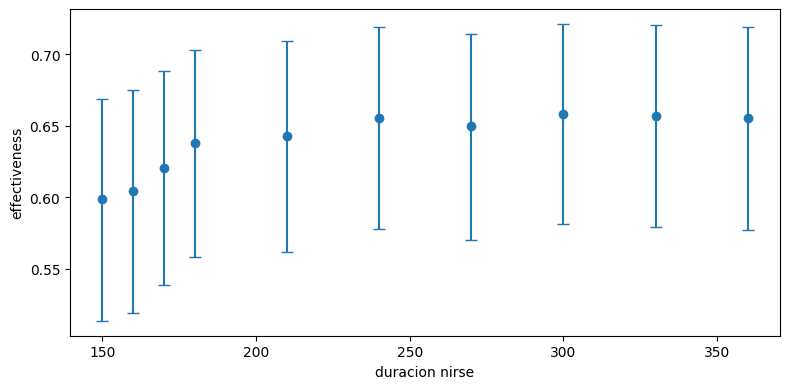

In [588]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) construir tabla para graficar
rows = []
for key, df_sum in summarys.items():
    rows.append({
        "key": key,
        "effectiveness": df_sum["effectiveness"].iloc[0],
        "lower": df_sum["eff_lower_95"].iloc[0],
        "upper": df_sum["eff_upper_95"].iloc[0],
    })

plot_df = pd.DataFrame(rows).sort_values("key")

y = plot_df["effectiveness"].to_numpy()
yerr_low  = (y - plot_df["lower"].to_numpy())
yerr_high = (plot_df["upper"].to_numpy() - y)
yerr = [yerr_low, yerr_high]

# 3) gráfico
plt.figure(figsize=(8, 4))
plt.errorbar(plot_df["key"], y, yerr=yerr, fmt="o", capsize=4)
plt.xlabel("duracion nirse")
plt.ylabel("effectiveness")
plt.tight_layout()
plt.show()


In [587]:
for dura in [160,170]:
    df_cox_vrs_duracion, _, _, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                            40,
                                                            group_age=False,
                                                            weeks_inm=False,
                                                            fin_inmune=True,
                                                            cohort='2025',
                                                            T_inicial = pd.to_datetime('2025-03-01'),
                                                            fecha_dt = pd.to_datetime('2025-09-30'),
                                                            duracion_dias_nirse=dura, 
                                                            eliminar_inmunes_pre_season=False,
                                                            meses_inm_bool=False)
    dicc_df[dura] = df_cox_vrs_duracion.copy()
    
    covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac']
    df_cox = df_cox_vrs_duracion.copy()
    ctv_0 = CoxTimeVaryingFitter()
    strata = ['region','mes_nac_name','semana_nac','SEMANAS']
    ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
    print(dura)
    summary = printSummary(ctv_0)
    summarys[dura] = summary
    display(summary)

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1015
ruts perdidos por filtro semanas y peso:  597
Droped intersex: 6
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-0.927601,0.604498,0.099968,-1.123534,-0.731667,0.518894,0.674871,0.0
sexo,0.528015,-0.695563,0.053271,0.423605,0.632424,-0.882168,-0.527459,0.0


n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1015
ruts perdidos por filtro semanas y peso:  597
Droped intersex: 6
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-0.969105,0.620577,0.099806,-1.16472,-0.773489,0.538600,0.687990,0.0
sexo,0.529507,-0.698095,0.053285,0.42507,0.633945,-0.885032,-0.529697,0.0


LA IDEA DE LEO: COX 2024 EN 2025 SOLO 5-9

In [ ]:
###### esto es 2024 en 2025, el gran cálculo 5-9

df_cox_decay_5_9, _, df_f_decay_5_9, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                        40,
                                                        group_age=False,
                                                        weeks_inm=False,
                                                        fin_inmune=False,
                                                        cohort='both',
                                                        T_inicial = pd.to_datetime('2025-03-01'), # inicio marzo
                                                        fecha_dt = pd.to_datetime('2025-06-30'), # fin mayo
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=False,
                                                        # meses_inm=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
                                                        meses_inm_bool=False,
                                                        ef_2024_in_2025=True,
                                                        fecha_cohort_in = pd.to_datetime("2024-08-01"), #nacidos agosto,sep
                                                        fecha_cohort_out = pd.to_datetime("2024-10-30")) # y octubre 

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  345
ruts perdidos por filtro semanas y peso:  143
Droped intersex: 1
Datos perdidos por edad madre atípica: 48
Datos perdidos por fecha ingreso menor a fecha nacimiento: 4
vrs en los primeros 7 dias de na

In [52]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac']
df_cox = df_cox_decay_5_9.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','semana_nac','SEMANAS']
ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,19.63776,-3.377311e+08,10561.505748,-20680.533128,20719.808649,-inf,1.000000,0.998516
sexo,1.04320,-1.838286e+00,0.416062,0.227735,1.858666,-5.415172,-0.255752,0.012165


In [69]:
df_cox_decay_5_9.query('~(RUN.isin(@ruts_vacunas_post))').groupby(['inmunizado','event_vrs']).RUN.nunique().unstack()

event_vrs,0,1
inmunizado,,
0.0,735.0,NaN
1.0,33967.0,35.0


In [67]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','semana_nac']  # 

ruts_vacunas_post = df_f_decay_5_9[df_f_decay_5_9.fechaInm >= pd.to_datetime('2024-11-01')].RUN.unique()

df_tv = df_cox_decay_5_9.query('~(RUN.isin(@ruts_vacunas_post))').copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','semana_nac']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

ctv = CoxTimeVaryingFitter()
ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs",'inmunizado', "Group"]],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

1:1 ['1', '1']
here aaa
Total cases = 735, Total controls = 34002
Total cases matched is : 734, Total control matched is : 734
ratio: 1:1
No matched : 1
Iteration 1: norm_delta = 9.50e-01, step_size = 0.9500, log_lik = -0.69315, newton_decrement = 5.00e-01, seconds_since_start = 0.6
Iteration 2: norm_delta = 5.46e-01, step_size = 0.9500, log_lik = -0.13939, newton_decrement = 7.48e-02, seconds_since_start = 1.1
Iteration 3: norm_delta = 4.99e-01, step_size = 0.9500, log_lik = -0.04896, newton_decrement = 2.51e-02, seconds_since_start = 1.8
Iteration 4: norm_delta = 5.09e-01, step_size = 1.0000, log_lik = -0.01833, newton_decrement = 9.25e-03, seconds_since_start = 2.3
Iteration 5: norm_delta = 4.93e-01, step_size = 0.9800, log_lik = -0.00666, newton_decrement = 3.34e-03, seconds_since_start = 2.9
Iteration 6: norm_delta = 4.82e-01, step_size = 0.9604, log_lik = -0.00249, newton_decrement = 1.25e-03, seconds_since_start = 3.5
Iteration 7: norm_delta = 5.01e-01, step_size = 1.0000, log_l

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,18.720709,-1.349896e+08,7187.899556,-14069.303545,14106.744962,-inf,1.0,0.997922


In [68]:
df_tv_matched.groupby(['inmunizado','event_vrs']).RUN.nunique().unstack()

event_vrs,0,1
inmunizado,,
0.0,734.0,NaN
1.0,733.0,1.0


NO HAY CASOS EN 5-9 DE NO INMNES.

In [70]:
# amplio temporada, quito cohorte
df_cox_decay_5_9_v2, _, df_f_decay_5_9_v2, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                        40,
                                                        group_age=False,
                                                        weeks_inm=False,
                                                        fin_inmune=False,
                                                        cohort='both',
                                                        T_inicial = pd.to_datetime('2025-03-01'), # inicio marzo
                                                        fecha_dt = pd.to_datetime('2025-06-30'), # fin mayo
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=False,
                                                        # meses_inm=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
                                                        meses_inm_bool=False,
                                                        ef_2024_in_2025=True,
                                                        fecha_cohort_in = pd.to_datetime("2024-09-01"), #nacidos sep
                                                        fecha_cohort_out = pd.to_datetime("2024-10-30")) # y octubre 

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  225
ruts perdidos por filtro semanas y peso:  91
Droped intersex: 0
Datos perdidos por edad madre atípica: 32
Datos perdidos por fecha ingreso menor a fecha nacimiento: 3
vrs en los primeros 7 dias de nac

In [71]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac']
df_cox = df_cox_decay_5_9.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','semana_nac','SEMANAS']
ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,19.650599,-3.420950e+08,8156.629735,-15967.049918,16006.351116,-inf,1.00000,0.998078
sexo,0.201106,-2.227544e-01,0.229068,-0.247859,0.650071,-0.915677,0.21953,0.379981


In [73]:
df_f_decay_5_9.groupby(['inmunizado','event_vrs']).RUN.nunique().unstack()

event_vrs,0,1
inmunizado,,
0,446.0,NaN
1,23089.0,86.0


In [74]:
# amplio cohorte, misma temporada
df_cox_decay_5_10, _, df_f_decay_5_10, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                        40,
                                                        group_age=False,
                                                        weeks_inm=False,
                                                        fin_inmune=False,
                                                        cohort='both',
                                                        T_inicial = pd.to_datetime('2025-03-01'), # inicio marzo
                                                        fecha_dt = pd.to_datetime('2025-05-30'), # fin mayo
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=False,
                                                        # meses_inm=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
                                                        meses_inm_bool=False,
                                                        ef_2024_in_2025=True,
                                                        fecha_cohort_in = pd.to_datetime("2024-07-01"), #nacidos julio
                                                        fecha_cohort_out = pd.to_datetime("2024-10-30")) # y octubre 

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  439
ruts perdidos por filtro semanas y peso:  190
Droped intersex: 1
Datos perdidos por edad madre atípica: 77
Datos perdidos por fecha ingreso menor a fecha nacimiento: 4
vrs en los primeros 7 dias de na

In [75]:
df_f_decay_5_10.groupby(['inmunizado','event_vrs']).RUN.nunique().unstack()

event_vrs,0,1
inmunizado,,
0,978.0,NaN
1,46992.0,48.0


In [76]:
# amplio cohorte mucho , misma temporada
df_cox_decay_5_12, _, df_f_decay_5_12, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                        40,
                                                        group_age=False,
                                                        weeks_inm=False,
                                                        fin_inmune=False,
                                                        cohort='both',
                                                        T_inicial = pd.to_datetime('2025-03-01'), # inicio marzo
                                                        fecha_dt = pd.to_datetime('2025-05-30'), # fin mayo
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=False,
                                                        # meses_inm=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
                                                        meses_inm_bool=False,
                                                        ef_2024_in_2025=True,
                                                        fecha_cohort_in = pd.to_datetime("2024-05-01"), #nacidos mayo
                                                        fecha_cohort_out = pd.to_datetime("2024-10-30")) # y octubre 

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  705
ruts perdidos por filtro semanas y peso:  292
Droped intersex: 16
Datos perdidos por edad madre atípica: 121
Datos perdidos por fecha ingreso menor a fecha nacimiento: 4
vrs en los primeros 7 dias de 

In [77]:
df_f_decay_5_12.groupby(['inmunizado','event_vrs']).RUN.nunique().unstack()

event_vrs,0,1
inmunizado,,
0,1413,1
1,71281,71


In [78]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','semana_nac']  # 

ruts_vacunas_post = df_f_decay_5_12[df_f_decay_5_12.fechaInm >= pd.to_datetime('2024-11-01')].RUN.unique()

df_tv = df_cox_decay_5_12.query('~(RUN.isin(@ruts_vacunas_post))').copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','semana_nac']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

ctv = CoxTimeVaryingFitter()
ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs",'inmunizado', "Group"]],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

1:1 ['1', '1']
here aaa
Total cases = 1415, Total controls = 70322
Total cases matched is : 1414, Total control matched is : 1414
ratio: 1:1
No matched : 1
Iteration 1: norm_delta = 3.17e-01, step_size = 0.9500, log_lik = -2.07944, newton_decrement = 1.67e-01, seconds_since_start = 0.9
Iteration 2: norm_delta = 2.82e-02, step_size = 0.9500, log_lik = -1.91074, newton_decrement = 1.19e-03, seconds_since_start = 1.8
Iteration 3: norm_delta = 1.67e-03, step_size = 0.9500, log_lik = -1.90955, newton_decrement = 4.14e-06, seconds_since_start = 2.7
Iteration 4: norm_delta = 8.91e-05, step_size = 1.0000, log_lik = -1.90954, newton_decrement = 1.06e-08, seconds_since_start = 3.6
Iteration 5: norm_delta = 2.64e-09, step_size = 1.0000, log_lik = -1.90954, newton_decrement = 9.32e-18, seconds_since_start = 4.5
Convergence completed after 5 iterations.


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-0.693147,0.5,1.224745,-3.093603,1.707309,-4.514101,0.954662,0.571426


In [79]:
# amplio cohorte mucho , misma temporada
df_cox_decay_5_9_inm, _, df_f_decay_5_9_inm, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                        40,
                                                        group_age=False,
                                                        weeks_inm=False,
                                                        fin_inmune=False,
                                                        cohort='both',
                                                        T_inicial = pd.to_datetime('2025-03-01'), # inicio marzo
                                                        fecha_dt = pd.to_datetime('2025-05-30'), # fin mayo
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=False,
                                                        # meses_inm=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
                                                        meses_inm_bool=False,
                                                        ef_2024_in_2025=True,
                                                        fecha_cohort_in = pd.to_datetime("2024-08-01"), #nacidos mayo
                                                        fecha_cohort_out = pd.to_datetime("2024-10-30")) # y octubre 

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1770
ruts perdidos por filtro semanas y peso:  235
Droped intersex: 6
Datos perdidos por edad madre atípica: 188
Datos perdidos por fecha ingreso menor a fecha nacimiento: 7
vrs en los primeros 7 dias de 

In [81]:
df_f_decay_5_9_inm.groupby(['inmunizado','event_vrs']).RUN.nunique().unstack()

event_vrs,0,1
inmunizado,,
0,11565,11
1,34958,36


In [83]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','semana_nac']  # 

ruts_vacunas_post = df_f_decay_5_9_inm[df_f_decay_5_9_inm.fechaInm >= pd.to_datetime('2024-11-01')].RUN.unique()

df_tv = df_cox_decay_5_9_inm.query('~(RUN.isin(@ruts_vacunas_post))').copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','semana_nac']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

ctv = CoxTimeVaryingFitter()
ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs",'inmunizado', "Group"]],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

1:1 ['1', '1']
here aaa
Total cases = 11576, Total controls = 34994
Total cases matched is : 3952, Total control matched is : 3952
ratio: 1:1
No matched : 7624
Iteration 1: norm_delta = 2.38e-01, step_size = 0.9500, log_lik = -5.54518, newton_decrement = 2.50e-01, seconds_since_start = 2.6
Iteration 2: norm_delta = 1.69e-02, step_size = 0.9500, log_lik = -5.29371, newton_decrement = 1.20e-03, seconds_since_start = 5.2
Iteration 3: norm_delta = 9.20e-04, step_size = 0.9500, log_lik = -5.29251, newton_decrement = 3.52e-06, seconds_since_start = 7.9
Iteration 4: norm_delta = 4.86e-05, step_size = 1.0000, log_lik = -5.29251, newton_decrement = 8.87e-09, seconds_since_start = 10.5
Convergence completed after 4 iterations.


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,0.510826,-0.666667,0.730288,-0.920512,1.942163,-5.973823,0.601685,0.484249


In [86]:
df_tv_matched.groupby(['inmunizado','event_vrs']).RUN.nunique().unstack()

event_vrs,0,1
inmunizado,,
0.0,3949,3
1.0,3947,5


In [88]:
# amplio cohorte mucho , misma temporada
df_cox_decay_5_10_inm, _, df_f_decay_5_10_inm, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                        40,
                                                        group_age=False,
                                                        weeks_inm=False,
                                                        fin_inmune=False,
                                                        cohort='both',
                                                        T_inicial = pd.to_datetime('2025-03-01'), # inicio marzo
                                                        fecha_dt = pd.to_datetime('2025-06-30'), # fin mayo
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=False,
                                                        # meses_inm=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
                                                        meses_inm_bool=False,
                                                        ef_2024_in_2025=True,
                                                        fecha_cohort_in = pd.to_datetime("2024-08-01"), #nacidos mayo
                                                        fecha_cohort_out = pd.to_datetime("2024-10-30")) # y octubre 

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1770
ruts perdidos por filtro semanas y peso:  235
Droped intersex: 6
Datos perdidos por edad madre atípica: 188
Datos perdidos por fecha ingreso menor a fecha nacimiento: 7
vrs en los primeros 7 dias de 

In [92]:
df_f_decay_5_10_inm.groupby(['inmunizado','event_vrs']).RUN.nunique().unstack()

event_vrs,0,1
inmunizado,,
0,11540,36
1,34848,146


In [93]:
df_tv = df_cox_decay_5_10_inm.query('~(RUN.isin(@ruts_vacunas_post))').copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

In [97]:
for run in df_f_decay_5_10_inm.RUN.unique():
    if run in df_base.RUN.unique():
        continue
    else:
        print(run)

In [ ]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','semana_nac']  # 

ruts_vacunas_post = df_f_decay_5_10_inm[df_f_decay_5_10_inm.fechaInm >= pd.to_datetime('2024-11-01')].RUN.unique()

df_tv = df_cox_decay_5_10_inm.query('~(RUN.isin(@ruts_vacunas_post))').copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','semana_nac']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

In [89]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','semana_nac']  # 

ruts_vacunas_post = df_f_decay_5_10_inm[df_f_decay_5_10_inm.fechaInm >= pd.to_datetime('2024-11-01')].RUN.unique()

df_tv = df_cox_decay_5_10_inm.query('~(RUN.isin(@ruts_vacunas_post))').copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','semana_nac']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

ctv = CoxTimeVaryingFitter()
ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs",'inmunizado', "Group"]],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

1:1 ['1', '1']
here aaa
Total cases = 11576, Total controls = 34994
Total cases matched is : 3952, Total control matched is : 3952
ratio: 1:1
No matched : 7624
Iteration 1: norm_delta = 0.00e+00, step_size = 0.9500, log_lik = -9.70406, newton_decrement = 0.00e+00, seconds_since_start = 2.7
Convergence completed after 1 iterations.


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,0.0,0.0,0.534523,-1.047645,1.047645,-1.850929,0.649237,1.0


In [ ]:
df_tv_matched.groupby(['inmunizado','event_vrs']).RUN.nunique().unstack()

event_vrs,0,1
inmunizado,,
0.0,3945,7
1.0,3942,10


Método 2. 

In [106]:
df_cox_metodo2, df_vrs_matched_metodo2, df_f_vrs_metodo2 = call_data_cox_matched('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                        fin_inmune=False,
                                                        cohort='both',
                                                        T_inicial = pd.to_datetime('2024-04-01'), # inicio marzo
                                                        fecha_dt = pd.to_datetime('2025-09-30'), # fin mayo
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=False,
                                                        meses_inm=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17],
                                                        meses_inm_bool=True,
                                                        ef_2024_in_2025=False,
                                                        fecha_cohort_in = pd.to_datetime("2023-10-01"), #nacidos mayo
                                                        fecha_cohort_out = pd.to_datetime("2025-09-30")) # y octubre 

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  2536
ruts perdidos por filtro semanas y peso:  1130
Droped intersex: 28
Datos perdidos por edad madre atípica: 483
Datos perdidos por fecha ingreso menor a fecha nacimiento: 31
vrs en los primeros 7 dias 

In [110]:
import numpy as np
import pandas as pd
from lifelines.utils import add_covariate_to_timeline

def add_no_circulacion(df_tv, t0, t1, id_col="RUN", start_col="start", stop_col="stop", event_col="event_vrs"):
    df_tv = df_tv.copy()

    # IDs
    ids = df_tv[id_col].unique()

    # follow-up por individuo (stop máximo observado)
    fu = df_tv.groupby(id_col)[stop_col].max()

    # Solo individuos cuyo follow-up cruza t0 (si stop <= t0 nunca entran en no_circulacion=1)
    ids_t0 = fu[fu > t0].index
    # Solo individuos cuyo follow-up cruza t1 (si stop <= t1, no necesitan “volver a 0” en t1)
    ids_t1 = fu[fu > t1].index

    # Eventos de cambio (step function):
    # en t0 pasa a 1 (si el sujeto llega más allá de t0)
    # en t1 vuelve a 0 (si el sujeto llega más allá de t1)
    cv = pd.concat([
        pd.DataFrame({id_col: ids_t0, "time": t0, "no_circulacion": 1}),
        pd.DataFrame({id_col: ids_t1, "time": t1, "no_circulacion": 0}),
    ], ignore_index=True).sort_values([id_col, "time"])

    # Aplicar al timeline (esto SPLITEA intervalos donde corresponda)
    out = add_covariate_to_timeline(
        df_tv,
        cv,
        duration_col="time",
        id_col=id_col,
        event_col=event_col,
        cumulative_sum=False  # importante: queremos el valor "en ese tramo", no acumulado
    )

    # Rellenar valores antes del primer cambio con 0
    out["no_circulacion"] = out["no_circulacion"].fillna(0).astype(int)

    return out

t0=(pd.to_datetime('2024-09-30') - pd.to_datetime('2024-04-01')).days

t1=(pd.to_datetime('2025-03-30') - pd.to_datetime('2024-04-01')).days

df_cox_metodo2_nc = add_no_circulacion(df_cox_metodo2, t0=t0, t1=t1)


In [ ]:
columns_inm_tram = [f'inm_mayor_{k}_meses' for k in range(18)]
df_cox_metodo2_nc[['RUN','start','stop','inmunizado','event_vrs','no_circulacion']+columns_inm_tram]

In [114]:
df_cox_metodo2_nc.to_csv(path_data/'df_cox_metodo2_nc.csv')

In [126]:
df_cox_metodo2_nc_gr = df_cox_metodo2_nc.merge(df_vrs_matched_metodo2[['RUN','Group']], how='left', on='RUN').copy()

In [127]:
import numpy as np

df_cox_metodo2_nc_gr_mod = df_cox_metodo2_nc_gr.copy()

cols = [f"inm_mayor_{k}_meses" for k in range(18)]  

# matriz booleana (trata NaN como 0)
M = df_cox_metodo2_nc_gr_mod[cols].fillna(0).astype(int).to_numpy().astype(bool)

# buscar la columna activa de mayor k: invierto columnas y tomo el primer True
M_rev = M[:, ::-1]
has_any = M_rev.any(axis=1)
pos_rev = M_rev.argmax(axis=1)          # índice del primer True en el orden invertido (0..5)
k_max = (len(cols) - 1) - pos_rev       # convertir a k real (0..5)
k_max[~has_any] = -1                    # filas sin ningún 1

# construir la nueva matriz one-hot
newM = np.zeros_like(M, dtype=int)
rows = np.arange(M.shape[0])
mask = k_max >= 0
newM[rows[mask], k_max[mask]] = 1

# escribir de vuelta al df (sobrescribe esas columnas)
df_cox_metodo2_nc_gr_mod.loc[:, cols] = newM

In [128]:
r = 1/1

df = df_cox_metodo2_nc_gr_mod.copy()

df["w_ratio"] = 1.0
df.loc[df['no_circulacion']==1, "w_ratio"] = 0.00001

ctv = CoxTimeVaryingFitter()

columns_inm_tram = [f'inm_mayor_{k}_meses' for k in range(18)]
covs = ['start', 'stop', 'RUN', 'event_vrs','w_ratio','Group'] + columns_inm_tram
df_cox = df[covs].copy()
ctv_0 = CoxTimeVaryingFitter()
ctv_0.fit(df_cox.fillna(0), id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=['Group'], weights_col="w_ratio")
display(printSummary(ctv_0))

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inm_mayor_0_meses,-2.602689,0.925926,0.423098,-3.431946,-1.773432,8.302506e-01,0.967676,0.000000
inm_mayor_1_meses,-1.374318,0.746988,0.244269,-1.853075,-0.895560,5.916210e-01,0.843246,0.000000
inm_mayor_2_meses,-1.313724,0.731183,0.225283,-1.755271,-0.872176,5.819590e-01,0.827140,0.000000
inm_mayor_3_meses,-0.923671,0.602941,0.227471,-1.369505,-0.477836,3.798764e-01,0.745767,0.000049
inm_mayor_4_meses,-1.016934,0.638298,0.283020,-1.571642,-0.462226,3.701198e-01,0.792296,0.000327
inm_mayor_5_meses,0.182327,-0.200007,0.605527,-1.004485,1.369139,-2.931965e+00,0.633767,0.763335
inm_mayor_6_meses,-10.414353,0.999970,182.553012,-368.211681,347.382975,-7.353755e+150,1.000000,0.954507
inm_mayor_7_meses,10.819786,-49999.362927,223.347294,-426.932866,448.572437,-6.494329e+194,1.000000,0.961363
inm_mayor_8_meses,0.693152,-1.000010,1.224744,-1.707302,3.093606,-2.105647e+01,0.818646,0.571423


In [ ]:
# df_tv_matched_2 = (df_cox_metodo2_nc_gr_mod
#                    [~(df_cox_metodo2_nc_gr_mod.RUN.isin(df_tv_matched.query('inm_mayor_13_meses==1').RUN.unique()))]
#                    .copy())
df_tv_matched_2 = df_cox_metodo2_nc_gr_mod.copy()
df_tv_matched_2['inm_mayor_meses_agg_0_1'] = df_tv_matched_2[["inm_mayor_0_meses" ,'inm_mayor_1_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_2_3'] = df_tv_matched_2[["inm_mayor_2_meses" ,'inm_mayor_3_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_4_5'] = df_tv_matched_2[["inm_mayor_4_meses" ,'inm_mayor_5_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_6_7'] = df_tv_matched_2[["inm_mayor_6_meses" ,'inm_mayor_7_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_8_11'] = df_tv_matched_2[["inm_mayor_8_meses" ,'inm_mayor_9_meses','inm_mayor_10_meses','inm_mayor_11_meses']].sum(axis=1)
# df_tv_matched_2['inm_mayor_meses_agg_3_5'] = df_tv_matched_2[["inm_mayor_3_meses" ,'inm_mayor_4_meses','inm_mayor_5_meses']].sum(axis=1)
# df_tv_matched_2['inm_mayor_meses_agg_6'] = df_tv_matched_2[["inm_mayor_6_meses"]].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_mas_de_12'] = df_tv_matched_2[[f'inm_mayor_{k}_meses' for k in range(12,18)]].sum(axis=1)

columns_inm = ['inm_mayor_meses_agg_0_1','inm_mayor_meses_agg_2_3','inm_mayor_meses_agg_4_5','inm_mayor_meses_agg_6_7','inm_mayor_meses_agg_8_11','inm_mayor_meses_agg_mas_de_12'] #inm_mayor_meses_agg_6


df_tv_matched_2["w_ratio"] = 1.0
df_tv_matched_2.loc[df['no_circulacion']==1, "w_ratio"] = 0.00001

ctv.fit(
    df_tv_matched_2[["RUN", "start", "stop", "event_vrs", "Group",'w_ratio']+columns_inm],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    weights_col="w_ratio",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

Iteration 1: norm_delta = 6.53e-01, step_size = 0.9500, log_lik = -517.08778, newton_decrement = 8.84e+01, seconds_since_start = 8.9
Iteration 2: norm_delta = 1.29e-01, step_size = 0.9500, log_lik = -424.69090, newton_decrement = 2.88e+00, seconds_since_start = 16.7
Iteration 3: norm_delta = 2.24e-02, step_size = 0.9500, log_lik = -421.66155, newton_decrement = 7.04e-02, seconds_since_start = 25.0
Iteration 4: norm_delta = 1.79e-03, step_size = 1.0000, log_lik = -421.59036, newton_decrement = 3.84e-04, seconds_since_start = 33.5
Iteration 5: norm_delta = 3.59e-06, step_size = 1.0000, log_lik = -421.58997, newton_decrement = 1.54e-09, seconds_since_start = 41.7
Convergence completed after 5 iterations.


,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
inm_mayor_meses_agg_0_1,0.835366,0.752654,0.890419,0.000000,-1.804030,0.207688,-2.211090,-1.396969
inm_mayor_meses_agg_2_3,0.677019,0.558482,0.763731,0.000000,-1.130161,0.159505,-1.442785,-0.817536
inm_mayor_meses_agg_4_5,0.557692,0.277429,0.729250,0.001124,-0.815750,0.250418,-1.306559,-0.324940
inm_mayor_meses_agg_6_7,0.000000,-14.987506,0.937451,1.000000,-0.000000,1.414214,-2.771808,2.771808
inm_mayor_meses_agg_8_11,-1.307692,-3.424033,-0.203753,0.011787,0.836248,0.332049,0.185444,1.487052
inm_mayor_meses_agg_mas_de_12,-0.442623,-0.999709,-0.040732,0.027835,0.366463,0.166605,0.039924,0.693002


In [140]:
# df_tv_matched_2 = (df_cox_metodo2_nc_gr_mod
#                    [~(df_cox_metodo2_nc_gr_mod.RUN.isin(df_cox_metodo2_nc_gr_mod.query('inm_mayor_12_meses==1').RUN.unique()))]
#                    .copy())
df_tv_matched_2 = df_cox_metodo2_nc_gr_mod.copy()
df_tv_matched_2['inm_mayor_meses_agg_0_1'] = df_tv_matched_2[["inm_mayor_0_meses" ,'inm_mayor_1_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_2_3'] = df_tv_matched_2[["inm_mayor_2_meses" ,'inm_mayor_3_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_4_5'] = df_tv_matched_2[["inm_mayor_4_meses" ,'inm_mayor_5_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_6_7'] = df_tv_matched_2[["inm_mayor_6_meses" ,'inm_mayor_7_meses']].sum(axis=1)
df_tv_matched_2['inm_mayor_meses_agg_8_11'] = df_tv_matched_2[["inm_mayor_8_meses" ,'inm_mayor_9_meses','inm_mayor_10_meses','inm_mayor_11_meses']].sum(axis=1)
# df_tv_matched_2['inm_mayor_meses_agg_3_5'] = df_tv_matched_2[["inm_mayor_3_meses" ,'inm_mayor_4_meses','inm_mayor_5_meses']].sum(axis=1)
# df_tv_matched_2['inm_mayor_meses_agg_6'] = df_tv_matched_2[["inm_mayor_6_meses"]].sum(axis=1)
# df_tv_matched_2['inm_mayor_meses_agg_mas_de_12'] = df_tv_matched_2[[f'inm_mayor_{k}_meses' for k in range(12,18)]].sum(axis=1)

columns_inm = ['inm_mayor_meses_agg_0_1','inm_mayor_meses_agg_2_3','inm_mayor_meses_agg_4_5','inm_mayor_meses_agg_6_7','inm_mayor_meses_agg_8_11'] #inm_mayor_meses_agg_6


df_tv_matched_2["w_ratio"] = 1.0
df_tv_matched_2.loc[df['no_circulacion']==1, "w_ratio"] = 0.00001

ctv.fit(
    df_tv_matched_2[["RUN", "start", "stop", "event_vrs", "Group",'w_ratio']+columns_inm],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    weights_col="w_ratio",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

Iteration 1: norm_delta = 6.39e-01, step_size = 0.9500, log_lik = -517.07556, newton_decrement = 8.60e+01, seconds_since_start = 9.1
Iteration 2: norm_delta = 1.28e-01, step_size = 0.9500, log_lik = -427.12969, newton_decrement = 2.87e+00, seconds_since_start = 17.2
Iteration 3: norm_delta = 2.24e-02, step_size = 0.9500, log_lik = -424.10918, newton_decrement = 7.04e-02, seconds_since_start = 25.8
Iteration 4: norm_delta = 1.79e-03, step_size = 1.0000, log_lik = -424.03801, newton_decrement = 3.84e-04, seconds_since_start = 34.2
Iteration 5: norm_delta = 3.59e-06, step_size = 1.0000, log_lik = -424.03763, newton_decrement = 1.54e-09, seconds_since_start = 42.2
Convergence completed after 5 iterations.


,effectiveness,eff_lower_95,eff_upper_95,p,coef,se(coef),coef lower 95%,coef upper 95%
covariate,,,,,,,,
inm_mayor_meses_agg_0_1,0.835366,0.752654,0.890419,0.000000,-1.804029,0.207688,-2.211090,-1.396969
inm_mayor_meses_agg_2_3,0.677019,0.558482,0.763731,0.000000,-1.130160,0.159505,-1.442785,-0.817536
inm_mayor_meses_agg_4_5,0.557691,0.277428,0.729249,0.001124,-0.815747,0.250417,-1.306556,-0.324938
inm_mayor_meses_agg_6_7,0.000020,-14.986080,0.937448,0.999989,-0.000020,1.414178,-2.771758,2.771718
inm_mayor_meses_agg_8_11,-1.307694,-3.424036,-0.203754,0.011787,0.836249,0.332049,0.185445,1.487052


Método 4: Denis ratio

In [141]:
 ############################################################### CREACION DF COMPLETO ################################################################
meses = list(range(0, 17))  # 0..16
EVENT_COL = "event_vrs"
EV_DATE   = "fechaIng_vrs"
INM_DATE  = "fechaInm"

df = (df_f_vrs_tramos_final
      .assign(year_nac = lambda x: x.fecha_nac.dt.year,
              edad_relative = lambda x: x.fecha_nac -pd.to_datetime('2023-01-10'))
      [['RUN','fecha_nac','mes_nac_name','semana_nac',
        'SEMANAS','PESO','prematuro_extremo', 'muy_prematuro', 'prematuro_moderado', 'prematuro',
        'sexo','region','year_nac','eleg_group','eleg_2025','eleg_2024', 'MARCA', 'edad_relative',
        'event_vrs','fechaIng_vrs','fechaInm','inmunizado'] +
       [col for col in df_f_vrs_tramos_final.columns if col.startswith('inm_')]]
      .copy())

# Asegurar datetime
df[EV_DATE]  = pd.to_datetime(df[EV_DATE], errors="coerce")
df[INM_DATE] = pd.to_datetime(df[INM_DATE], errors="coerce")

# Eventos válidos
mask_event = df[EVENT_COL].eq(1) & df[EV_DATE].notna()

# Inicializa columna
df["evento_when_inmu"] = pd.NA

# Casos con evento pero sin fechaInm -> "never_inm"
mask_event_never = mask_event & df[INM_DATE].isna()
df.loc[mask_event_never, "evento_when_inmu"] = "never_inm"

# Casos con evento y con fechaInm
mask_event_has_inm = mask_event & df[INM_DATE].notna()

# Umbrales: fechaInm + m meses (m=0..16)  => matriz n x 17
thr = np.column_stack([
    (df.loc[mask_event_has_inm, INM_DATE] + pd.DateOffset(months=m)).to_numpy(dtype="datetime64[ns]")
    for m in meses
])

ev = df.loc[mask_event_has_inm, EV_DATE].to_numpy(dtype="datetime64[ns]")

# months_idx = #umbrales cumplidos - 1
# -1 => evento antes de inmunizarse
ge = ev[:, None] >= thr
m_idx = ge.sum(axis=1) - 1

# Etiquetas
labels = np.array([f"inm_{m}_meses" for m in meses], dtype=object)

evento_labels = np.where(
    m_idx < 0,
    "pre_inm",                       # evento ocurrió antes de fechaInm
    labels[np.clip(m_idx, 0, len(meses)-1)]  # si pasa de 16, lo dejamos como inm_16_meses
)

df.loc[mask_event_has_inm, "evento_when_inmu"] = evento_labels

# (opcional) ordenar categoría para tablas bonitas
ordered = ["never_inm", "pre_inm"] + [f"inm_{m}_meses" for m in meses]
df["evento_when_inmu"] = pd.Categorical(df["evento_when_inmu"], categories=ordered, ordered=True)

mask = df["inmunizado"].eq(1) & df["event_vrs"].eq(1) & df["fechaIng_vrs"].notna()

# create output column
df["k_window_event"] = np.nan

# assign k where fechaIng_vrs in [inm_k, inm_{k+1})
for k in range(16):
    s, e = f"inm_{k}_meses", f"inm_{k+1}_meses"
    if s not in df.columns or e not in df.columns:
        if k==16:
            cond_k = (
                mask
                & df[s].notna()
                & df["fechaIng_vrs"].ge(df[s])
            )
            df.loc[cond_k, "k_window_event"] = k
            continue
        else:
            continue

    cond_k = (
        mask
        & df[s].notna() & df[e].notna()
        & df["fechaIng_vrs"].ge(df[s])
        & df["fechaIng_vrs"].lt(df[e])   # [start, end)
    )
    df.loc[cond_k, "k_window_event"] = k

# (optional) if you want an integer dtype with missing values
df["k_window_event"] = df["k_window_event"].astype("Int64")

for k in range(1,17):
    df.loc[(df[f'inm_{k}_meses']>=df.fechaIng_vrs), f'inm_mayor_{k}_meses'] = -1


In [ ]:
k=3
df_query = df[(df[f'inm_mayor_{k}_meses']>=0) | (df.inmunizado==0)]
print(df_query.shape[0])
print(df_query.shape[0])


293655
255300


In [ ]:
k=3
df_query = (df[(df[f'inm_mayor_{k}_meses']>=0) | (df.inmunizado==0)]# me quedo con los inmunes que llegan a k meses que no tuvieorn evento antes y todos los no inmunes.
            [(df[f'inm_{k}_meses'].dt.month.between(3,10)) | (df[f'inm_{k}_meses'].isna())] ) # me quedo con inmunes en fechas temporada

df_control   = df_query.query("inmunizado == 0").copy()   ####### estan dados vuelta
df_cases = df_query.query(f"inm_mayor_{k}_meses == 1").copy() 

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases, #matcheo inmunes a no inmunes con reemplazo.
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0,
    with_replacement=True
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_matched = df_query.merge(match_map, on="RUN", how="inner").copy()

df_fechas_no_inmun = (df_matched
                    .query(f"inm_mayor_{k}_meses == 1")
                    [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                    .rename(columns={'Group':'RUN',
                                    f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                    f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                    .copy())

df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='RUN', how='left').copy()

s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
    
cond_k = (
    df_matched["inmunizado"].eq(0) & df_matched["event_vrs"].eq(1) & 
    df_matched["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
    & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
    & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
)

df_matched_merg.loc[cond_k, "k_window_event"] = k

res = (
    df_matched_merg
    .query(f'k_window_event=={k}')
    .groupby('inmunizado')['RUN'].nunique()
    .rename('run_cases')
    .reset_index()
    .merge(
        df_matched_merg.groupby('inmunizado')['RUN'].nunique().rename('run_total').reset_index(),
        on='inmunizado',
        how='left'
    )
    .assign(risk=lambda x: x.run_cases / x.run_total)
)
RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
VE = 1-RR

r0 = res.set_index("inmunizado")

risk_0 = r0.loc[0, "risk"]
risk_1 = r0.loc[1, "risk"]

cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
cases_1 = int(r0.loc[1, "run_cases"])   # inmune

total_0 = int(r0.loc[0, "run_total"])
total_1 = int(r0.loc[1, "run_total"])

RR = risk_1 / risk_0
VE = 1 - RR

summa = pd.DataFrame({
    "k": k,
    "RR": RR,
    "VE": VE,
    "cases_no_inmune": int(r0.loc[0, "run_cases"]),
    "cases_inmune": int(r0.loc[1, "run_cases"]),
    "total_no_inmune": int(r0.loc[0, "run_total"]),
    "total_inmune": int(r0.loc[1, "run_total"]),
    "risk_no_inmune": risk_0,
    "risk_inmune": risk_1,
})
summa

1:1 ['1', '1']
here aaa
Total cases = 209522, Total controls = 12063
Total cases matched is : 206908, Total control matched is : 206908
ratio: 1:1
No matched : 2614


IndexError: index 0 is out of bounds for axis 0 with size 0

In [208]:
df_fechas_no_inmun = (df_matched
                    .query(f"inm_mayor_{k}_meses == 1")
                    [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                    .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                    f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                    .copy())

df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
    
cond_k = (
    df_matched["inmunizado"].eq(0) & df_matched["event_vrs"].eq(1) & 
    df_matched["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
    & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
    & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
)

df_matched_merg.loc[cond_k, "k_window_event"] = k

res = (
    df_matched_merg
    .query(f'k_window_event=={k}')
    .groupby('inmunizado')['RUN'].count()
    .rename('run_cases')
    .reset_index()
    .merge(
        df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
        on='inmunizado',
        how='left'
    )
    .assign(risk=lambda x: x.run_cases / x.run_total)
)
RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
VE = 1-RR

r0 = res.set_index("inmunizado")

risk_0 = r0.loc[0, "risk"]
risk_1 = r0.loc[1, "risk"]

cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
cases_1 = int(r0.loc[1, "run_cases"])   # inmune

total_0 = int(r0.loc[0, "run_total"])
total_1 = int(r0.loc[1, "run_total"])

RR = risk_1 / risk_0
VE = 1 - RR
rows=[]
new_row = {
"k": k,
"RR": RR,
"VE": VE,
"cases_no_inmune": int(r0.loc[0, "run_cases"]),
"cases_inmune": int(r0.loc[1, "run_cases"]),
"total_no_inmune": int(r0.loc[0, "run_total"]),
"total_inmune": int(r0.loc[1, "run_total"]),
"risk_no_inmune": risk_0,
"risk_inmune": risk_1,
}
rows.append(new_row)
new_row

{'k': 3,
 'RR': 0.23687150837988824,
 'VE': 0.7631284916201118,
 'cases_no_inmune': 1790,
 'cases_inmune': 424,
 'total_no_inmune': 206908,
 'total_inmune': 206908,
 'risk_no_inmune': 0.008651187967599127,
 'risk_inmune': 0.002049219943163145}

In [174]:
df_query.query('RUN.isin(@match_map.RUN)').inmunizado.value_counts()

inmunizado
1    206908
0      2493
Name: count, dtype: int64

In [203]:
match_map_copy = match_map.copy()

In [206]:
match_map

,RUN,Group
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b45158f684deb1d2967,523859c5cf172484f2e48146777d527a3c8557b9f3250b45158f684deb1d2967
1,2210152b4f55db42615f7896776dccfc0361fbebeb2d2da4744f4e1cc7b40067,2210152b4f55db42615f7896776dccfc0361fbebeb2d2da4744f4e1cc7b40067
2,09ec8d95d9872504a3fe47603e6fa6231da3a60ce2dc842a7c5100171cace61c,09ec8d95d9872504a3fe47603e6fa6231da3a60ce2dc842a7c5100171cace61c
3,28b7db8254a242af3ef60e9d6c2d8706331d48a8e3048d833d69c7f4967be13a,28b7db8254a242af3ef60e9d6c2d8706331d48a8e3048d833d69c7f4967be13a
4,d53f2b2a19d155d0c7f40764f00116abec55135bc49874c23d4ba022583f74bf,d53f2b2a19d155d0c7f40764f00116abec55135bc49874c23d4ba022583f74bf
...,...,...
413811,60b387fc267c42df40b8d317ad217e56492860917d1dd45eb01bdfba1290c582,9c43000f38c2897131073900e8d0467939a3f91f592dbb68e09c0b4f120821c7
413812,cbfc3c30be3902af63296731843cd6cf87eaf0e2f081a257f1192d979119a5b6,368373315f79dc57a7fa0b8d15f6bd444ff183aea3a399fbd02ba4451213f371
413813,3abd60025f8574db79bdbbfd62c8d8794b3f32b8065dee06ac5a80e818faae33,2c25821a954937149c8d39ed3e419a7c20c7b0863cf7a9a767e858fa076c5653
413814,d4d2ac81aae27a641ec499f07ece8f47e1059f425cf416086a58160e50b1e299,1bb2a460eb147d5e35437ee7acc748bc8bea8419c57eba94263dd976086fc0e5


In [ ]:
for k in [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]:
        df_query = (df
                [((df[f'inm_mayor_{k}_meses']>=0) & 
                (df[f'inm_{k}_meses'].dt.month.between(3,10)) & 
                (df.inmunizado==1)) | 
                (df.inmunizado==0)] 
                ) 

        df_control   = df_query.query("inmunizado == 0").query('~(RUN.isin(@match_map.RUN))').copy()   ####### estan dados vuelta
        df_cases = df_query.query(f"inm_mayor_{k}_meses == 1").query('~(RUN.isin(@match_map.RUN))').copy()   

        print(k,df_cases.shape[0], df_control.shape[0])

0 73197 9570
1 50882 9570
2 27313 9570
3 2614 9570
4 4985 9570
5 15131 9570
6 26279 9570
7 38310 9570
8 38482 9570
9 38858 9570
10 39171 9570
11 36270 9570
12 25134 9570
13 13423 9570
14 1208 9570
15 1007 9570
16 589 9570


In [310]:
k=9
df_query = (df
        [((df[f'inm_mayor_{k}_meses']>=0) & 
        (df[f'inm_{k}_meses'].dt.month.between(3,10)) & 
        (df.inmunizado==1)) | 
        (df.inmunizado==0)] 
        ) 

df_control   = df_query.query("inmunizado == 0").query('(RUN.isin(@match_map.RUN))').copy()   ####### estan dados vuelta
df_cases = df_query.query(f"inm_mayor_{k}_meses == 1").query('(RUN.isin(@match_map.RUN))').copy()   

In [311]:
df_cases.query(f'k_window_event=={k}')[['RUN',f'inm_{k}_meses',f'inm_{k+1}_meses','fechaIng_vrs','k_window_event']]


,RUN,inm_9_meses,inm_10_meses,fechaIng_vrs,k_window_event
139577,0d504fd14d678bbbd52dacf1ce6e3327a121daf0a0653de108c67015488a6bac,2025-04-06,2025-05-06,2025-04-20,9
139681,0a49a5a5c38803b5ae5450157232a78ee6464c9df0e77110e209659029e3b1b8,2025-04-09,2025-05-09,2025-05-02,9
148183,ee2df3601e00b2ff924d60686fb4de43faaa3bb789c7a6d75bb184f482fc8d7e,2025-04-30,2025-05-30,2025-05-22,9


In [309]:
df_matched.query(f'k_window_event=={k}')[['RUN',f'inm_{k}_meses',f'inm_{k+1}_meses','fechaIng_vrs','k_window_event']]

,RUN,inm_9_meses,inm_10_meses,fechaIng_vrs,k_window_event
231215,0d504fd14d678bbbd52dacf1ce6e3327a121daf0a0653de108c67015488a6bac,2025-04-06,2025-05-06,2025-04-20,9
231235,0a49a5a5c38803b5ae5450157232a78ee6464c9df0e77110e209659029e3b1b8,2025-04-09,2025-05-09,2025-05-02,9
231306,ee2df3601e00b2ff924d60686fb4de43faaa3bb789c7a6d75bb184f482fc8d7e,2025-04-30,2025-05-30,2025-05-22,9


In [308]:
df_matched_merg.query(f'k_window_event=={k}')[['RUN',f'inm_{k}_meses',f'inm_{k+1}_meses','fechaIng_vrs','k_window_event']]

,RUN,inm_9_meses,inm_10_meses,fechaIng_vrs,k_window_event
231215,0d504fd14d678bbbd52dacf1ce6e3327a121daf0a0653de108c67015488a6bac,2025-04-06,2025-05-06,2025-04-20,9
231235,0a49a5a5c38803b5ae5450157232a78ee6464c9df0e77110e209659029e3b1b8,2025-04-09,2025-05-09,2025-05-02,9
231306,ee2df3601e00b2ff924d60686fb4de43faaa3bb789c7a6d75bb184f482fc8d7e,2025-04-30,2025-05-30,2025-05-22,9


In [307]:
k=9
df_query = (df
        [((df[f'inm_mayor_{k}_meses']>=0) & 
        (df[f'inm_{k}_meses'].dt.month.between(3,10)) & 
        (df.inmunizado==1)) | 
        (df.inmunizado==0)] 
        ) 

df_matched = df_query.merge(match_map, on="RUN", how="inner").copy()

df_fechas_no_inmun = (df_matched
                    .query(f"inm_mayor_{k}_meses == 1")
                    [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                    .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                    f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                    .copy())

df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
    
cond_k = (
    df_matched["inmunizado"].eq(0) & df_matched["event_vrs"].eq(1) & 
    df_matched["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
    & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
    & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
)

df_matched_merg.loc[cond_k, "k_window_event"] = k

res = (
    df_matched_merg
    .query(f'k_window_event=={k}')
    .groupby('inmunizado')['RUN'].count()
    .rename('run_cases')
    .reset_index()
    .merge(
        df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
        on='inmunizado',
        how='left'
    )
    .assign(risk=lambda x: x.run_cases / x.run_total)
)
res

,inmunizado,run_cases,run_total,risk
0,1,3,30900,0.000097


In [278]:
df_matched_merg.query('k_window_event==9')

,RUN,fecha_nac,mes_nac_name,semana_nac,SEMANAS,PESO,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,sexo,region,year_nac,eleg_group,eleg_2025,eleg_2024,MARCA,edad_relative,event_vrs,fechaIng_vrs,fechaInm,inmunizado,inm_0_meses,inm_mayor_0_meses,inm_1_meses,inm_mayor_1_meses,inm_2_meses,inm_mayor_2_meses,inm_3_meses,inm_mayor_3_meses,inm_4_meses,inm_mayor_4_meses,inm_5_meses,inm_mayor_5_meses,inm_6_meses,inm_mayor_6_meses,inm_7_meses,inm_mayor_7_meses,inm_8_meses,inm_mayor_8_meses,inm_9_meses,inm_mayor_9_meses,inm_10_meses,inm_mayor_10_meses,inm_11_meses,inm_mayor_11_meses,inm_12_meses,inm_mayor_12_meses,inm_13_meses,inm_mayor_13_meses,inm_14_meses,inm_mayor_14_meses,inm_15_meses,inm_mayor_15_meses,inm_16_meses,inm_mayor_16_meses,evento_when_inmu,k_window_event,Group,PAIR_inm_9_meses,PAIR_inm_10_meses
231215,0d504fd14d678bbbd52dacf1ce6e3327a121daf0a0653de108c67015488a6bac,2024-07-05,July,27,40.0,3760.0,0,0,0,0,0,METROPOLITANA,2024,seasonal_2024,no_elegible_2025,SEASONAL,0,542 days,1,2025-04-20,2024-07-06,1,2024-07-06,1,2024-08-06,1,2024-09-06,1,2024-10-06,1,2024-11-06,1,2024-12-06,1,2025-01-06,1,2025-02-06,1,2025-03-06,1,2025-04-06,1,2025-05-06,-1,2025-06-06,-1,2025-07-06,-1,2025-08-06,-1,2025-09-06,-1,NaT,0,NaT,0,inm_9_meses,9,0d504fd14d678bbbd52dacf1ce6e3327a121daf0a0653de108c67015488a6bac,2025-04-06,2025-05-06
231235,0a49a5a5c38803b5ae5450157232a78ee6464c9df0e77110e209659029e3b1b8,2024-07-07,July,27,38.0,3215.0,0,0,0,0,0,LOS LAGOS,2024,seasonal_2024,no_elegible_2025,SEASONAL,0,544 days,1,2025-05-02,2024-07-09,1,2024-07-09,1,2024-08-09,1,2024-09-09,1,2024-10-09,1,2024-11-09,1,2024-12-09,1,2025-01-09,1,2025-02-09,1,2025-03-09,1,2025-04-09,1,2025-05-09,-1,2025-06-09,-1,2025-07-09,-1,2025-08-09,-1,2025-09-09,-1,NaT,0,NaT,0,inm_9_meses,9,0a49a5a5c38803b5ae5450157232a78ee6464c9df0e77110e209659029e3b1b8,2025-04-09,2025-05-09
231306,ee2df3601e00b2ff924d60686fb4de43faaa3bb789c7a6d75bb184f482fc8d7e,2024-07-27,July,30,40.0,3105.0,0,0,0,0,1,METROPOLITANA,2024,seasonal_2024,no_elegible_2025,SEASONAL,0,564 days,1,2025-05-22,2024-07-30,1,2024-07-30,1,2024-08-30,1,2024-09-30,1,2024-10-30,1,2024-11-30,1,2024-12-30,1,2025-01-30,1,2025-02-28,1,2025-03-30,1,2025-04-30,1,2025-05-30,-1,2025-06-30,-1,2025-07-30,-1,2025-08-30,-1,2025-09-30,-1,NaT,0,NaT,0,inm_9_meses,9,ee2df3601e00b2ff924d60686fb4de43faaa3bb789c7a6d75bb184f482fc8d7e,2025-04-30,2025-05-30


In [ ]:
RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
VE = 1-RR

r0 = res.set_index("inmunizado")

risk_0 = r0.loc[0, "risk"]
risk_1 = r0.loc[1, "risk"]

cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
cases_1 = int(r0.loc[1, "run_cases"])   # inmune

total_0 = int(r0.loc[0, "run_total"])
total_1 = int(r0.loc[1, "run_total"])

RR = risk_1 / risk_0
VE = 1 - RR
new_row = {
"k": k,
"RR": RR,
"VE": VE,
"cases_no_inmune": int(r0.loc[0, "run_cases"]),
"cases_inmune": int(r0.loc[1, "run_cases"]),
"total_no_inmune": int(r0.loc[0, "run_total"]),
"total_inmune": int(r0.loc[1, "run_total"]),
"risk_no_inmune": risk_0,
"risk_inmune": risk_1,
}
new_row

In [318]:
match_map_all

,RUN,Group
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b45158f684deb1d2967,523859c5cf172484f2e48146777d527a3c8557b9f3250b45158f684deb1d2967
1,2210152b4f55db42615f7896776dccfc0361fbebeb2d2da4744f4e1cc7b40067,2210152b4f55db42615f7896776dccfc0361fbebeb2d2da4744f4e1cc7b40067
2,09ec8d95d9872504a3fe47603e6fa6231da3a60ce2dc842a7c5100171cace61c,09ec8d95d9872504a3fe47603e6fa6231da3a60ce2dc842a7c5100171cace61c
3,28b7db8254a242af3ef60e9d6c2d8706331d48a8e3048d833d69c7f4967be13a,28b7db8254a242af3ef60e9d6c2d8706331d48a8e3048d833d69c7f4967be13a
4,d53f2b2a19d155d0c7f40764f00116abec55135bc49874c23d4ba022583f74bf,d53f2b2a19d155d0c7f40764f00116abec55135bc49874c23d4ba022583f74bf
...,...,...
5645,8cced9cf533dd328b7f8474790a419f5410a7ab2ec436ea7909a6134a99f43c1,9fb73db4c834bd3f931e0a542099f8819659e6403b640e153dc3e57de1c06f8a
5646,1f5bdfb29b364808636b6972ceb02bef24514f06776cc4361cea219228d7f331,26f9c84d75c2db500c3185bdb8db38212adb3c9bc1263d12ee5a18d96b79b205
5647,1f5bdfb29b364808636b6972ceb02bef24514f06776cc4361cea219228d7f331,c3f02412a78808011428fe5910fb8f9dd35e34da005a6ba877f66f98129334b6
5648,fb899b2f1f45f94edfb66f79dbb71524f1ab7a16290641c2c5ced124cf2e8749,0aeb21ed1943b6c9c28bd0eeba0834f0502f917b3ecd8d8a86c0d2e9700bab4b


In [319]:
match_map

,RUN,Group
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b45158f684deb1d2967,523859c5cf172484f2e48146777d527a3c8557b9f3250b45158f684deb1d2967
1,2210152b4f55db42615f7896776dccfc0361fbebeb2d2da4744f4e1cc7b40067,2210152b4f55db42615f7896776dccfc0361fbebeb2d2da4744f4e1cc7b40067
2,09ec8d95d9872504a3fe47603e6fa6231da3a60ce2dc842a7c5100171cace61c,09ec8d95d9872504a3fe47603e6fa6231da3a60ce2dc842a7c5100171cace61c
3,28b7db8254a242af3ef60e9d6c2d8706331d48a8e3048d833d69c7f4967be13a,28b7db8254a242af3ef60e9d6c2d8706331d48a8e3048d833d69c7f4967be13a
4,d53f2b2a19d155d0c7f40764f00116abec55135bc49874c23d4ba022583f74bf,d53f2b2a19d155d0c7f40764f00116abec55135bc49874c23d4ba022583f74bf
...,...,...
413811,60b387fc267c42df40b8d317ad217e56492860917d1dd45eb01bdfba1290c582,9c43000f38c2897131073900e8d0467939a3f91f592dbb68e09c0b4f120821c7
413812,cbfc3c30be3902af63296731843cd6cf87eaf0e2f081a257f1192d979119a5b6,368373315f79dc57a7fa0b8d15f6bd444ff183aea3a399fbd02ba4451213f371
413813,3abd60025f8574db79bdbbfd62c8d8794b3f32b8065dee06ac5a80e818faae33,2c25821a954937149c8d39ed3e419a7c20c7b0863cf7a9a767e858fa076c5653
413814,d4d2ac81aae27a641ec499f07ece8f47e1059f425cf416086a58160e50b1e299,1bb2a460eb147d5e35437ee7acc748bc8bea8419c57eba94263dd976086fc0e5


In [ ]:
k=4
match_map_all=match_map.copy()
df_query = (df
        [((df[f'inm_mayor_{k}_meses']>=0) & 
        (df[f'inm_{k}_meses'].dt.month.between(3,10)) & 
        (df.inmunizado==1)) | 
        (df.inmunizado==0)] 
        ) 

df_control   = df_query.query("inmunizado == 0").copy()
df_cases = df_query.query(f"inm_mayor_{k}_meses == 1").query('~(RUN.isin(@match_map_all.RUN))').copy()  

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases, #matcheo inmunes a no inmunes con reemplazo.
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0,
    with_replacement=True
)

match_map_k = matched_base[["RUN", "Group"]].drop_duplicates()
match_map_all = pd.concat([match_map_all,match_map_k])

df_matched = (df_query.merge(match_map_all, on="RUN", how="inner").copy())

df_fechas_no_inmun = (df_matched
                    .query(f"inm_mayor_{k}_meses == 1")
                    [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                    .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                    f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                    .copy())

df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
    
cond_k = (
    df_matched["inmunizado"].eq(0) & df_matched["event_vrs"].eq(1) & 
    df_matched["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
    & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
    & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
)

df_matched_merg.loc[cond_k, "k_window_event"] = k

res = (
    df_matched_merg
    .query(f'k_window_event=={k}')
    .groupby('inmunizado')['RUN'].count()
    .rename('run_cases')
    .reset_index()
    .merge(
        df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
        on='inmunizado',
        how='left'
    )
    .assign(risk=lambda x: x.run_cases / x.run_total)
)
RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
VE = 1-RR

r0 = res.set_index("inmunizado")

risk_0 = r0.loc[0, "risk"]
risk_1 = r0.loc[1, "risk"]

cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
cases_1 = int(r0.loc[1, "run_cases"])   # inmune

total_0 = int(r0.loc[0, "run_total"])
total_1 = int(r0.loc[1, "run_total"])

RR = risk_1 / risk_0
VE = 1 - RR
new_row = {
"k": k,
"RR": RR,
"VE": VE,
"cases_no_inmune": int(r0.loc[0, "run_cases"]),
"cases_inmune": int(r0.loc[1, "run_cases"]),
"total_no_inmune": int(r0.loc[0, "run_total"]),
"total_inmune": int(r0.loc[1, "run_total"]),
"risk_no_inmune": risk_0,
"risk_inmune": risk_1,
}
print(new_row)
rows.append(new_row)


1:1 ['1', '1']
here aaa
Total cases = 4985, Total controls = 12063
Total cases matched is : 2825, Total control matched is : 2825
ratio: 1:1
No matched : 2160
{'k': 4, 'RR': 0.3900778602553031, 'VE': 0.6099221397446969, 'cases_no_inmune': 967, 'cases_inmune': 330, 'total_no_inmune': 209733, 'total_inmune': 183486, 'risk_no_inmune': 0.004610623983827057, 'risk_inmune': 0.0017985023380530396}


In [338]:
cond_k.sum()

0

In [ ]:
df_matched = (df_query.merge(match_map_all, on="RUN", how="inner").copy())

df_matched = df_matched.query('Group.isin(@df_matched.RUN.unique())')

df_fechas_no_inmun = (df_matched
                    .query(f"inm_mayor_{k}_meses == 1")
                    [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                    .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                    f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                    .copy())

df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
    
cond_k = (
    df_matched["inmunizado"].eq(0) & df_matched["event_vrs"].eq(1) & 
    df_matched["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
    & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
    & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
)

df_matched_merg.loc[cond_k, "k_window_event"] = k

res = (
    df_matched_merg
    .query(f'k_window_event=={k}')
    .groupby('inmunizado')['RUN'].count()
    .rename('run_cases')
    .reset_index()
    .merge(
        df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
        on='inmunizado',
        how='left'
    )
    .assign(risk=lambda x: x.run_cases / x.run_total)
)
RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
VE = 1-RR

r0 = res.set_index("inmunizado")

risk_0 = r0.loc[0, "risk"]
risk_1 = r0.loc[1, "risk"]

cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
cases_1 = int(r0.loc[1, "run_cases"])   # inmune

total_0 = int(r0.loc[0, "run_total"])
total_1 = int(r0.loc[1, "run_total"])

RR = risk_1 / risk_0
VE = 1 - RR
new_row = {
"k": k,
"RR": RR,
"VE": VE,
"cases_no_inmune": int(r0.loc[0, "run_cases"]),
"cases_inmune": int(r0.loc[1, "run_cases"]),
"total_no_inmune": int(r0.loc[0, "run_total"]),
"total_inmune": int(r0.loc[1, "run_total"]),
"risk_no_inmune": risk_0,
"risk_inmune": risk_1,
}
print(new_row)
rows.append(new_row)

{'k': 4, 'RR': 0.34126163391933817, 'VE': 0.6587383660806618, 'cases_no_inmune': 967, 'cases_inmune': 330, 'total_no_inmune': 183486, 'total_inmune': 183486, 'risk_no_inmune': 0.005270156851203907, 'risk_inmune': 0.0017985023380530396}


In [335]:
res

,inmunizado,run_cases,run_total,risk
0,1,330,183486,0.001799


In [ ]:
list_k = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]
# rows=[]
for k in list_k:
    print(k)
    
    df_query = (df
            [((df[f'inm_mayor_{k}_meses']>=0) & 
            (df[f'inm_{k}_meses'].dt.month.between(3,10)) & 
            (df.inmunizado==1)) | 
            (df.inmunizado==0)] 
            ) 


    # df_control   = df_query.query("inmunizado == 0").copy()
    # df_cases = df_query.query(f"inm_mayor_{k}_meses == 1").query('~(RUN.isin(@match_map_all.RUN))').copy()  

    # match_vars_nn     = ['SEMANAS']
    # match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

    # matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    #     df_control=df_control,
    #     df_case=df_cases, #matcheo inmunes a no inmunes con reemplazo.
    #     match_vars_nn=match_vars_nn,
    #     match_vars_exact=match_vars_exact,
    #     ratio="1:1",
    #     max_distance=10.0,
    #     with_replacement=True
    # )

    # match_map_k = matched_base[["RUN", "Group"]].drop_duplicates()
    # match_map_all = pd.concat([match_map_all,match_map_k])

    df_matched = (df_query.merge(match_map_all, on="RUN", how="inner").copy())

    df_matched = df_matched.query('Group.isin(@df_matched.RUN.unique())')

    df_fechas_no_inmun = (df_matched
                        .query(f"inm_mayor_{k}_meses == 1")
                        [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                        .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                        f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                        .copy())

    df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

    s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
        
    cond_k = (
        df_matched_merg["inmunizado"].eq(0) & df_matched_merg["event_vrs"].eq(1) & 
        df_matched_merg["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
        & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
        & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
    )

    df_matched_merg.loc[cond_k, "k_window_event"] = k

    res = (
        df_matched_merg
        .query(f'k_window_event=={k}')
        .groupby('inmunizado')['RUN'].count()
        .rename('run_cases')
        .reset_index()
        .merge(
            df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
            on='inmunizado',
            how='left'
        )
        .assign(risk=lambda x: x.run_cases / x.run_total)
    )
    RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
    VE = 1-RR

    r0 = res.set_index("inmunizado")

    risk_0 = r0.loc[0, "risk"]
    risk_1 = r0.loc[1, "risk"]

    cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
    cases_1 = int(r0.loc[1, "run_cases"])   # inmune

    total_0 = int(r0.loc[0, "run_total"])
    total_1 = int(r0.loc[1, "run_total"])

    RR = risk_1 / risk_0
    VE = 1 - RR
    new_row = {
    "k": k,
    "RR": RR,
    "VE": VE,
    "cases_no_inmune": int(r0.loc[0, "run_cases"]),
    "cases_inmune": int(r0.loc[1, "run_cases"]),
    "total_no_inmune": int(r0.loc[0, "run_total"]),
    "total_inmune": int(r0.loc[1, "run_total"]),
    "risk_no_inmune": risk_0,
    "risk_inmune": risk_1,
    }
    print(new_row)
    rows.append(new_row)
    
summary = pd.DataFrame(rows)
summary

6
{'k': 6, 'RR': 1.2380952380952381, 'VE': -0.23809523809523814, 'cases_no_inmune': 21, 'cases_inmune': 26, 'total_no_inmune': 112244, 'total_inmune': 112244, 'risk_no_inmune': 0.00018709240583015573, 'risk_inmune': 0.00023163821674209757}
9
{'k': 9, 'RR': 0.6688741721854304, 'VE': 0.33112582781456956, 'cases_no_inmune': 151, 'cases_inmune': 101, 'total_no_inmune': 68211, 'total_inmune': 68211, 'risk_no_inmune': 0.0022137191948512704, 'risk_inmune': 0.0014806995939071412}
12
{'k': 12, 'RR': 2.5384615384615383, 'VE': -1.5384615384615383, 'cases_no_inmune': 91, 'cases_inmune': 231, 'total_no_inmune': 142145, 'total_inmune': 142145, 'risk_no_inmune': 0.0006401913538991874, 'risk_inmune': 0.0016251011291287065}
15
{'k': 15, 'RR': 0.9842271293375394, 'VE': 0.01577287066246058, 'cases_no_inmune': 317, 'cases_inmune': 312, 'total_no_inmune': 104056, 'total_inmune': 104056, 'risk_no_inmune': 0.0030464365341739065, 'risk_inmune': 0.002998385484738987}


,k,RR,VE,cases_no_inmune,cases_inmune,total_no_inmune,total_inmune,risk_no_inmune,risk_inmune
0,3,0.236872,0.763128,1790,424,206908,206908,0.008651,0.002049
1,6,2.038690,-1.038690,21,18,206908,86992,0.000101,0.000207
2,4,0.399944,0.600056,942,329,207101,180854,0.004549,0.001819
3,4,0.390078,0.609922,967,330,209733,183486,0.004611,0.001799
4,4,0.390078,0.609922,967,330,209733,183486,0.004611,0.001799
5,4,0.390078,0.609922,967,330,209733,183486,0.004611,0.001799
6,4,0.341262,0.658738,967,330,183486,183486,0.005270,0.001799
7,0,0.144737,0.855263,1672,242,275836,275836,0.006062,0.000877
8,6,1.238095,-0.238095,21,26,112244,112244,0.000187,0.000232
9,9,0.668874,0.331126,151,101,68211,68211,0.002214,0.001481


In [357]:
round(summary.drop_duplicates(subset='k',keep='last'),3).to_excel(path_data/'denis_ratio..xlsx')

In [360]:
list_k = [0,3,6,9,12,15]
rows_2=[]
dfs_match_map_k = {}
for k in list_k:
    
    print(k)
    
    df_query = (df
            [((df[f'inm_mayor_{k}_meses']>=0) & 
            (df[f'inm_{k}_meses'].dt.month.between(3,10)) & 
            (df.inmunizado==1)) | 
            (df.inmunizado==0)] 
            ) 
    
    df_control   = df_query.query("inmunizado == 0").copy()
    df_cases = df_query.query(f"inm_mayor_{k}_meses == 1").copy()  

    match_vars_nn     = ['SEMANAS']
    match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

    matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
        df_control=df_control,
        df_case=df_cases, #matcheo inmunes a no inmunes con reemplazo.
        match_vars_nn=match_vars_nn,
        match_vars_exact=match_vars_exact,
        ratio="1:1",
        max_distance=10.0,
        with_replacement=True
    )


    match_map_k = matched_base[["RUN", "Group"]].drop_duplicates()
    dfs_match_map_k[k] = match_map_k
    
    df_matched = (df_query.merge(match_map_k, on="RUN", how="inner").copy())

    df_fechas_no_inmun = (df_matched
                        .query(f"inm_mayor_{k}_meses == 1")
                        [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                        .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                        f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                        .copy())

    df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

    s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
    
    cond_k = (
        df_matched_merg["inmunizado"].eq(0) & df_matched_merg["event_vrs"].eq(1) & 
        df_matched_merg["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
        & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
        & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
    )

    df_matched_merg.loc[cond_k, "k_window_event"] = k

    res = (
        df_matched_merg
        .query(f'k_window_event=={k}')
        .groupby('inmunizado')['RUN'].count()
        .rename('run_cases')
        .reset_index()
        .merge(
            df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
            on='inmunizado',
            how='left'
        )
        .assign(risk=lambda x: x.run_cases / x.run_total)
    )
    RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
    VE = 1-RR

    r0 = res.set_index("inmunizado")

    risk_0 = r0.loc[0, "risk"]
    risk_1 = r0.loc[1, "risk"]

    cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
    cases_1 = int(r0.loc[1, "run_cases"])   # inmune

    total_0 = int(r0.loc[0, "run_total"])
    total_1 = int(r0.loc[1, "run_total"])

    RR = risk_1 / risk_0
    VE = 1 - RR
    new_row = {
    "k": k,
    "RR": RR,
    "VE": VE,
    "cases_no_inmune": int(r0.loc[0, "run_cases"]),
    "cases_inmune": int(r0.loc[1, "run_cases"]),
    "total_no_inmune": int(r0.loc[0, "run_total"]),
    "total_inmune": int(r0.loc[1, "run_total"]),
    "risk_no_inmune": risk_0,
    "risk_inmune": risk_1,
    }
    print(new_row)
    rows_2.append(new_row)
    
summary_2 = pd.DataFrame(rows_2)
summary_2

0
1:1 ['1', '1']
here aaa
Total cases = 279971, Total controls = 12063
Total cases matched is : 275836, Total control matched is : 275836
ratio: 1:1
No matched : 4135
{'k': 0, 'RR': 0.13489409141583056, 'VE': 0.8651059085841695, 'cases_no_inmune': 1794, 'cases_inmune': 242, 'total_no_inmune': 275836, 'total_inmune': 275836, 'risk_no_inmune': 0.006503864615206137, 'risk_inmune': 0.0008773329079598022}
3
1:1 ['1', '1']
here aaa
Total cases = 209522, Total controls = 12063
Total cases matched is : 206908, Total control matched is : 206908
ratio: 1:1
No matched : 2614
{'k': 3, 'RR': 0.23687150837988824, 'VE': 0.7631284916201118, 'cases_no_inmune': 1790, 'cases_inmune': 424, 'total_no_inmune': 206908, 'total_inmune': 206908, 'risk_no_inmune': 0.008651187967599127, 'risk_inmune': 0.002049219943163145}
6
1:1 ['1', '1']
here aaa
Total cases = 113271, Total controls = 12063
Total cases matched is : 112244, Total control matched is : 112244
ratio: 1:1
No matched : 1027
{'k': 6, 'RR': 1.238095238

,k,RR,VE,cases_no_inmune,cases_inmune,total_no_inmune,total_inmune,risk_no_inmune,risk_inmune
0,0,0.134894,0.865106,1794,242,275836,275836,0.006504,0.000877
1,3,0.236872,0.763128,1790,424,206908,206908,0.008651,0.002049
2,6,1.238095,-0.238095,21,26,112244,112244,0.000187,0.000232
3,9,0.545946,0.454054,185,101,68211,68211,0.002712,0.001481
4,12,1.290503,-0.290503,179,231,142145,142145,0.001259,0.001625
5,15,1.040000,-0.040000,300,312,104056,104056,0.002883,0.002998


In [414]:
summary_2

,k,RR,VE,cases_no_inmune,cases_inmune,total_no_inmune,total_inmune,risk_no_inmune,risk_inmune
0,0,0.134894,0.865106,1794,242,275836,275836,0.006504,0.000877
1,3,0.236872,0.763128,1790,424,206908,206908,0.008651,0.002049
2,6,1.238095,-0.238095,21,26,112244,112244,0.000187,0.000232
3,9,0.545946,0.454054,185,101,68211,68211,0.002712,0.001481
4,12,1.290503,-0.290503,179,231,142145,142145,0.001259,0.001625
5,15,1.040000,-0.040000,300,312,104056,104056,0.002883,0.002998


In [362]:
round(summary_2.drop_duplicates(subset='k',keep='last'),3).to_excel(path_data/'denis_ratio_duro.xlsx')

,RUN,Group
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b45158f684deb1d2967,523859c5cf172484f2e48146777d527a3c8557b9f3250b45158f684deb1d2967
1,2210152b4f55db42615f7896776dccfc0361fbebeb2d2da4744f4e1cc7b40067,2210152b4f55db42615f7896776dccfc0361fbebeb2d2da4744f4e1cc7b40067
2,09ec8d95d9872504a3fe47603e6fa6231da3a60ce2dc842a7c5100171cace61c,09ec8d95d9872504a3fe47603e6fa6231da3a60ce2dc842a7c5100171cace61c
3,28b7db8254a242af3ef60e9d6c2d8706331d48a8e3048d833d69c7f4967be13a,28b7db8254a242af3ef60e9d6c2d8706331d48a8e3048d833d69c7f4967be13a
4,d53f2b2a19d155d0c7f40764f00116abec55135bc49874c23d4ba022583f74bf,d53f2b2a19d155d0c7f40764f00116abec55135bc49874c23d4ba022583f74bf
...,...,...
551667,adfe487742afbbb9c4dee259241dee55cc0fc232e6ddce5f1d2135db17d01000,a45f085bf78e5c1689bccafcdd890c109eddbe1a4cc81bbfdd415e6aca2451e8
551668,39f934f734da41865f11e3ba86ee95a49b457a57135eeeffd332b0a4a2f9d172,a277b4f6a73efd17100e5d4fc5dcd457eb4ce2872a1d201046b67b372e55d5a8
551669,319a860a7dd3f22542b4d72bb840c0efbd023c08f76ea6e940b633ef61242e99,a40b7a5ce0d9b693357376de167a2e5255c24034561230e01db198194ccaf2b8
551670,f82ab4723241b659aae522d8848f5a2d1b4246f52aa7ebc168f991fc27bc3492,94bc8704f9390d53cfc8d40a5cf963bf6c01b165a8a0668512517e1901751874


In [382]:
match_map_all_0 = dfs_match_map_k[0].copy()
k=9

df_query = (df
        [((df[f'inm_mayor_{k}_meses']>=0) & 
        (df[f'inm_{k}_meses'].dt.month.between(3,10)) & 
        (df.inmunizado==1)) | 
        (df.inmunizado==0)] 
        ) 


df_control   = df_query.query("inmunizado == 0").copy()

df_cases_matched_al = df_query.query(f"inm_mayor_{k}_meses == 1").query('(RUN.isin(@match_map_all_0.RUN))').copy()
df_cases = df_query.query(f"inm_mayor_{k}_meses == 1").query('~(RUN.isin(@match_map_all_0.RUN))').copy()

match_vars_nn     = ['SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched_runs, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases, #matcheo inmunes a no inmunes con reemplazo.
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0,
    with_replacement=True
)

match_map_k = matched_base[["RUN", "Group"]].drop_duplicates()
match_map_all_0 = pd.concat([match_map_all_0,match_map_k])

1:1 ['1', '1']
here aaa
Total cases = 4477, Total controls = 12063
Total cases matched is : 2930, Total control matched is : 2930
ratio: 1:1
No matched : 1547


In [375]:
df_1c = df_cases_matched_al[['RUN']].merge(match_map_all_0, on="RUN", how="inner").copy()
df_2c = df_control[['RUN']].merge(match_map_all_0, on="RUN", how="inner").query('Group.isin(@df_1c.RUN)').copy()

match_map_con = pd.concat([df_1c,df_2c,match_map_k])
df_matched_2 = (df_query.merge(match_map_con, on="RUN", how="inner").copy())
df_matched_2.shape

(366972, 59)

In [376]:
df_matched = (df_query.merge(match_map_all_0, on="RUN", how="inner").copy())
df_matched = df_matched.query('Group.isin(@df_matched.RUN.unique())')
df_matched.shape

(366972, 59)

In [383]:
df_matched = (df_query.merge(match_map_all_0, on="RUN", how="inner").copy())

df_matched = df_matched.query('Group.isin(@df_matched.RUN.unique())')

df_fechas_no_inmun = (df_matched
                    .query(f"inm_mayor_{k}_meses == 1")
                    [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                    .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                    f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                    .copy())

df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
    
cond_k = (
    df_matched_merg["inmunizado"].eq(0) & df_matched_merg["event_vrs"].eq(1) & 
    df_matched_merg["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
    & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
    & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
)

df_matched_merg.loc[cond_k, "k_window_event"] = k

res = (
    df_matched_merg
    .query(f'k_window_event=={k}')
    .groupby('inmunizado')['RUN'].count()
    .rename('run_cases')
    .reset_index()
    .merge(
        df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
        on='inmunizado',
        how='left'
    )
    .assign(risk=lambda x: x.run_cases / x.run_total)
)
RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
VE = 1-RR

r0 = res.set_index("inmunizado")

risk_0 = r0.loc[0, "risk"]
risk_1 = r0.loc[1, "risk"]

cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
cases_1 = int(r0.loc[1, "run_cases"])   # inmune

total_0 = int(r0.loc[0, "run_total"])
total_1 = int(r0.loc[1, "run_total"])

RR = risk_1 / risk_0
VE = 1 - RR
new_row = {
"k": k,
"RR": RR,
"VE": VE,
"cases_no_inmune": int(r0.loc[0, "run_cases"]),
"cases_inmune": int(r0.loc[1, "run_cases"]),
"total_no_inmune": int(r0.loc[0, "run_total"]),
"total_inmune": int(r0.loc[1, "run_total"]),
"risk_no_inmune": risk_0,
"risk_inmune": risk_1,
}
print(new_row)

{'k': 9, 'RR': 0.6688741721854304, 'VE': 0.33112582781456956, 'cases_no_inmune': 151, 'cases_inmune': 101, 'total_no_inmune': 68211, 'total_inmune': 68211, 'risk_no_inmune': 0.0022137191948512704, 'risk_inmune': 0.0014806995939071412}


In [399]:
df_matched = (df_query.merge(match_map_all_0, on="RUN", how="inner").copy())

df_matched = df_matched.query('Group.isin(@df_matched.RUN.unique())')

df_fechas_no_inmun = (df_matched
                    .query(f"inm_mayor_{k}_meses == 1")
                    [['Group',f'inm_{k}_meses',f'inm_{k+1}_meses']]
                    .rename(columns={f'inm_{k}_meses': f'PAIR_inm_{k}_meses',
                                    f'inm_{k+1}_meses': f'PAIR_inm_{k+1}_meses'})
                    .copy())

df_matched_merg = df_matched.merge(df_fechas_no_inmun, on='Group', how='left').copy()

s, e = f"PAIR_inm_{k}_meses", f"PAIR_inm_{k+1}_meses"
    
cond_k = (
    df_matched_merg["inmunizado"].eq(0) & df_matched_merg["event_vrs"].eq(1) & 
    df_matched_merg["fechaIng_vrs"].notna() & df_matched_merg[s].notna() & df_matched_merg[e].notna()
    & df_matched_merg["fechaIng_vrs"].ge(df_matched_merg[s])
    & df_matched_merg["fechaIng_vrs"].lt(df_matched_merg[e])   # [start, end)
)

df_matched_merg.loc[cond_k, "k_window_event"] = k

res = (
    df_matched_merg
    .query(f'k_window_event=={k}')
    .groupby('inmunizado')['RUN'].count()
    .rename('run_cases')
    .reset_index()
    .merge(
        df_matched_merg.groupby('inmunizado')['RUN'].count().rename('run_total').reset_index(),
        on='inmunizado',
        how='left'
    )
    .assign(risk=lambda x: x.run_cases / x.run_total)
)
RR = res.query('inmunizado==1').risk.values[0] / res.query('inmunizado==0').risk.values[0] 
VE = 1-RR

r0 = res.set_index("inmunizado")

risk_0 = r0.loc[0, "risk"]
risk_1 = r0.loc[1, "risk"]

cases_0 = int(r0.loc[0, "run_cases"])   # no inmune
cases_1 = int(r0.loc[1, "run_cases"])   # inmune

total_0 = int(r0.loc[0, "run_total"])
total_1 = int(r0.loc[1, "run_total"])

RR = risk_1 / risk_0
VE = 1 - RR
new_row = {
"k": k,
"RR": RR,
"VE": VE,
"cases_no_inmune": int(r0.loc[0, "run_cases"]),
"cases_inmune": int(r0.loc[1, "run_cases"]),
"total_no_inmune": int(r0.loc[0, "run_total"]),
"total_inmune": int(r0.loc[1, "run_total"]),
"risk_no_inmune": risk_0,
"risk_inmune": risk_1,
}
print(new_row)

{'k': 9, 'RR': 0.6688741721854304, 'VE': 0.33112582781456956, 'cases_no_inmune': 151, 'cases_inmune': 101, 'total_no_inmune': 68211, 'total_inmune': 68211, 'risk_no_inmune': 0.0022137191948512704, 'risk_inmune': 0.0014806995939071412}


In [397]:
match_map_9 = dfs_match_map_k[9]

df_matched_9 = (df_query.merge(match_map_9, on="RUN", how="inner").copy())

df_matched_9[~(df_matched_9.RUN.isin(df_matched.RUN))]

,RUN,fecha_nac,mes_nac_name,semana_nac,SEMANAS,PESO,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,sexo,region,year_nac,eleg_group,eleg_2025,eleg_2024,MARCA,edad_relative,event_vrs,fechaIng_vrs,fechaInm,inmunizado,inm_0_meses,inm_mayor_0_meses,inm_1_meses,inm_mayor_1_meses,inm_2_meses,inm_mayor_2_meses,inm_3_meses,inm_mayor_3_meses,inm_4_meses,inm_mayor_4_meses,inm_5_meses,inm_mayor_5_meses,inm_6_meses,inm_mayor_6_meses,inm_7_meses,inm_mayor_7_meses,inm_8_meses,inm_mayor_8_meses,inm_9_meses,inm_mayor_9_meses,inm_10_meses,inm_mayor_10_meses,inm_11_meses,inm_mayor_11_meses,inm_12_meses,inm_mayor_12_meses,inm_13_meses,inm_mayor_13_meses,inm_14_meses,inm_mayor_14_meses,inm_15_meses,inm_mayor_15_meses,inm_16_meses,inm_mayor_16_meses,evento_when_inmu,k_window_event,Group
131,befb71e34268b457c4936268f8ce55a7ae5307d6ca945bb8bf8e5712a641c637,2023-10-01,October,39,38.0,3044.0,0,0,0,0,0,COQUIMBO,2023,catchup_2024,no_elegible_2025,CATCH_UP,0,264 days,0,NaT,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaN,<NA>,1acfbd93eaedbfb6bf70771baefbc4f11ef5f7b1b0821f9ddc3d55491943b9a9
132,befb71e34268b457c4936268f8ce55a7ae5307d6ca945bb8bf8e5712a641c637,2023-10-01,October,39,38.0,3044.0,0,0,0,0,0,COQUIMBO,2023,catchup_2024,no_elegible_2025,CATCH_UP,0,264 days,0,NaT,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaN,<NA>,89a36adb5e07a4fb2238327d936f828ffaf05c9690ac0115f6ab2ec96204727f
133,befb71e34268b457c4936268f8ce55a7ae5307d6ca945bb8bf8e5712a641c637,2023-10-01,October,39,38.0,3044.0,0,0,0,0,0,COQUIMBO,2023,catchup_2024,no_elegible_2025,CATCH_UP,0,264 days,0,NaT,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaN,<NA>,18817ea06ba98e54aac67ef60ad95b538c785b2c68c2749fd50dc327f6d0044e
134,befb71e34268b457c4936268f8ce55a7ae5307d6ca945bb8bf8e5712a641c637,2023-10-01,October,39,38.0,3044.0,0,0,0,0,0,COQUIMBO,2023,catchup_2024,no_elegible_2025,CATCH_UP,0,264 days,0,NaT,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaN,<NA>,e588a14aa7e569bb399895116d099d4b635cb0e7539c18077402908a4f2d6f15
135,befb71e34268b457c4936268f8ce55a7ae5307d6ca945bb8bf8e5712a641c637,2023-10-01,October,39,38.0,3044.0,0,0,0,0,0,COQUIMBO,2023,catchup_2024,no_elegible_2025,CATCH_UP,0,264 days,0,NaT,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaN,<NA>,775c39bd796e75d3f3f96c89e285605fb95aca4c6103d401ece4435ec4520b0f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135133,a074d7123886e5ffcbc7a0eb1d7320ebe9d228db0ea688bfaac60f2b8d53ec65,2024-06-11,June,24,37.0,2022.0,0,0,0,0,0,METROPOLITANA,2024,seasonal_2024,no_elegible_2025,SEASONAL,0,518 days,1,2025-08-15,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,never_inm,<NA>,ee2b8f249ca809ad90aa50a9a9227dffca1f4508089a8257cd6ad39f3628aa4b
135134,a074d7123886e5ffcbc7a0eb1d7320ebe9d228db0ea688bfaac60f2b8d53ec65,2024-06-11,June,24,37.0,2022.0,0,0,0,0,0,METROPOLITANA,2024,seasonal_2024,no_elegible_2025,SEASONAL,0,518 days,1,2025-08-15,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,never_inm,<NA>,825811cd79c42591743032be6d3a2b62485b1e1d818a4076af23281fd6db318d
135135,a074d7123886e5ffcbc7a0eb1d7320ebe9d228db0ea688bfaac60f2b8d53ec65,2024-06-11,June,24,37.0,2022.0,0,0,0,0,0,METROPOLITANA,2024,seasonal_2024,no_elegible_2025,SEASONAL,0,518 days,1,2025-08-15,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,never_inm,<NA>,6e3faeb3f633dcfd105546adf01fa330251f69019b45f3ae39a9530aad

In [ ]:
df

,RUN,fecha_nac,mes_nac_name,semana_nac,SEMANAS,PESO,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,sexo,region,year_nac,eleg_group,eleg_2025,eleg_2024,MARCA,edad_relative,event_vrs,fechaIng_vrs,fechaInm,inmunizado,inm_0_meses,inm_mayor_0_meses,inm_1_meses,inm_mayor_1_meses,inm_2_meses,inm_mayor_2_meses,inm_3_meses,inm_mayor_3_meses,inm_4_meses,inm_mayor_4_meses,inm_5_meses,inm_mayor_5_meses,inm_6_meses,inm_mayor_6_meses,inm_7_meses,inm_mayor_7_meses,inm_8_meses,inm_mayor_8_meses,inm_9_meses,inm_mayor_9_meses,inm_10_meses,inm_mayor_10_meses,inm_11_meses,inm_mayor_11_meses,inm_12_meses,inm_mayor_12_meses,inm_13_meses,inm_mayor_13_meses,inm_14_meses,inm_mayor_14_meses,inm_15_meses,inm_mayor_15_meses,inm_16_meses,inm_mayor_16_meses,evento_when_inmu,k_window_event
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b45158f684deb1d2967,2023-10-01,October,39,38.0,2865.0,0,0,0,0,1,METROPOLITANA,2023,catchup_2024,no_elegible_2025,CATCH_UP,0,264 days,0,NaT,2024-05-10,1,2024-05-10,1,2024-06-10,1,2024-07-10,1,2024-08-10,1,2024-09-10,1,2024-10-10,1,2024-11-10,1,2024-12-10,1,2025-01-10,1,2025-02-10,1,2025-03-10,1,2025-04-10,1,2025-05-10,1,2025-06-10,1,2025-07-10,1,2025-08-10,1,2025-09-10,1,NaN,<NA>
1,2210152b4f55db42615f7896776dccfc0361fbebeb2d2da4744f4e1cc7b40067,2023-10-02,October,40,38.0,2790.0,0,0,0,0,1,METROPOLITANA,2023,catchup_2024,no_elegible_2025,CATCH_UP,0,265 days,0,NaT,2024-04-12,1,2024-04-12,1,2024-05-12,1,2024-06-12,1,2024-07-12,1,2024-08-12,1,2024-09-12,1,2024-10-12,1,2024-11-12,1,2024-12-12,1,2025-01-12,1,2025-02-12,1,2025-03-12,1,2025-04-12,1,2025-05-12,1,2025-06-12,1,2025-07-12,1,2025-08-12,1,NaN,<NA>
2,09ec8d95d9872504a3fe47603e6fa6231da3a60ce2dc842a7c5100171cace61c,2023-10-01,October,39,34.0,1815.0,0,0,1,1,0,METROPOLITANA,2023,catchup_2024,no_elegible_2025,CATCH_UP,0,264 days,0,NaT,2024-05-28,1,2024-05-28,1,2024-06-28,1,2024-07-28,1,2024-08-28,1,2024-09-28,1,2024-10-28,1,2024-11-28,1,2024-12-28,1,2025-01-28,1,2025-02-28,1,2025-03-28,1,2025-04-28,1,2025-05-28,1,2025-06-28,1,2025-07-28,1,2025-08-28,1,2025-09-28,1,NaN,<NA>
4,28b7db8254a242af3ef60e9d6c2d8706331d48a8e3048d833d69c7f4967be13a,2023-10-01,October,39,34.0,2300.0,0,0,1,1,0,METROPOLITANA,2023,catchup_2024,no_elegible_2025,CATCH_UP,0,264 days,0,NaT,2024-05-28,1,2024-05-28,1,2024-06-28,1,2024-07-28,1,2024-08-28,1,2024-09-28,1,2024-10-28,1,2024-11-28,1,2024-12-28,1,2025-01-28,1,2025-02-28,1,2025-03-28,1,2025-04-28,1,2025-05-28,1,2025-06-28,1,2025-07-28,1,2025-08-28,1,2025-09-28,1,NaN,<NA>
6,d53f2b2a19d155d0c7f40764f00116abec55135bc49874c23d4ba022583f74bf,2023-10-04,October,40,39.0,3450.0,0,0,0,0,0,METROPOLITANA,2023,catchup_2024,no_elegible_2025,CATCH_UP,0,267 days,0,NaT,2024-04-30,1,2024-04-30,1,2024-05-30,1,2024-06-30,1,2024-07-30,1,2024-08-30,1,2024-09-30,1,2024-10-30,1,2024-11-30,1,2024-12-30,1,2025-01-30,1,2025-02-28,1,2025-03-30,1,2025-04-30,1,2025-05-30,1,2025-06-30,1,2025-07-30,1,2025-08-30,1,NaN,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223188,a45f085bf78e5c1689bccafcdd890c109eddbe1a4cc81bbfdd415e6aca2451e8,2024-12-17,December,51,38.0,2935.0,0,0,0,0,1,LOS RIOS,2024,exceso_seasonal_2024_and_catchup_2025,CATCH_UP,no_elegible_2024,0,707 days,0,NaT,2025-07-02,1,2025-07-02,1,2025-08-02,1,2025-09-02,1,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaN,<NA>
153697,a277b4f6a73efd17100e5d4fc5dcd457eb4ce2872a1d201046b67b372e55d5a8,2024-08-07,August,32,39.0,3760.0,0,0,0,0,0,METROPOLITANA,2024,seasonal_2024,no_elegible_2025,SEASONAL,0,575 days,0,NaT,2024-08-08,1,2024-08-08,1,2024-09-08,1,2024-10-08,1,2024-11-08,1,2024-12-08,1,2025-01-08,1,2025-02-08,1,2025-03-08,1,2025-04-08,1,2025-05-08,1,2025-06-08,1,2025-07-08,1,2025-08-08,1,2025-09-08,1,NaT,0,NaT,0,NaT,0,NaN,<NA>
22451,a40b7a5ce0d9b693357376de167a2e5255c24034561230e01db198194cc

In [428]:
import pandas as pd
import numpy as np

# =========================
# Helpers
# =========================
def _month_range(start, end):
    """
    start, end: strings or Timestamps, e.g. '2023-10-01', '2024-09-01'
    Returns month starts (MS frequency), inclusive.
    """
    return pd.date_range(pd.to_datetime(start), pd.to_datetime(end), freq="MS")


def _month_label(dt):
    month_abbr_en = {
        1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
        5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
        9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
    }
    return f"{month_abbr_en[dt.month]}-{dt.strftime('%y')}"


def build_birth_and_immune_tables(df, id_col="RUN", birth_col="fecha_nac", inm_col="fechaInm", max_k=16):
    """
    Construye dos tablas:
      - Oct-2023 ... Sep-2024
      - Oct-2024 ... Sep-2025

    Requisitos en df:
      - fecha_nac (datetime)
      - fechaInm (datetime o NaT)
      - columnas inm_0_meses ... inm_{max_k}_meses (datetime o NaT)
    """

    d = df.copy()

    # Asegurar datetime
    d[birth_col] = pd.to_datetime(d[birth_col], errors="coerce")
    d[inm_col]   = pd.to_datetime(d[inm_col], errors="coerce")

    for k in range(max_k + 1):
        col = f"inm_{k}_meses"
        if col in d.columns:
            d[col] = pd.to_datetime(d[col], errors="coerce")
        else:
            raise ValueError(f"Falta columna requerida: {col}")

    # Meses de las 2 tablas
    months_1 = _month_range("2023-10-01", "2024-09-01")
    months_2 = _month_range("2024-10-01", "2025-09-01")

    def _build_one_table(months):
        # Diccionario para armar columnas
        data_cols = {}

        for m_start in months:
            m_end = m_start + pd.offsets.MonthBegin(1)  # inicio del mes siguiente
            colname = _month_label(m_start)

            # -------------------------
            # 1) Born (Immunized / Non-immunized)
            # -------------------------
            born_mask = (d[birth_col] >= m_start) & (d[birth_col] < m_end)

            born_total = int(born_mask.sum())
            born_imm   = int((born_mask & d[inm_col].notna()).sum())
            born_non   = int((born_mask & d[inm_col].isna()).sum())
            
            born_imm_perc = round(born_imm*100/born_total,2)
            born_non_perc = round(born_non*100/born_total,2)

            # Texto compacto como pediste
            # born_text = f"{born_total} ({born_imm}/{born_non})"
            born_text = f"{born_total} ({born_non_perc}%)"

            # -------------------------
            # 2) Months being immune at start of month
            #    "i months and not i+1 months"
            # -------------------------
            col_values = {"Born (Non-imm%)": born_text}

            for i in range(max_k + 1):
                col_i = f"inm_{i}_meses"

                # Cumple ">= i meses al inicio del mes" equiv. a inm_i <= m_start
                has_i = d[col_i].notna() & (d[col_i] <= m_start)

                if i < max_k:
                    col_ip1 = f"inm_{i+1}_meses"
                    has_ip1 = d[col_ip1].notna() & (d[col_ip1] <= m_start)
                    mask_i_exact = has_i & (~has_ip1)
                else:
                    # Último bin = 16+ meses (porque no existe inm_17_meses)
                    mask_i_exact = has_i

                col_values[f"Months being immune = {i}"] = int(mask_i_exact.sum())

            data_cols[colname] = col_values

        # DataFrame final
        out = pd.DataFrame(data_cols)

        # Orden filas
        row_order = ["Born (Non-imm%)"] + [f"Months being immune = {i}" for i in range(max_k + 1)]
        out = out.loc[row_order]

        return out

    table_2023_2024 = _build_one_table(months_1)
    table_2024_2025 = _build_one_table(months_2)

    return table_2023_2024, table_2024_2025

In [429]:
tabla_23_24, tabla_24_25 = build_birth_and_immune_tables(df, max_k=16)

display(tabla_23_24)
display(tabla_24_25)

,Oct-23,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24,Sep-24
Born (Non-imm%),13397 (14.35%),12825 (10.81%),13132 (7.82%),13919 (7.23%),12747 (6.56%),13554 (5.64%),13292 (1.99%),12945 (1.72%),12111 (1.87%),12438 (2.03%),12328 (2.39%),12028 (2.7%)
Months being immune = 0,0,0,0,0,0,0,1647,52849,35194,17826,13931,12358
Months being immune = 1,0,0,0,0,0,0,0,1647,52849,35194,17826,13931
Months being immune = 2,0,0,0,0,0,0,0,0,1647,52849,35194,17826
Months being immune = 3,0,0,0,0,0,0,0,0,0,1647,52849,35194
Months being immune = 4,0,0,0,0,0,0,0,0,0,0,1647,52849
Months being immune = 5,0,0,0,0,0,0,0,0,0,0,0,1647
Months being immune = 6,0,0,0,0,0,0,0,0,0,0,0,0
Months being immune = 7,0,0,0,0,0,0,0,0,0,0,0,0
Months being immune = 8,0,0,0,0,0,0,0,0,0,0,0,0


,Oct-24,Nov-24,Dec-24,Jan-25,Feb-25,Mar-25,Apr-25,May-25,Jun-25,Jul-25,Aug-25,Sep-25
Born (Non-imm%),12123 (1.11%),11432 (4.43%),11925 (4.91%),12590 (3.95%),11269 (3.2%),12344 (1.09%),12303 (1.56%),12208 (1.41%),11298 (1.52%),11268 (1.42%),10960 (2.06%),10675 (3.67%)
Months being immune = 0,12050,10950,2835,80,6,448,34868,26375,15592,12699,11861,10964
Months being immune = 1,12358,12050,10950,2835,80,6,448,34868,26375,15592,12699,11861
Months being immune = 2,13931,12358,12050,10950,2835,80,6,448,34868,26375,15592,12699
Months being immune = 3,17826,13931,12358,12050,10950,2835,80,6,448,34868,26375,15592
Months being immune = 4,35194,17826,13931,12358,12050,10950,2835,80,6,448,34868,26375
Months being immune = 5,52849,35194,17826,13931,12358,12050,10950,2835,80,6,448,34868
Months being immune = 6,1647,52849,35194,17826,13931,12358,12050,10950,2835,80,6,448
Months being immune = 7,0,1647,52849,35194,17826,13931,12358,12050,10950,2835,80,6
Months being immune = 8,0,0,1647,52849,35194,17826,13931,12358,12050,10950,2835,80


In [430]:
tabla_23_24.to_excel(path_data/'tabla_1_decay_report.xlsx')
tabla_24_25.to_excel(path_data/'tabla_2_decay_report.xlsx')

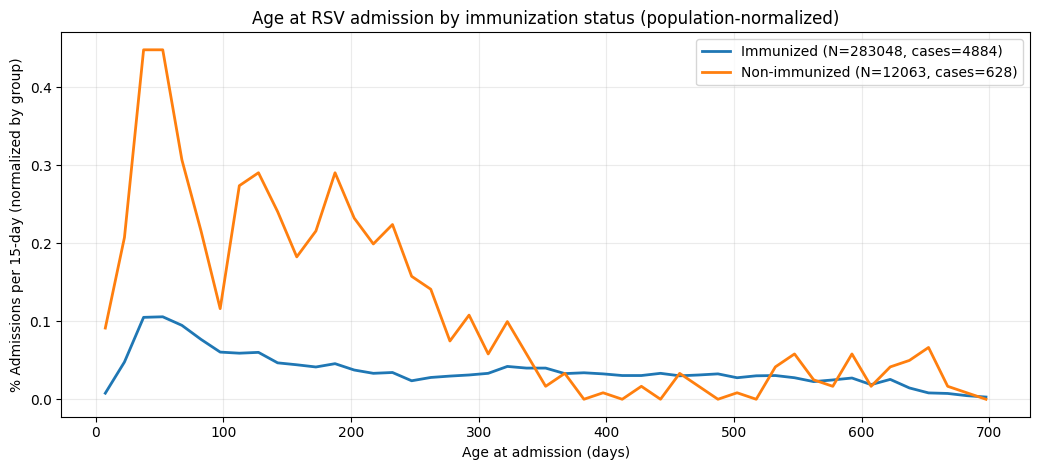

In [443]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# df: 1 fila por infante, con fecha_nac, fechaIng_vrs, fechaInm (NaT si nunca), o tu columna inmunizado (0/1)
dfp = df.copy()

# --- define "ever immunized" ---
# si ya tienes dfp["inmunizado"] 0/1, úsalo directamente:
if "inmunizado" not in dfp.columns:
    dfp["inmunizado"] = dfp["fechaInm"].notna().astype(int)

# --- age at admission (days) solo para quienes tienen ingreso VRS ---
dfp["fecha_nac"] = pd.to_datetime(dfp["fecha_nac"], errors="coerce")
dfp["fechaIng_vrs"] = pd.to_datetime(dfp["fechaIng_vrs"], errors="coerce")

df_evt = dfp[dfp["fechaIng_vrs"].notna()].copy()
df_evt["age_at_adm_days"] = (df_evt["fechaIng_vrs"] - df_evt["fecha_nac"]).dt.days

# sacar edades negativas o absurdas
df_evt = df_evt[df_evt["age_at_adm_days"].between(0, 365*2)]  # ajusta si quieres

# --- denominadores poblacionales (para normalizar a la población de cada grupo) ---
N_imm = int((dfp["inmunizado"] == 1).sum())
N_no  = int((dfp["inmunizado"] == 0).sum())

# --- construir histogramas normalizados a población: "casos por bin / población del grupo" ---
bin_width = 15  # días por bin (semanal). Cambia a 14/30 si quieres.
max_age = int(df_evt["age_at_adm_days"].max())
bins = np.arange(0, max_age + bin_width, bin_width)

ages_imm = df_evt.loc[df_evt["inmunizado"] == 1, "age_at_adm_days"].to_numpy()
ages_no  = df_evt.loc[df_evt["inmunizado"] == 0, "age_at_adm_days"].to_numpy()

h_imm, _ = np.histogram(ages_imm, bins=bins)
h_no,  _ = np.histogram(ages_no,  bins=bins)

# tasa por bin (proporción de la población que tuvo admisión en ese bin)
rate_imm = h_imm*100 / N_imm if N_imm > 0 else np.zeros_like(h_imm, dtype=float)
rate_no  = h_no*100  / N_no  if N_no  > 0 else np.zeros_like(h_no, dtype=float)

# eje x = centro del bin
x = (bins[:-1] + bins[1:]) / 2

# --- plot ---
fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.plot(x, rate_imm, linewidth=2, label=f"Immunized (N={N_imm}, cases={len(ages_imm)})")
ax.plot(x, rate_no,  linewidth=2, label=f"Non-immunized (N={N_no}, cases={len(ages_no)})")

ax.set_xlabel("Age at admission (days)")
ax.set_ylabel(f"% Admissions per {bin_width}-day (normalized by group)")
ax.set_title("Age at RSV admission by immunization status (population-normalized)")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
df.eleg_2025

Index(['RUN', 'fecha_nac', 'mes_nac_name', 'semana_nac', 'SEMANAS', 'PESO',
       'prematuro_extremo', 'muy_prematuro', 'prematuro_moderado', 'prematuro',
       'sexo', 'region', 'year_nac', 'eleg_group', 'eleg_2025', 'eleg_2024',
       'MARCA', 'edad_relative', 'event_vrs', 'fechaIng_vrs', 'fechaInm',
       'inmunizado', 'inm_0_meses', 'inm_mayor_0_meses', 'inm_1_meses',
       'inm_mayor_1_meses', 'inm_2_meses', 'inm_mayor_2_meses', 'inm_3_meses',
       'inm_mayor_3_meses', 'inm_4_meses', 'inm_mayor_4_meses', 'inm_5_meses',
       'inm_mayor_5_meses', 'inm_6_meses', 'inm_mayor_6_meses', 'inm_7_meses',
       'inm_mayor_7_meses', 'inm_8_meses', 'inm_mayor_8_meses', 'inm_9_meses',
       'inm_mayor_9_meses', 'inm_10_meses', 'inm_mayor_10_meses',
       'inm_11_meses', 'inm_mayor_11_meses', 'inm_12_meses',
       'inm_mayor_12_meses', 'inm_13_meses', 'inm_mayor_13_meses',
       'inm_14_meses', 'inm_mayor_14_meses', 'inm_15_meses',
       'inm_mayor_15_meses', 'inm_16_meses', 'inm_

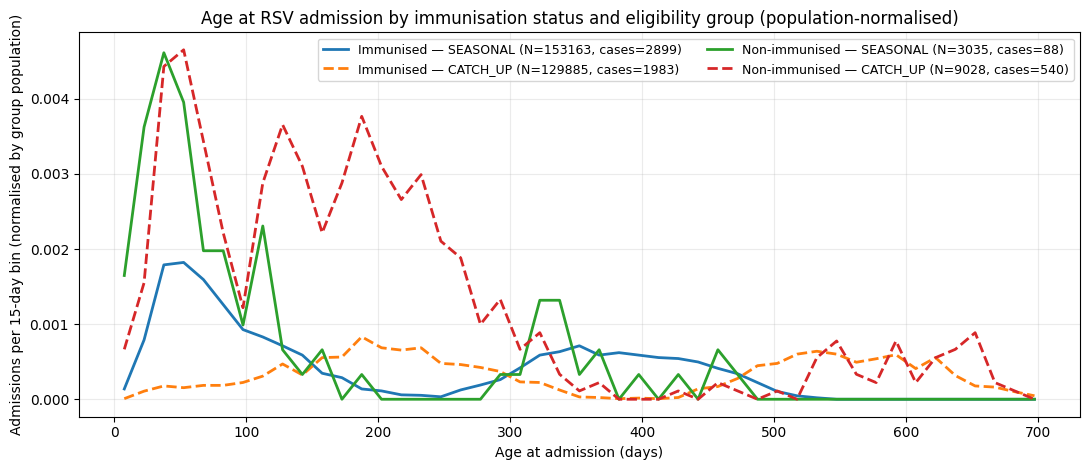

In [449]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dfp = df.copy()

# -------------------------
# 1) Unificar eleg_2024 y eleg_2025 -> eleg
# Regla: una de las dos es "no_elegible_*", la otra trae CATCH_UP o SEASONAL
# -------------------------
def _clean_eleg(s):
    s = s.astype(str).str.strip().str.upper()
    # normaliza variantes
    s = s.replace({
        "CATCHUP": "CATCH_UP",
        "CATCH UP": "CATCH_UP",
        "SEASONAL": "SEASONAL",
        "NO_ELEGIBLE_2024": "NO_ELEGIBLE",
        "NO_ELEGIBLE_2025": "NO_ELEGIBLE",
        "NO_ELEGIBLE": "NO_ELEGIBLE",
        "NONE": np.nan,
        "NAN": np.nan
    })
    return s

dfp["eleg_2024"] = _clean_eleg(dfp["eleg_2024"])
dfp["eleg_2025"] = _clean_eleg(dfp["eleg_2025"])

# eleg = la que no sea NO_ELEGIBLE
dfp["eleg"] = np.where(dfp["eleg_2024"].ne("NO_ELEGIBLE"), dfp["eleg_2024"], dfp["eleg_2025"])
dfp["eleg"] = pd.Series(dfp["eleg"]).replace("NO_ELEGIBLE", np.nan)

# nos quedamos solo con CATCH_UP y SEASONAL
dfp = dfp[dfp["eleg"].isin(["CATCH_UP", "SEASONAL"])].copy()

# -------------------------
# 2) Definir inmunizado (ever immunized)
# -------------------------
if "inmunizado" not in dfp.columns:
    dfp["inmunizado"] = dfp["fechaInm"].notna().astype(int)
else:
    dfp["inmunizado"] = dfp["inmunizado"].astype(int)

# -------------------------
# 3) Age at admission (days) solo para casos con ingreso
# -------------------------
dfp["fecha_nac"] = pd.to_datetime(dfp["fecha_nac"], errors="coerce")
dfp["fechaIng_vrs"] = pd.to_datetime(dfp["fechaIng_vrs"], errors="coerce")

df_evt = dfp[dfp["fechaIng_vrs"].notna()].copy()
df_evt["age_at_adm_days"] = (df_evt["fechaIng_vrs"] - df_evt["fecha_nac"]).dt.days
df_evt = df_evt[df_evt["age_at_adm_days"].between(0, 700)].copy()  # ajusta max si quieres

# -------------------------
# 4) Denominadores por grupo (población total en cada inmunizado x eleg)
# -------------------------
den = (
    dfp.groupby(["inmunizado", "eleg"])["RUN"]
       .nunique()
       .rename("N")
       .reset_index()
)

den_map = {(int(r.inmunizado), r.eleg): int(r.N) for r in den.itertuples(index=False)}

# -------------------------
# 5) Histograma por bin y normalización por población del grupo
# -------------------------
bin_width = 15
max_age = int(df_evt["age_at_adm_days"].max())
bins = np.arange(0, max_age + bin_width, bin_width)
x = (bins[:-1] + bins[1:]) / 2

def rate_curve(inm, eleg):
    ages = df_evt.loc[(df_evt["inmunizado"] == inm) & (df_evt["eleg"] == eleg), "age_at_adm_days"].to_numpy()
    h, _ = np.histogram(ages, bins=bins)
    N = den_map.get((inm, eleg), 0)
    rate = h / N if N > 0 else np.zeros_like(h, dtype=float)
    return rate, N, len(ages)

rate_i_seas, N_i_seas, cases_i_seas = rate_curve(1, "SEASONAL")
rate_i_cat,  N_i_cat,  cases_i_cat  = rate_curve(1, "CATCH_UP")
rate_n_seas, N_n_seas, cases_n_seas = rate_curve(0, "SEASONAL")
rate_n_cat,  N_n_cat,  cases_n_cat  = rate_curve(0, "CATCH_UP")

# -------------------------
# 6) Plot (4 curvas: color por inmunizado, estilo por eleg)
# -------------------------
fig, ax = plt.subplots(figsize=(11, 4.8))

# Inmunizados (azul): seasonal sólido, catchup rayado
ax.plot(x, rate_i_seas, linewidth=2, linestyle="-",
        label=f"Immunised — SEASONAL (N={N_i_seas}, cases={cases_i_seas})")
ax.plot(x, rate_i_cat, linewidth=2, linestyle="--",
        label=f"Immunised — CATCH_UP (N={N_i_cat}, cases={cases_i_cat})")

# No inmunizados (naranja): seasonal sólido, catchup rayado
ax.plot(x, rate_n_seas, linewidth=2, linestyle="-",
        label=f"Non-immunised — SEASONAL (N={N_n_seas}, cases={cases_n_seas})")
ax.plot(x, rate_n_cat, linewidth=2, linestyle="--",
        label=f"Non-immunised — CATCH_UP (N={N_n_cat}, cases={cases_n_cat})")

ax.set_xlabel("Age at admission (days)")
ax.set_ylabel(f"Admissions per {bin_width}-day bin (normalised by group population)")
ax.set_title("Age at RSV admission by immunisation status and eligibility group (population-normalised)")
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

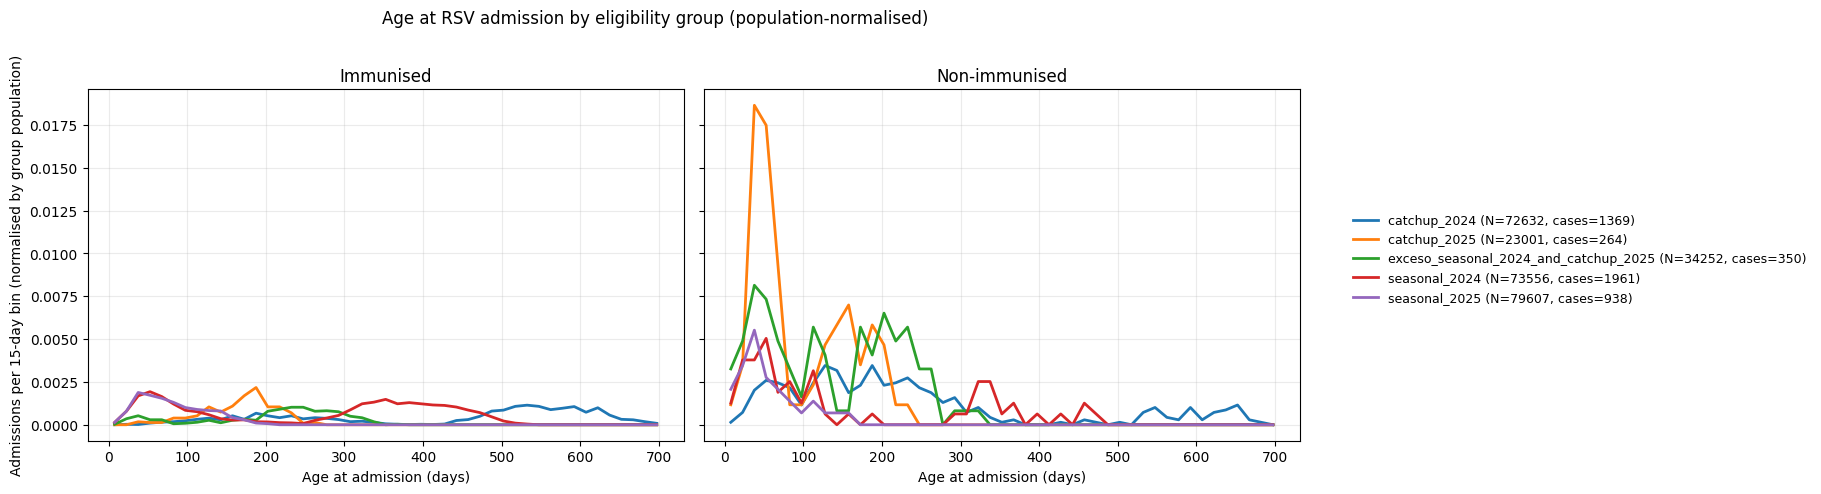

In [450]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dfp = df.copy()

# -------------------------
# 0) Preparar variables
# -------------------------
dfp["fecha_nac"] = pd.to_datetime(dfp["fecha_nac"], errors="coerce")
dfp["fechaIng_vrs"] = pd.to_datetime(dfp["fechaIng_vrs"], errors="coerce")

# inmunizado (ever)
if "inmunizado" not in dfp.columns:
    dfp["inmunizado"] = dfp["fechaInm"].notna().astype(int)
else:
    dfp["inmunizado"] = dfp["inmunizado"].astype(int)

# eleg_group (asegurar string limpio)
dfp["eleg_group"] = dfp["eleg_group"].astype(str).str.strip()

# Age at admission (solo casos con ingreso)
df_evt = dfp[dfp["fechaIng_vrs"].notna()].copy()
df_evt["age_at_adm_days"] = (df_evt["fechaIng_vrs"] - df_evt["fecha_nac"]).dt.days
df_evt = df_evt[df_evt["age_at_adm_days"].between(0, 700)].copy()  # ajusta

# -------------------------
# 1) Denominadores (población) por inmunizado x eleg_group
# -------------------------
den = (
    dfp.groupby(["inmunizado", "eleg_group"])["RUN"]
       .nunique()
       .rename("N")
       .reset_index()
)
den_map = {(int(r.inmunizado), r.eleg_group): int(r.N) for r in den.itertuples(index=False)}

# -------------------------
# 2) Curvas normalizadas por población por bin de edad
# -------------------------
bin_width = 15
max_age = int(df_evt["age_at_adm_days"].max())
bins = np.arange(0, max_age + bin_width, bin_width)
x = (bins[:-1] + bins[1:]) / 2

groups = sorted(dfp["eleg_group"].dropna().unique())

def curve(inm, g):
    ages = df_evt.loc[(df_evt["inmunizado"] == inm) & (df_evt["eleg_group"] == g), "age_at_adm_days"].to_numpy()
    h, _ = np.histogram(ages, bins=bins)
    N = den_map.get((inm, g), 0)
    rate = h / N if N > 0 else np.zeros_like(h, dtype=float)
    return rate, N, len(ages)

# -------------------------
# 3) Plot: 2 subplots (Immune vs Non-immune), curvas por eleg_group
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8), sharey=True)

for ax, inm, title in zip(axes, [1, 0], ["Immunised", "Non-immunised"]):
    for g in groups:
        rate, N, cases = curve(inm, g)
        ax.plot(x, rate, linewidth=2, label=f"{g} (N={N}, cases={cases})")

    ax.set_title(title)
    ax.set_xlabel("Age at admission (days)")
    ax.grid(alpha=0.25)

axes[0].set_ylabel(f"Admissions per {bin_width}-day bin (normalised by group population)")

# Leyenda única (a la derecha)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=1, fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

fig.suptitle("Age at RSV admission by eligibility group (population-normalised)", y=1.02)
plt.tight_layout()
plt.show()

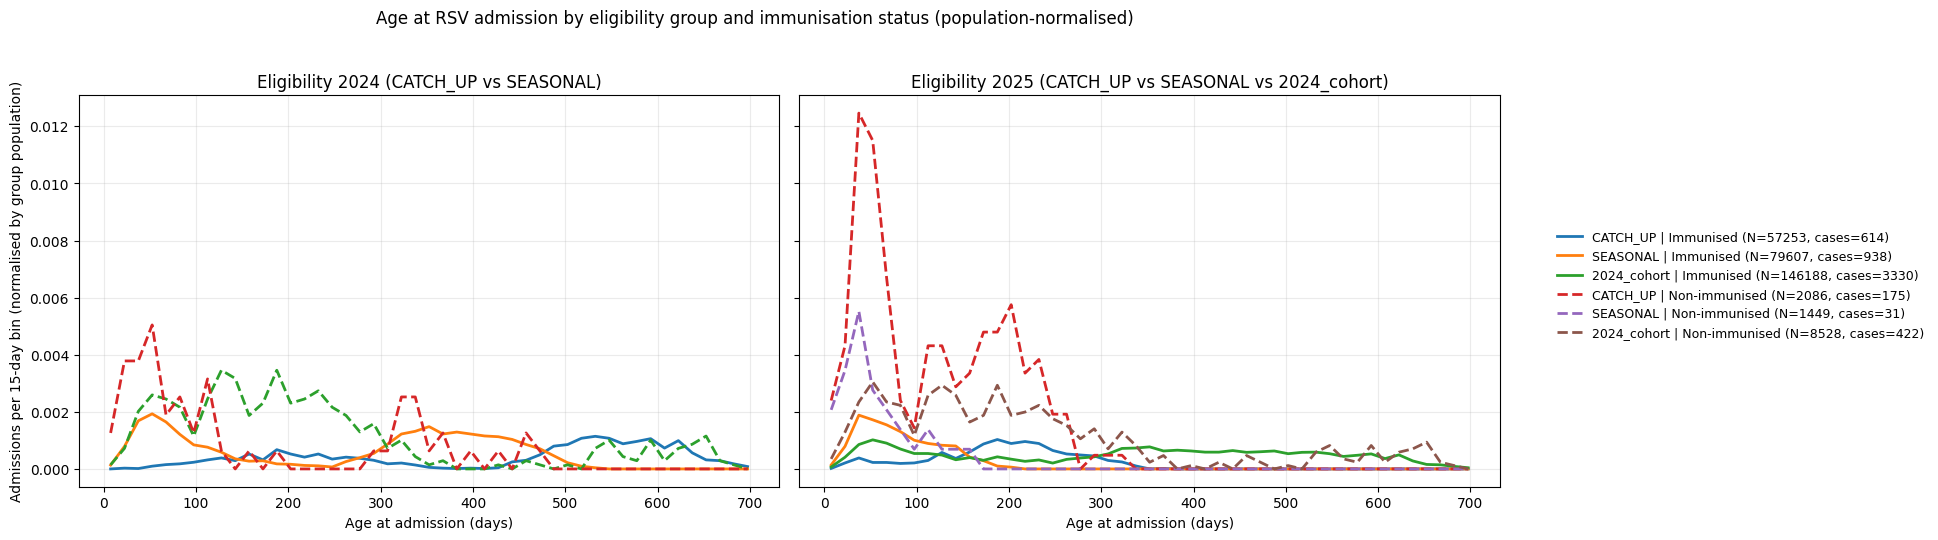

In [452]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dfp = df.copy()

# -------------------------
# Prep
# -------------------------
dfp["fecha_nac"] = pd.to_datetime(dfp["fecha_nac"], errors="coerce")
dfp["fechaIng_vrs"] = pd.to_datetime(dfp["fechaIng_vrs"], errors="coerce")

# ever immunised
if "inmunizado" not in dfp.columns:
    dfp["inmunizado"] = dfp["fechaInm"].notna().astype(int)
else:
    dfp["inmunizado"] = dfp["inmunizado"].astype(int)

# Age at admission (cases only)
df_evt = dfp[dfp["fechaIng_vrs"].notna()].copy()
df_evt["age_at_adm_days"] = (df_evt["fechaIng_vrs"] - df_evt["fecha_nac"]).dt.days
df_evt = df_evt[df_evt["age_at_adm_days"].between(0, 700)].copy()  # ajusta si quieres

# Bins
bin_width = 15
max_age = int(df_evt["age_at_adm_days"].max())
bins = np.arange(0, max_age + bin_width, bin_width)
x = (bins[:-1] + bins[1:]) / 2

# -------------------------
# Helper: curva normalizada por población (por inmunizado x grupo)
# -------------------------
def plot_panel(ax, group_col, groups_to_plot, label_map=None, title=""):
    if label_map is None:
        label_map = {}

    # denominadores (población total) por inmunizado x grupo
    den = (
        dfp[dfp[group_col].isin(groups_to_plot)]
        .groupby(["inmunizado", group_col])["RUN"]
        .nunique()
        .rename("N")
        .reset_index()
    )
    den_map = {(int(r.inmunizado), r.__getattribute__(group_col)): int(r.N) for r in den.itertuples(index=False)}

    # graficar por inmunizado (2 subplots internos: imm=1 y imm=0)
    for inm, ls in [(1, "-"), (0, "--")]:
        for g in groups_to_plot:
            ages = df_evt.loc[
                (df_evt["inmunizado"] == inm) & (df_evt[group_col] == g),
                "age_at_adm_days"
            ].to_numpy()

            h, _ = np.histogram(ages, bins=bins)
            N = den_map.get((inm, g), 0)
            rate = h / N if N > 0 else np.zeros_like(h, dtype=float)

            g_lab = label_map.get(g, g)
            inm_lab = "Immunised" if inm == 1 else "Non-immunised"
            ax.plot(x, rate, linewidth=2, linestyle=ls,
                    label=f"{g_lab} | {inm_lab} (N={N}, cases={len(ages)})")

    ax.set_title(title)
    ax.set_xlabel("Age at admission (days)")
    ax.grid(alpha=0.25)


# -------------------------
# Figure with 2 subplots:
# 1) eleg_2024 with only CATCH_UP & SEASONAL (exclude no_elegible_2024)
# 2) eleg_2025 with CATCH_UP, SEASONAL, and NO_ELEGIBLE_2025 renamed to 2024_cohort
# -------------------------
# Normaliza strings (por si vienen con distintas capitalizaciones)
def clean(s):
    s = s.astype(str).str.strip().str.upper()
    s = s.replace({
        "CATCHUP": "CATCH_UP",
        "CATCH UP": "CATCH_UP",
        "SEASONAL": "SEASONAL",
        "NO_ELEGIBLE_2024": "NO_ELEGIBLE_2024",
        "NO_ELEGIBLE_2025": "NO_ELEGIBLE_2025",
    })
    return s

dfp["eleg_2024"] = clean(dfp["eleg_2024"])
dfp["eleg_2025"] = clean(dfp["eleg_2025"])
df_evt["eleg_2024"] = clean(df_evt["eleg_2024"])
df_evt["eleg_2025"] = clean(df_evt["eleg_2025"])

fig, axes = plt.subplots(1, 2, figsize=(15.2, 5.2), sharey=True)

# Subplot 1: eleg_2024 (2 curvas por eleg: CATCH_UP y SEASONAL), con 2 estilos por inmunizado
groups_24 = ["CATCH_UP", "SEASONAL"]
plot_panel(
    axes[0],
    group_col="eleg_2024",
    groups_to_plot=groups_24,
    title="Eligibility 2024 (CATCH_UP vs SEASONAL)"
)

# Subplot 2: eleg_2025 (3 curvas por eleg: CATCH_UP, SEASONAL, NO_ELEGIBLE_2025 renombrada)
groups_25 = ["CATCH_UP", "SEASONAL", "NO_ELEGIBLE_2025"]
label_map_25 = {"NO_ELEGIBLE_2025": "2024_cohort"}

plot_panel(
    axes[1],
    group_col="eleg_2025",
    groups_to_plot=groups_25,
    label_map=label_map_25,
    title="Eligibility 2025 (CATCH_UP vs SEASONAL vs 2024_cohort)"
)

axes[0].set_ylabel(f"Admissions per {bin_width}-day bin (normalised by group population)")

# Leyenda única
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, ncol=1, fontsize=9, loc="center left",
           bbox_to_anchor=(1.02, 0.5), frameon=False)

fig.suptitle("Age at RSV admission by eligibility group and immunisation status (population-normalised)", y=1.03)
plt.tight_layout()
plt.show()

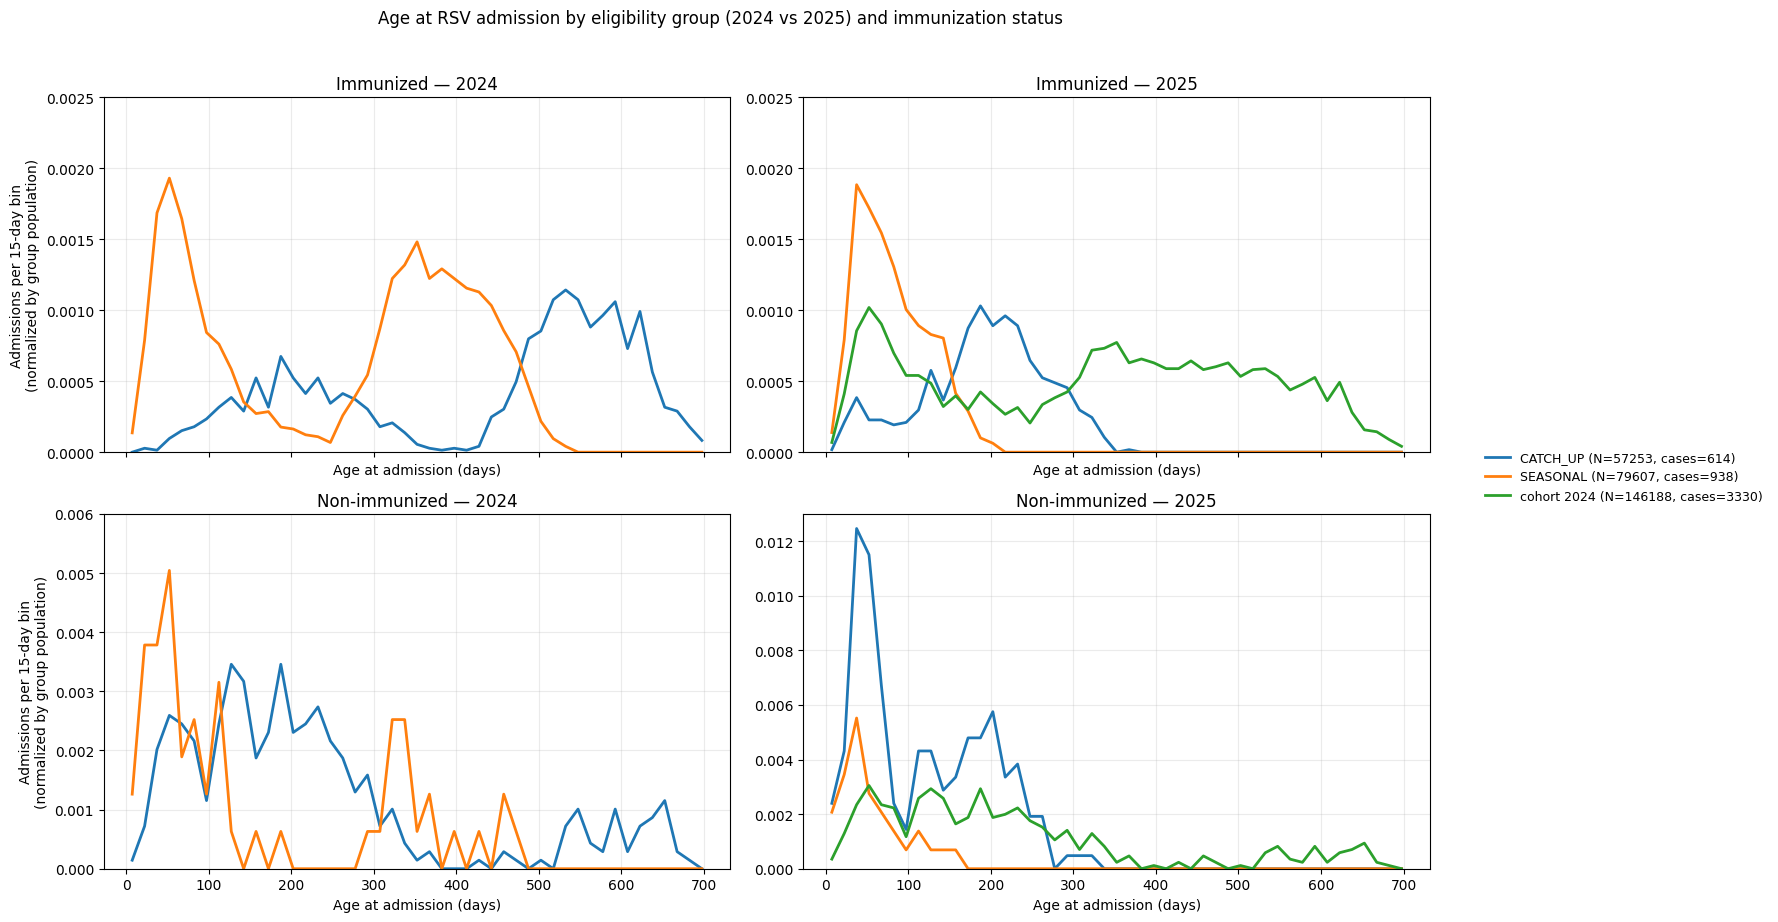

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dfp = df.copy()

# -------------------------
# Prep
# -------------------------
dfp["fecha_nac"] = pd.to_datetime(dfp["fecha_nac"], errors="coerce")
dfp["fechaIng_vrs"] = pd.to_datetime(dfp["fechaIng_vrs"], errors="coerce")

# ever immunized
if "inmunizado" not in dfp.columns:
    dfp["inmunizado"] = dfp["fechaInm"].notna().astype(int)
else:
    dfp["inmunizado"] = dfp["inmunizado"].astype(int)

# clean eleg columns
def clean_eleg(s):
    s = s.astype(str).str.strip().str.upper()
    s = s.replace({
        "CATCHUP": "CATCH_UP",
        "CATCH UP": "CATCH_UP",
        "SEASONAL": "SEASONAL",
        "NO_ELEGIBLE": "NO_ELEGIBLE",
        "NO_ELEGIBLE_2024": "NO_ELEGIBLE_2024",
        "NO_ELEGIBLE_2025": "NO_ELEGIBLE_2025",
        "NAN": np.nan,
        "NONE": np.nan
    })
    return s

dfp["eleg_2024"] = clean_eleg(dfp["eleg_2024"])
dfp["eleg_2025"] = clean_eleg(dfp["eleg_2025"])

# Cases only for age-at-admission
df_evt = dfp[dfp["fechaIng_vrs"].notna()].copy()
df_evt["age_at_adm_days"] = (df_evt["fechaIng_vrs"] - df_evt["fecha_nac"]).dt.days
df_evt = df_evt[df_evt["age_at_adm_days"].between(0, 700)].copy()  # ajusta max

# Binning
bin_width = 15
max_age = int(df_evt["age_at_adm_days"].max())
bins = np.arange(0, max_age + bin_width, bin_width)
x = (bins[:-1] + bins[1:]) / 2

# -------------------------
# Helper to compute rate curve (cases per bin / group population)
# -------------------------
def rate_curve(inm_val, group_col, group_val):
    # denominator: all infants in that inmunizado x group_val (population)
    N = int(dfp.loc[(dfp["inmunizado"] == inm_val) & (dfp[group_col] == group_val), "RUN"].nunique())

    ages = df_evt.loc[
        (df_evt["inmunizado"] == inm_val) & (df_evt[group_col] == group_val),
        "age_at_adm_days"
    ].to_numpy()

    h, _ = np.histogram(ages, bins=bins)
    rate = h / N if N > 0 else np.zeros_like(h, dtype=float)
    return rate, N, len(ages)

# -------------------------
# Plot 2x2
# -------------------------
fig, axes = plt.subplots(2, 2, figsize=(14.5, 9), sharex=True, sharey=False)

# Definitions
groups_24 = ["CATCH_UP", "SEASONAL"]  # exclude NO_ELEGIBLE_2024
groups_25 = ["CATCH_UP", "SEASONAL", "NO_ELEGIBLE_2025"]
label_map_25 = {"NO_ELEGIBLE_2025": "cohort 2024"}

panels = [
    # row, col, inm_val, group_col, groups, title
    (0, 0, 1, "eleg_2024", groups_24, "Immunized — 2024"),
    (1, 0, 0, "eleg_2024", groups_24, "Non-immunized — 2024"),
    (0, 1, 1, "eleg_2025", groups_25, "Immunized — 2025"),
    (1, 1, 0, "eleg_2025", groups_25, "Non-immunized — 2025"),
]

for r, c, inm_val, gcol, groups, title in panels:
    ax = axes[r, c]
    for g in groups:
        rate, N, n_cases = rate_curve(inm_val, gcol, g)

        g_lab = label_map_25.get(g, g)
        ax.plot(x, rate, linewidth=2, label=f"{g_lab} (N={N}, cases={n_cases})")

    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.set_xlabel("Age at admission (days)")

axes[0, 0].set_ylabel(f"Admissions per {bin_width}-day bin\n(normalized by group population)")
axes[1, 0].set_ylabel(f"Admissions per {bin_width}-day bin\n(normalized by group population)")

# Legend: one shared legend for all panels
handles, labels = axes[0, 1].get_legend_handles_labels()
fig.legend(handles, labels, ncol=1, fontsize=9, loc="center left",
           bbox_to_anchor=(1.02, 0.5), frameon=False)

axes[0, 0].set_ylim(0, 0.0025)
axes[0, 1].set_ylim(0, 0.0025)
axes[1, 0].set_ylim(0, 0.006)
axes[1, 1].set_ylim(0, 0.013)

fig.suptitle("Age at RSV admission by eligibility group (2024 vs 2025) and immunization status", y=1.02)
plt.tight_layout()
plt.show()

In [465]:
df.groupby(['eleg_2025','eleg_group']).RUN.nunique()

eleg_2025         eleg_group                           
CATCH_UP          catchup_2025                             23859
                  exceso_seasonal_2024_and_catchup_2025    35480
SEASONAL          seasonal_2025                            81056
no_elegible_2025  catchup_2024                             79574
                  seasonal_2024                            75142
Name: RUN, dtype: int64

In [466]:
df.eleg_2025.value_counts()

eleg_2025
no_elegible_2025    154716
SEASONAL             81056
CATCH_UP             59339
Name: count, dtype: int64

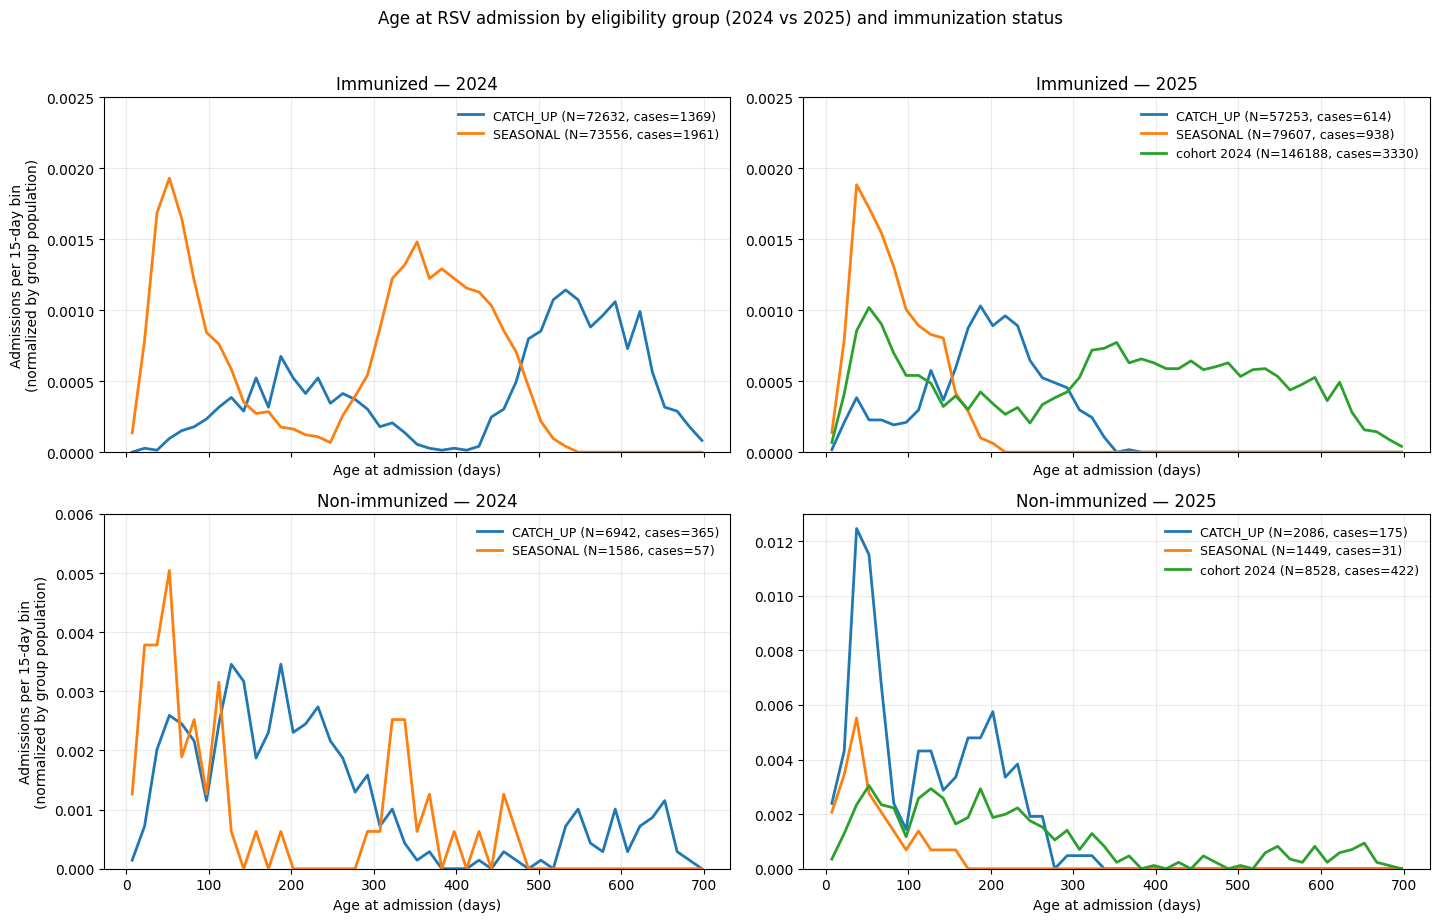

In [463]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dfp = df.copy()

dfp["fecha_nac"] = pd.to_datetime(dfp["fecha_nac"], errors="coerce")
dfp["fechaIng_vrs"] = pd.to_datetime(dfp["fechaIng_vrs"], errors="coerce")

if "inmunizado" not in dfp.columns:
    dfp["inmunizado"] = dfp["fechaInm"].notna().astype(int)
else:
    dfp["inmunizado"] = dfp["inmunizado"].astype(int)

def clean_eleg(s):
    s = s.astype(str).str.strip().str.upper()
    s = s.replace({
        "CATCHUP": "CATCH_UP",
        "CATCH UP": "CATCH_UP",
        "SEASONAL": "SEASONAL",
        "NO_ELEGIBLE": "NO_ELEGIBLE",
        "NO_ELEGIBLE_2024": "NO_ELEGIBLE_2024",
        "NO_ELEGIBLE_2025": "NO_ELEGIBLE_2025",
        "NAN": np.nan,
        "NONE": np.nan
    })
    return s

dfp["eleg_2024"] = clean_eleg(dfp["eleg_2024"])
dfp["eleg_2025"] = clean_eleg(dfp["eleg_2025"])

df_evt = dfp[dfp["fechaIng_vrs"].notna()].copy()
df_evt["age_at_adm_days"] = (df_evt["fechaIng_vrs"] - df_evt["fecha_nac"]).dt.days
df_evt = df_evt[df_evt["age_at_adm_days"].between(0, 700)].copy()

bin_width = 15
max_age = int(df_evt["age_at_adm_days"].max())
bins = np.arange(0, max_age + bin_width, bin_width)
x = (bins[:-1] + bins[1:]) / 2

def rate_curve(inm_val, group_col, group_val):
    N = int(dfp.loc[(dfp["inmunizado"] == inm_val) & (dfp[group_col] == group_val), "RUN"].nunique())
    ages = df_evt.loc[
        (df_evt["inmunizado"] == inm_val) & (df_evt[group_col] == group_val),
        "age_at_adm_days"
    ].to_numpy()
    h, _ = np.histogram(ages, bins=bins)
    rate = h / N if N > 0 else np.zeros_like(h, dtype=float)
    return rate, N, len(ages)

fig, axes = plt.subplots(2, 2, figsize=(14.5, 9), sharex=True, sharey=False)

groups_24 = ["CATCH_UP", "SEASONAL"]
groups_25 = ["CATCH_UP", "SEASONAL", "NO_ELEGIBLE_2025"]
label_map_25 = {"NO_ELEGIBLE_2025": "cohort 2024"}

panels = [
    (0, 0, 1, "eleg_2024", groups_24, "Immunized — 2024"),
    (1, 0, 0, "eleg_2024", groups_24, "Non-immunized — 2024"),
    (0, 1, 1, "eleg_2025", groups_25, "Immunized — 2025"),
    (1, 1, 0, "eleg_2025", groups_25, "Non-immunized — 2025"),
]

for r, c, inm_val, gcol, groups, title in panels:
    ax = axes[r, c]
    for g in groups:
        rate, N, n_cases = rate_curve(inm_val, gcol, g)
        g_lab = label_map_25.get(g, g)
        ax.plot(x, rate, linewidth=2, label=f"{g_lab} (N={N}, cases={n_cases})")

    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.set_xlabel("Age at admission (days)")

    # ✅ leyenda propia por subplot
    ax.legend(fontsize=9, frameon=False, loc="upper right")

axes[0, 0].set_ylabel(f"Admissions per {bin_width}-day bin\n(normalized by group population)")
axes[1, 0].set_ylabel(f"Admissions per {bin_width}-day bin\n(normalized by group population)")

axes[0, 0].set_ylim(0, 0.0025)
axes[0, 1].set_ylim(0, 0.0025)
axes[1, 0].set_ylim(0, 0.006)
axes[1, 1].set_ylim(0, 0.013)

fig.suptitle("Age at RSV admission by eligibility group (2024 vs 2025) and immunization status", y=1.02)
plt.tight_layout()
plt.show()

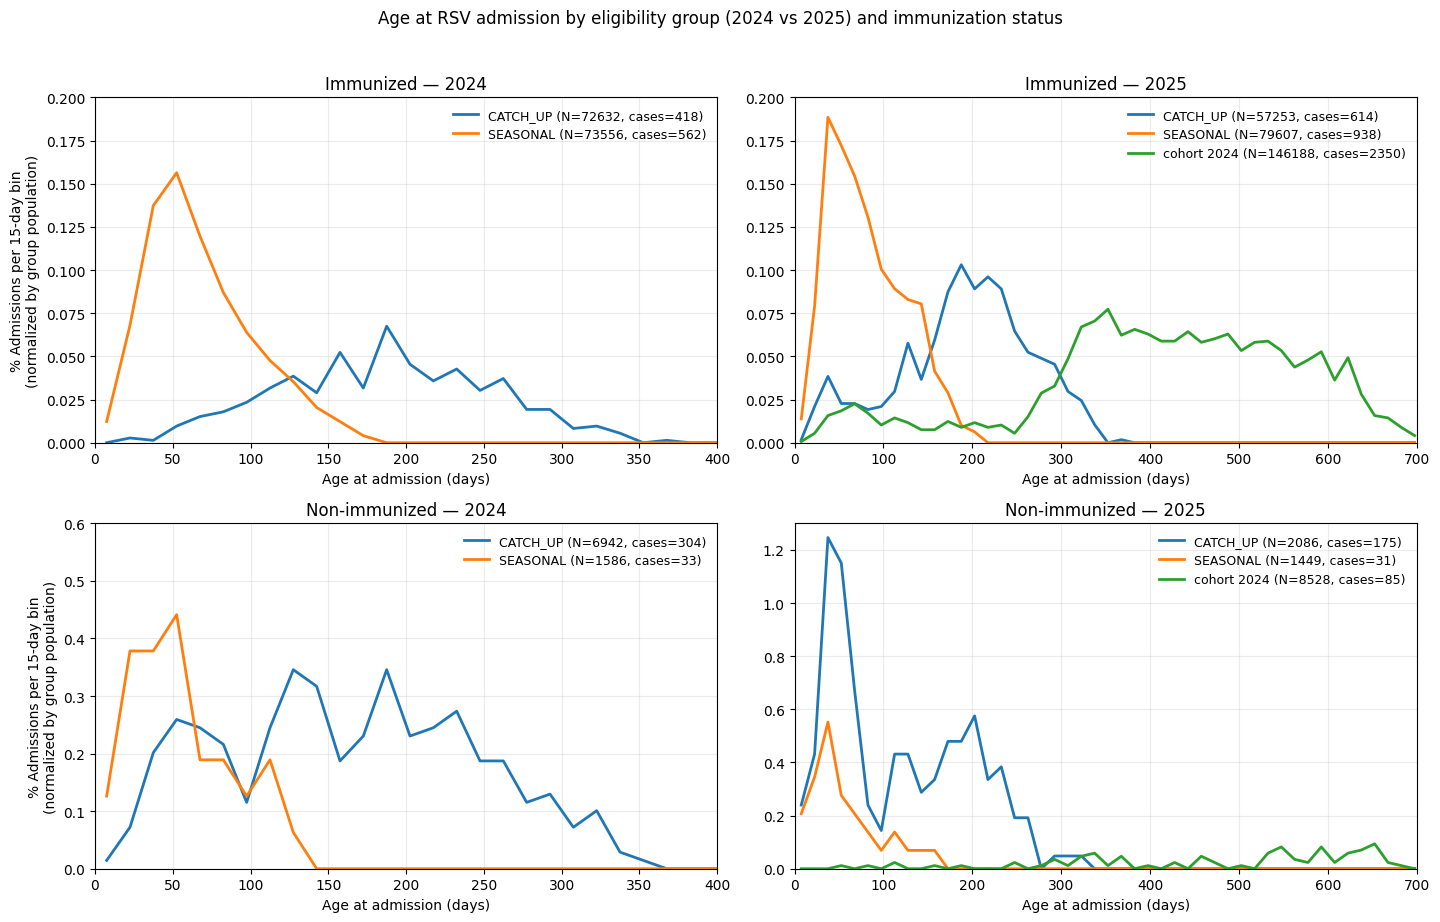

In [473]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dfp = df.copy()

dfp["fecha_nac"] = pd.to_datetime(dfp["fecha_nac"], errors="coerce")
dfp["fechaIng_vrs"] = pd.to_datetime(dfp["fechaIng_vrs"], errors="coerce")

if "inmunizado" not in dfp.columns:
    dfp["inmunizado"] = dfp["fechaInm"].notna().astype(int)
else:
    dfp["inmunizado"] = dfp["inmunizado"].astype(int)

def clean_eleg(s):
    s = s.astype(str).str.strip().str.upper()
    s = s.replace({
        "CATCHUP": "CATCH_UP",
        "CATCH UP": "CATCH_UP",
        "SEASONAL": "SEASONAL",
        "NO_ELEGIBLE": "NO_ELEGIBLE",
        "NO_ELEGIBLE_2024": "NO_ELEGIBLE_2024",
        "NO_ELEGIBLE_2025": "NO_ELEGIBLE_2025",
        "NAN": np.nan,
        "NONE": np.nan
    })
    return s

dfp["eleg_2024"] = clean_eleg(dfp["eleg_2024"])
dfp["eleg_2025"] = clean_eleg(dfp["eleg_2025"])

# Cases only for age-at-admission (sin filtro temporal aún)
df_evt = dfp[dfp["fechaIng_vrs"].notna()].copy()
df_evt["age_at_adm_days"] = (df_evt["fechaIng_vrs"] - df_evt["fecha_nac"]).dt.days
df_evt = df_evt[df_evt["age_at_adm_days"].between(0, 700)].copy()

bin_width = 15
max_age = int(df_evt["age_at_adm_days"].max())
bins = np.arange(0, max_age + bin_width, bin_width)
x = (bins[:-1] + bins[1:]) / 2

# Cortes de tiempo
cut_2024_start = pd.Timestamp("2023-10-01")
cut_2024_end   = pd.Timestamp("2024-10-01")  # exclusivo (hasta Sep-24 inclusive)
cut_post_2024  = pd.Timestamp("2024-10-01")  # >= Oct-24

mask_evt_2024 = (df_evt["fechaIng_vrs"] >= cut_2024_start) & (df_evt["fechaIng_vrs"] < cut_2024_end)
mask_evt_post = (df_evt["fechaIng_vrs"] >= cut_post_2024)

def rate_curve(inm_val, group_col, group_val, mask_evt):
    # denominator: all infants in that inmunizado x group_val (population)
    N = int(dfp.loc[(dfp["inmunizado"] == inm_val) & (dfp[group_col] == group_val), "RUN"].nunique())

    sub = df_evt.loc[
        mask_evt
        & (df_evt["inmunizado"] == inm_val)
        & (df_evt[group_col] == group_val),
        "age_at_adm_days"
    ].to_numpy()

    h, _ = np.histogram(sub, bins=bins)
    rate = h*100 / N if N > 0 else np.zeros_like(h, dtype=float)
    return rate, N, len(sub)

fig, axes = plt.subplots(2, 2, figsize=(14.5, 9), sharex=False, sharey=False)

groups_24 = ["CATCH_UP", "SEASONAL"]
groups_25 = ["CATCH_UP", "SEASONAL", "NO_ELEGIBLE_2025"]
label_map_25 = {"NO_ELEGIBLE_2025": "cohort 2024"}

panels = [
    # row, col, inm_val, group_col, groups, title, mask_evt
    (0, 0, 1, "eleg_2024", groups_24, "Immunized — 2024",     mask_evt_2024),
    (1, 0, 0, "eleg_2024", groups_24, "Non-immunized — 2024", mask_evt_2024),

    # Para panel 2025: usar eventos post Sep-24 (>= Oct-24)
    (0, 1, 1, "eleg_2025", groups_25, "Immunized — 2025",     mask_evt_post),
    (1, 1, 0, "eleg_2025", groups_25, "Non-immunized — 2025", mask_evt_post),
]

for r, c, inm_val, gcol, groups, title, mask_evt in panels:
    ax = axes[r, c]
    for g in groups:
        # regla extra explícita (por si quieres que SOLO "cohort 2024" use post-2024, y las otras no):
        # if (gcol == "eleg_2025") and (g == "NO_ELEGIBLE_2025"):
        #     mask_use = mask_evt_post
        # else:
        #     mask_use = mask_evt
        mask_use = mask_evt  # como pediste, 2025 usa post Sep-24

        rate, N, n_cases = rate_curve(inm_val, gcol, g, mask_use)
        g_lab = label_map_25.get(g, g)
        ax.plot(x, rate, linewidth=2, label=f"{g_lab} (N={N}, cases={n_cases})")

    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.set_xlabel("Age at admission (days)")
    ax.legend(fontsize=9, frameon=False, loc="upper right")

axes[0, 0].set_ylabel(f"% Admissions per {bin_width}-day bin\n(normalized by group population)")
axes[1, 0].set_ylabel(f"% Admissions per {bin_width}-day bin\n(normalized by group population)")

axes[0, 0].set_ylim(0, 0.2)
axes[0, 1].set_ylim(0, 0.2)
axes[1, 0].set_ylim(0, 0.6)
axes[1, 1].set_ylim(0, 1.3)

axes[0, 0].set_xlim(0, 400)
axes[1, 0].set_xlim(0, 400)

# 2025 panels (col 1)
axes[0, 1].set_xlim(0, 700)
axes[1, 1].set_xlim(0, 700)

fig.suptitle("Age at RSV admission by eligibility group (2024 vs 2025) and immunization status", y=1.02)
plt.tight_layout()
plt.show()